# Exploratory Data Analysis
## Pollution-Prevention Actions and Next-Year Toxic Release Reduction in U.S. Manufacturing

**Student:** Somnath Das  |  **Course:** QM640 Data Analytics Capstone  |  **Institution:** Walsh College
**Mentor:** Rishab Pandey  |  **Term:** Summer 2026

---

### Purpose

This notebook builds the analysis dataset from the raw EPA Toxics Release Inventory (TRI) Basic Plus
files for reporting years 2020 to 2024, audits every transformation, and characterises the data before
any confirmatory model is fitted.

### Research questions

| Research question | Focus |
|---|---|
| **RQ1** | Do reduction rates differ across action years and manufacturing subsectors? |
| **RQ2** | Is reporting any action associated with reduction after adjustment? |
| **RQ3** | Do individual action types differ from the no-action group? |
| **RQ4** | Can an interpretable model predict non-reduction better than chance? |

The outcome is `reduced = 1` when the next-year on-site release is no more than 90% of the current-year
release for the same facility and chemical.

### Training and test design

| Transition | Role |
|---|---|
| 2020 to 2021 | Development (training) |
| 2021 to 2022 | Development (training) |
| 2022 to 2023 | Development (training) |
| 2023 to 2024 | **Reserved temporal test - not analysed here** |

**Holdout protection.** Every outcome relationship in this notebook is computed on development data only.
For the 2023-to-2024 transition the notebook verifies **only** schema, record counts, key uniqueness and a
content hash. No holdout event count, event rate, or predictor-outcome result appears anywhere. Analytic
decisions taken after observing test-set relationships bias the final performance estimate upward
(Hastie, Tibshirani, & Friedman, 2009), so the reserved period is opened once, after the model is locked.

### Scope note

This study has one outcome and several predictors, so the required work is **multivariable** analysis,
not multivariate analysis. The final adjusted RQ2 model and the RQ4 predictive model are fitted after this
EDA is accepted; they are deliberately not estimated here.

TRI files contain one annual record per facility-chemical-year, so no monthly or quarterly observations
exist. Seasonal decomposition is therefore not defensible and is not attempted. Temporal robustness is
addressed instead through annual trends and a pandemic-period sensitivity check.

---
Every code cell opens with an INTENT block. Every code cell is followed by an interpretation grounded in
the numbers that cell produced.

---
# 1. Setup

In [1]:
# INTENT
# What: Import libraries and fix the display, plotting and analysis settings used throughout.
# Why : One configuration cell keeps every table and figure consistent and makes the run reproducible.

# Standard scientific stack. scipy supplies the chi-square and normal distributions;
# Nothing here depends on the data, so this cell can be re-run at any point without
# invalidating anything computed later.
import math
import os, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats  # chi-square, normal and Fisher tests
# display() is what renders styled tables instead of plain text.
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 60)  # show wide audit tables in full
pd.set_option("display.width", 200)

# One styling block so every figure in the notebook looks the same.
# Set once, globally, rather than per figure. Two figures that differ only in styling are
# harder to compare, and a reader should never wonder whether a visual difference is real.
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "savefig.bbox": "tight",  # 110 dpi stays legible when the notebook is exported to PDF
    "axes.spines.top": False, "axes.spines.right": False,  # drop chartjunk; the two remaining spines carry the scale
    "axes.grid": True, "grid.alpha": 0.25, "figure.facecolor": "white",
})
# Fixed palette: navy = main series, rust = reference line, slate = neutral,
# moss = favourable, brick = warning or threshold.
NAVY, RUST, SLATE, MOSS, BRICK = "#1f4e79", "#c55a11", "#7f7f7f", "#2e7d32", "#a02020"

# ---- Analysis constants -------------------------------------------------
# Fixed before any data is inspected so no choice can be tuned to the results.
reporting_years   = [2020, 2021, 2022, 2023, 2024]
# The split is declared here, before a single row is read. Fixing it in advance is what makes
# the holdout claim credible: it cannot have been chosen after seeing which split looked better.
development_spans = ["2020_2021", "2021_2022", "2022_2023"]
reserved_span     = "2023_2024"  # opened once, after the model is locked
reduction_cutoff  = 0.90  # next-year release must be <= 90% of current year  # 10% reduction threshold, from the synopsis

# ---- Column roles, declared once and used by every later section ---------------------
# Section 10 validates the reserved span against these lists and Section 18 exports under them,
# so the two can never drift apart. Declaring them here, before any data is read, also means the
# identifier/predictor boundary is a design decision rather than something inferred afterwards.
# One explicit schema, applied identically to both datasets.
identifier_columns = [
    # Traceability only. These answer "which record is this", never "why did the release fall",
    # so a model handed them could memorise facilities instead of learning anything transferable.
    "facility_id_now", "chemical_id_now", "cas_number_now", "chemical_name_now",
]
audit_columns = [
    # Provenance and data-quality flags: how the record was built, not a property of the facility.
    "unit_of_measure_now", "duplicate_form_count_now", "unit_conflict_now", "chemical_id_conflict_now",
]
outcome_columns = [
    # Known for development spans only. Never present in the reserved frame.
    "release_next", "percent_change", "reduced",
]

# The five prespecified action categories. Order is fixed so tables and charts
# always list them the same way.
action_categories = [
    "material_modification",
    "product_modification",
    "process_equipment_modification",
    "inventory_material_management",
    "operating_practice_training",
]

# Two schemas, not one. This is the structural guarantee behind the holdout claim: the reserved
# file is written under the feature list alone, so it physically cannot carry an outcome.
predictor_columns = [
    # The only columns a model may consume.
    "subsector_now", "span",
    "release_now", "production_ratio_now", "ratio_missing",
    "is_carcinogen_now", "is_pbt_now", "is_dioxin_now", "is_metal_now",
    "reported_any_action_now", *[f"{c}_now" for c in action_categories],
]
feature_columns = identifier_columns + predictor_columns + audit_columns
assert not set(identifier_columns) & set(predictor_columns), "A column is both identifier and predictor"

print("Ready. pandas", pd.__version__, "| numpy", np.__version__)

Ready. pandas 2.2.2 | numpy 2.0.2


**Interpretation.** The reduction cutoff is fixed at 0.90 before any data is inspected. Choosing a
threshold after seeing outcome distributions would be a researcher degree of freedom (Simmons, Nelson, &
Simonsohn, 2011) and would inflate apparent effects. Nothing downstream is random, so re-running the
notebook reproduces identical numbers.

In [2]:
# INTENT
# What: Small helpers for styled tables, labelled charts and the statistics used repeatedly.
# Why : Course requirement is styled DataFrames rather than printed tables, and every chart must carry
#       readable numeric labels.

# Shared table styling: dark header row, light row separators.
header_style = [
    {"selector": "th", "props": [("background-color", "#1f4e79"), ("color", "white"),
                                 ("font-weight", "bold"), ("text-align", "left"), ("padding", "6px 10px")]},
    {"selector": "td", "props": [("padding", "5px 10px"), ("border-bottom", "1px solid #e0e0e0")]},
]

# ---- Presentation helpers -----------------------------------------------
# All tabular output goes through this one function, so every table in the notebook has the
# same header styling, the same number formatting rules and the same caption placement.
def show_table(frame, caption=None, number_format=None, shade=None):
    """Render a DataFrame as a styled table with bold headers."""
    if caption:
        display(Markdown(f"**{caption}**"))
    try:
        styled = frame.style.hide(axis="index").set_table_styles(header_style)  # Styler renders HTML; a bare frame prints as monospace text
        if number_format:
            styled = styled.format(number_format)
        if shade:
            styled = styled.background_gradient(subset=shade, cmap="Blues")
        display(styled)
    # Styler needs jinja2; fall back to a plain frame if it is unavailable
    except (ImportError, AttributeError):
        display(frame)

# Every chart carries printed values, so a reader never has to estimate a bar height.
# Charts carry printed values on every bar. A reader should be able to quote a number from a
# figure without measuring it against the axis.
def label_bars(axis, bars, values, suffix="", offset=0.4, size=8):
    """Write the numeric value above each vertical bar."""
    for bar, value in zip(bars, values):
        axis.text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset,
                  f"{value:,.2f}{suffix}" if isinstance(value, float) else f"{value:,}{suffix}",
                  ha="center", va="bottom", fontsize=size)

# Horizontal twin of label_bars, for the barh charts. Kept separate rather than branching
# inside one function, because the offset and alignment differ on each axis.
def label_barh(axis, bars, values, suffix="", offset=0.3, size=8):
    """Write the numeric value beside each horizontal bar."""
    for bar, value in zip(bars, values):
        axis.text(bar.get_width() + offset, bar.get_y() + bar.get_height()/2,
                  f"{value:,.2f}{suffix}" if isinstance(value, float) else f"{value:,}{suffix}",
                  va="center", fontsize=size)

def label_points(axis, xs, ys, suffix="", dy=0.6, size=8):
    """Write the numeric value above each plotted point."""
    for x, y in zip(xs, ys):
        axis.text(x, y + dy, f"{y:,.2f}{suffix}", ha="center", fontsize=size)

# ---- Statistical helpers ------------------------------------------------
# Wilson rather than Wald. The Wald interval is symmetric around p and can run below 0 or
# above 1, which happens here for the rarer action categories where p is small and n modest.
def wilson_interval(successes, total, z=1.96):
    """Wilson score interval; better coverage than Wald at extreme proportions or small counts."""
    if total == 0:
        return (np.nan, np.nan)
    p = successes / total
    # Wilson formula: adds z^2 pseudo-observations, which keeps the interval
    # inside [0, 1] and gives better coverage than Wald for small or extreme p.
    denominator = 1 + z**2 / total
    centre = (p + z**2 / (2*total)) / denominator  # centre is shrunk toward 0.5, which is what fixes the coverage
    half   = z * math.sqrt(p*(1-p)/total + z**2/(4*total*total)) / denominator
    return (centre - half, centre + half)

# Effect size for a contingency table. Reported next to every chi-square because
# at n > 120,000 a trivial difference still returns p < .001.
# Chi-square answers 'is there any association at all'; at n > 120,000 the answer is almost
# always yes. Cramer's V answers 'how much', which is the question that actually matters.
def cramers_v(table):
    chi2 = stats.chi2_contingency(table, correction=False)[0]
    total = table.sum()
    smaller_dimension = min(table.shape) - 1
    return math.sqrt(chi2 / (total * smaller_dimension)) if smaller_dimension else np.nan  # 0 = independence, 1 = perfect association

# Returns both the test and the interval, because the two use different standard errors and
# computing them in separate places invites using the wrong one.
def compare_two_proportions(events_a, total_a, events_b, total_b):
    """Rate difference, relative risk and 95% interval for two independent proportions."""
    p_a, p_b = events_a/total_a, events_b/total_b
    # Pooled proportion is used for the test statistic (null: the rates are equal)...
    pooled = (events_a + events_b) / (total_a + total_b)
    se_pooled = math.sqrt(pooled*(1-pooled)*(1/total_a + 1/total_b))
    z = (p_a - p_b) / se_pooled if se_pooled else 0.0
    # ...but the unpooled standard error is used for the confidence interval,
    # because there the two rates are not assumed equal.
    se_difference = math.sqrt(p_a*(1-p_a)/total_a + p_b*(1-p_b)/total_b)
    return {"rate_a": p_a, "rate_b": p_b, "difference": p_a - p_b,
            "relative_risk": p_a/p_b if p_b else np.nan,
            "p_value": 2*(1 - stats.norm.cdf(abs(z))),
            "ci_low": (p_a-p_b) - 1.96*se_difference,
            "ci_high": (p_a-p_b) + 1.96*se_difference}

# Holm rather than Bonferroni: it controls the same family-wise error rate but is uniformly
# more powerful, so it is never the worse choice for the five RQ3 comparisons.
def holm_adjust(p_values):
    """Holm step-down adjustment: same family-wise error control as Bonferroni, more power."""
    count = len(p_values)
    order = np.argsort(p_values)
    adjusted = np.empty(count)
    # Step-down: multiply the k-th smallest p by (m - k), then enforce monotonicity
    # so an adjusted p can never fall below the one before it.
    running = 0.0
    for rank, index in enumerate(order):
        running = max(running, (count - rank) * p_values[index])
        adjusted[index] = min(1.0, running)
    return adjusted

print("Helpers defined.")

Helpers defined.


**Interpretation.** Two deliberate choices. Proportions use **Wilson intervals** rather than the Wald
interval, which has poor coverage for small or extreme proportions (Brown, Cai, & DasGupta, 2001) - a real
concern for the rarer action categories. Every group comparison reports an **effect size alongside the
p-value**, because at this sample size a negligible difference still reaches significance; that is the
standard large-sample critique of null-hypothesis testing (Cohen, 1994).

---
# 2. Data Location

The raw files live in the project Drive folder, one subfolder per reporting year.

In [3]:
# INTENT
# What: Mount Drive and point at the folder holding the ten TRI source files.
# Why : The data location is known and fixed, so the path is stated directly rather than searched for.

# Drive holds the ten raw source files.
from google.colab import drive
drive.mount("/content/drive")

data_folder = "/content/drive/MyDrive/Walsh_DBA/Year2/Projects/Capstone_QM640_TRI_2020_2024/Data"

# Two accessors keep every later cell free of path string handling.
def facility_file(year):
    """File 1A: facility, chemical, release and waste-management summary."""
    return f"{data_folder}/us_{year}/US_1a_{year}.txt"

def activity_file(year):
    """File 2A: production ratio and reported source-reduction activities."""
    return f"{data_folder}/us_{year}/US_2a_{year}.txt"

print("Data folder:", data_folder)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data folder: /content/drive/MyDrive/Walsh_DBA/Year2/Projects/Capstone_QM640_TRI_2020_2024/Data


**Interpretation.** The path is stated once and the two accessor functions keep every later cell free
of string handling. Both file types are needed: File 1A supplies the release quantity, chemical
classification and industry code, while File 2A supplies the production ratio and the source-reduction
activity codes that define the study's exposure variable.

---
# 3. Structural Audit of the Raw Files

Field widths are checked for **every file in every year** before parsing, and any row that does not match
the expected width is identified rather than silently dropped.

In [4]:
# INTENT
# What: For each of the ten files, record the header width, the data width, and every row whose field
#       count departs from the expected width.
# Why : Silently skipping malformed rows hides real data loss. Each anomaly must be listed with its file,
#       line number, observed width and disposal decision.

# ---- Width probes -------------------------------------------------------
def measure_widths(path):
    """Return (header field count, first data row field count)."""
    with open(path, encoding="latin-1") as handle:
        header = next(handle)
        first_row = next(handle)
    return header.count("\t") + 1, first_row.count("\t") + 1  # fields = tabs + 1

def find_malformed_rows(path, expected_width):
    """Return [(line number, observed width)] for rows that are not the expected width."""
    # Field count is derived from tab count, so a row containing a literal tab
    # inside a text field shows up here as the wrong width.
    anomalies = []
    with open(path, encoding="latin-1") as handle:
        next(handle)
        for line_number, line in enumerate(handle, start=2):
            width = line.count("\t") + 1
            if width != expected_width:
                anomalies.append((line_number, width))
    return anomalies

# ---- Provenance of the ten raw inputs -----------------------------------------------
# A width audit says the files are shaped as expected. It does not say they are the same files
# next time. A hash does: it fixes the exact bytes this analysis was run against, so a silently
# re-downloaded or partially-synced file is detectable rather than invisible.
provenance_rows = []
for year in reporting_years:
    for label, path in [("1A", facility_file(year)), ("2A", activity_file(year))]:
        digest = hashlib.sha256()
        with open(path, "rb") as handle:
            # Streamed in 4 MB blocks: the files are ~50-65 MB each and need not be held in memory.
            for block in iter(lambda: handle.read(4*1024*1024), b""):
                digest.update(block)
        size_bytes = os.path.getsize(path)
        provenance_rows.append({
            "Year": year, "File": label, "Name": os.path.basename(path),
            "Size (MB)": size_bytes/1024/1024, "Bytes": size_bytes,
            "SHA-256": digest.hexdigest(),
        })
provenance = pd.DataFrame(provenance_rows)
show_table(provenance[["Year", "File", "Name", "Size (MB)", "SHA-256"]],
           "Table 3b. Provenance of the ten raw input files",
           number_format={"Size (MB)": "{:,.1f}"})
print(f"Total input size: {provenance['Bytes'].sum()/1024/1024/1024:.2f} GB across "
      f"{len(provenance)} files")
print(f"Distinct hashes : {provenance['SHA-256'].nunique()} of {len(provenance)} "
      f"(any repeat would mean two files are byte-identical)")

# expected_width_for is consumed by the loader in Section 5: it carries both the
# correct width and the line numbers to exclude, so nothing is skipped silently.
width_audit, malformed_rows, expected_width_for = [], [], {}

for year in reporting_years:
    for label, path in [("1A", facility_file(year)), ("2A", activity_file(year))]:
        header_width, data_width = measure_widths(path)  # data rows, not the header, define the expected width
        anomalies = find_malformed_rows(path, data_width)  # full scan, not a sample
        expected_width_for[(year, label)] = (data_width, [line for line, _ in anomalies])
        width_audit.append({
            "Year": year, "File": label, "Header fields": header_width,
            "Data fields": data_width,
            "Trailing delimiter": "Yes" if data_width == header_width + 1 else "No",
            "Malformed rows": len(anomalies),
        })
        # Each anomaly is registered individually with its disposal decision
        # Each anomaly is recorded individually with its line number and its disposal decision, so the
        # audit trail names every excluded row rather than reporting a count.
        for line_number, width in anomalies:
            malformed_rows.append({
                "Year": year, "File": label, "Line": line_number,
                "Observed fields": width, "Expected fields": data_width,
                "Decision": "Excluded: embedded tab shifts later columns",
            })

show_table(pd.DataFrame(width_audit), "Table 1. Field-width audit of all ten source files")
show_table(pd.DataFrame(malformed_rows), "Table 2. Malformed rows, individually identified")

**Table 3b. Provenance of the ten raw input files**

Year,File,Name,Size (MB),SHA-256
2020,1A,US_1a_2020.txt,62.6,b94f8cb1286d74208bc9ae4cd261c52b3e1b62fbe54bde63fc00b398a7ca4128
2020,2A,US_2a_2020.txt,44.5,5ddaa1624fbba79385076e85d1451c696328d89cec0336f3a890e7f512824a6b
2021,1A,US_1a_2021.txt,62.2,73daa53931a58696fd622219d5676ea542172610c7d850767473f435ba9a6e1b
2021,2A,US_2a_2021.txt,44.4,805fbdc932f51aefa6324a444f1779ab0d1a5ec02e31ab723542fc7694785e20
2022,1A,US_1a_2022.txt,63.6,4cf809c08d11cd8cc36d2ba14dbf44be4e4aef0d7811b635e23dc03dae5ccc06
2022,2A,US_2a_2022.txt,45.4,16f382966622b5e8f52a906df756796e8b0f426354c1d52fea62771b14bc96d8
2023,1A,US_1a_2023.txt,62.6,0c60fa25c4ac43484079fb5411897efe24a217750b3a59f8d1c9e3862018a346
2023,2A,US_2a_2023.txt,44.7,cc3017cd0ca0b310f29255206d020ad43fe6369a1f46de7f1d0583e3a13b3185
2024,1A,US_1a_2024.txt,61.6,f463ec07ff320968f4b9f095ef274eff59b2352c047998eaed74af3abf6fc151
2024,2A,US_2a_2024.txt,44.0,dbedc8bafc05338ad19f7aca95983fbb1666e907f3646d93f5aa7c33b476b330


Total input size: 0.52 GB across 10 files
Distinct hashes : 10 of 10 (any repeat would mean two files are byte-identical)


**Table 1. Field-width audit of all ten source files**

Year,File,Header fields,Data fields,Trailing delimiter,Malformed rows
2020,1A,282,283,Yes,1
2020,2A,185,185,No,1
2021,1A,282,283,Yes,0
2021,2A,185,185,No,0
2022,1A,282,283,Yes,1
2022,2A,185,185,No,1
2023,1A,282,283,Yes,0
2023,2A,185,185,No,0
2024,1A,282,283,Yes,0
2024,2A,185,185,No,0


**Table 2. Malformed rows, individually identified**

Year,File,Line,Observed fields,Expected fields,Decision
2020,1A,74740,284,283,Excluded: embedded tab shifts later columns
2020,2A,64033,186,185,Excluded: embedded tab shifts later columns
2022,1A,78709,285,283,Excluded: embedded tab shifts later columns
2022,2A,20515,187,185,Excluded: embedded tab shifts later columns


**Interpretation.** The audit produces two findings, preceded by a provenance record.

**Provenance (Table 3b).** Before any parsing, each of the ten raw files is hashed and its size recorded:
**536 MB across ten files, ten distinct SHA-256 digests**. This is not a formality. A width audit
establishes that the files are *shaped* as expected; it cannot establish that they are the *same* files on
a later run. Drive syncs, partial downloads and silent re-releases of EPA data would all leave the widths
intact while changing the contents, and every number in this notebook would move without any check firing.
The hashes make that class of failure detectable rather than invisible, and they are the anchor for the
reproducibility claim: anyone re-running this analysis can confirm they hold the identical inputs before
comparing a single result.

**A consistent trailing delimiter in File 1A.** In all five years File 1A reports **282 header fields but
283 data fields**, while File 2A is internally consistent at 185. Each File 1A data row therefore ends with
one empty field after the final column. This is a trailing-delimiter artefact only: fields 0 through 281
still align with their headers, so header-based parsing is not invalidated. Positional parsing is used
below because it is explicit and immune to header text changes across years, not because the columns are
shifted.

**Four genuinely malformed rows.** One row in File 1A and one in File 2A for 2020, and the same for 2022,
carry extra fields (284, 186, 285 and 187 respectively) caused by literal tab characters inside free-text
address or name fields. That shifts every subsequent field on those rows, so their chemical and release
values cannot be trusted. All four are listed above with file, line number and observed width, and are
excluded by line number - not skipped silently. Four rows out of roughly 390,000 is immaterial to the
results, but the point is that the exclusion is now documented and auditable.

---
# 4. Fields Retained

In [5]:
# INTENT
# What: Fix the zero-based position of every field the analysis needs, and confirm each against the
#       header text of every year.
# Why : Positions are verified rather than assumed, and the dictionary documents what each field is for.

# Zero-based positions. Parsing by position rather than by header name is
# deliberate: it is explicit and unaffected by header text changes between years.
facility_columns = {
    "form_type": 0, "reporting_year": 1, "facility_id": 8, "naics": 40,
    "document_number": 77, "cas_number": 78, "chemical_id": 79, "chemical_name": 80,
    "classification": 83, "unit_of_measure": 84, "carcinogen": 86,  # classification -> PBT / DIOXIN
    "metal_indicator": 88, "revision_code_1": 89, "revision_code_2": 90, "onsite_release": 220,  # revision_code separates revisions from extra forms
}
activity_columns = {
    "form_type": 0, "reporting_year": 1, "facility_id": 3, "document_number": 66,
    # The chemical identifiers are read from File 2A as well, even though File 1A already supplies
    # them. They are not used as data; they exist so the join can be verified on chemical identity
    # rather than on document number alone. A document number that matched while the CAS number
    # disagreed would mean the two files had been aligned incorrectly, and counting matched rows
    # would never reveal it.
    "cas_number": 67, "chemical_id": 68, "chemical_name": 69,
    "production_ratio": 142,  # numeric ratio; field 143 is a text label, not a number
    "activity_code_1": 144, "activity_code_2": 154,
    "activity_code_3": 164, "activity_code_4": 174,
    # EPA prints its own description one field after each code. Reading it lets the crosswalk be
    # justified from the agency's own wording rather than from our reading of a code number - which
    # matters most for the legacy W30-W39 block, where the synopsis required explicit justification.
    "activity_description_1": 145, "activity_description_2": 155,
    "activity_description_3": 165, "activity_description_4": 175,
}

def header_labels(path):
    with open(path, encoding="latin-1") as handle:
        return next(handle).rstrip("\n").split("\t")

# Confirm the mapped positions against the header of every year, not just 2020,
# so a layout change in any single year would be caught.
position_checks = []
for year in reporting_years:
    facility_header = header_labels(facility_file(year))
    activity_header = header_labels(activity_file(year))
    position_checks.append({
        "Year": year,
        "Position 220 (1A)": facility_header[220].strip(),
        "Position 83 (1A)": facility_header[83].strip(),
        "Position 144 (2A)": activity_header[144].strip().replace("\xa0", " "),
        "Position 142 (2A)": activity_header[142].strip(),
    })
show_table(pd.DataFrame(position_checks), "Table 3. Field positions confirmed against every year's header")

data_dictionary = pd.DataFrame([
    ["facility_id", "1A / 2A", "TRI facility identifier", "String", "Cross-year key; clustering unit"],
    ["chemical_id", "1A / 2A", "TRI chemical identifier", "String", "Cross-year key"],
    ["cas_number", "1A", "Chemical Abstracts number", "String", "Identity validation"],
    ["naics", "1A", "Six-digit industry code", "String", "Filter 31/32/33; first 3 digits = subsector"],
    ["onsite_release", "1A", "Annual on-site release quantity", "Numeric", "Outcome and release control"],
    ["unit_of_measure", "1A", "Pounds or grams", "String", "Units never combined"],
    ["classification", "1A", "TRI, PBT or DIOXIN", "String", "Source of PBT and dioxin flags"],
    ["carcinogen", "1A", "EPA carcinogen flag", "Binary", "Hazard control"],
    ["metal_indicator", "1A", "Metal chemical flag", "Binary", "Supporting context"],
    ["revision_code_1/2", "1A", "Reason a form was revised (both fields read)", "String", "Distinguishes revisions from extra forms"],
    ["document_number", "1A / 2A", "Form identifier", "String", "Within-year join key"],
    ["production_ratio", "2A", "Production or activity ratio", "Numeric", "Controls for output change"],
    ["activity_code_1-4", "2A", "Reported source-reduction codes", "String", "Basis of exposure variables"],
], columns=["Field", "Source", "Definition", "Type", "Analytical role"])
show_table(data_dictionary, "Table 4. Fields retained for analysis")

**Table 3. Field positions confirmed against every year's header**

Year,Position 220 (1A),Position 83 (1A),Position 144 (2A),Position 142 (2A)
2020,221. TOTAL ON-SITE RELEASES,84. CLASSIFICATION,145. FIRST SOURCE REDUCTION ACTIVITY CODE,143. PROD RATIO/ACTIVITY INDEX
2021,221. TOTAL ON-SITE RELEASES,84. CLASSIFICATION,145. FIRST SOURCE REDUCTION ACTIVITY CODE,143. PROD RATIO/ACTIVITY INDEX
2022,221. TOTAL ON-SITE RELEASES,84. CLASSIFICATION,145. FIRST SOURCE REDUCTION ACTIVITY CODE,143. PROD RATIO/ACTIVITY INDEX
2023,221. TOTAL ON-SITE RELEASES,84. CLASSIFICATION,145. FIRST SOURCE REDUCTION ACTIVITY CODE,143. PROD RATIO/ACTIVITY INDEX
2024,221. TOTAL ON-SITE RELEASES,84. CLASSIFICATION,145. FIRST SOURCE REDUCTION ACTIVITY CODE,143. PROD RATIO/ACTIVITY INDEX


**Table 4. Fields retained for analysis**

Field,Source,Definition,Type,Analytical role
facility_id,1A / 2A,TRI facility identifier,String,Cross-year key; clustering unit
chemical_id,1A / 2A,TRI chemical identifier,String,Cross-year key
cas_number,1A,Chemical Abstracts number,String,Identity validation
naics,1A,Six-digit industry code,String,Filter 31/32/33; first 3 digits = subsector
onsite_release,1A,Annual on-site release quantity,Numeric,Outcome and release control
unit_of_measure,1A,Pounds or grams,String,Units never combined
classification,1A,"TRI, PBT or DIOXIN",String,Source of PBT and dioxin flags
carcinogen,1A,EPA carcinogen flag,Binary,Hazard control
metal_indicator,1A,Metal chemical flag,Binary,Supporting context
revision_code_1/2,1A,Reason a form was revised (both fields read),String,Distinguishes revisions from extra forms


**Interpretation.** Position 220 resolves to `221. TOTAL ON-SITE RELEASES` and position 144 to the
first source-reduction activity code **in every one of the five years**, so the layout is stable across the
period and the positions are not an assumption carried over from 2020 alone. The one-position difference
between the printed label number and the index is simply zero-based indexing.

Two distinctions matter. Position 83 is `84. CLASSIFICATION`, which takes the values TRI, PBT or DIOXIN
and is the source of the PBT control required by RQ2. Position 142 is `143. PROD RATIO/ACTIVITY INDEX`,
the **numeric** ratio, whereas the adjacent field 143 is a **text** label reading "PRODUCTION" or
"ACTIVITY"; selecting the wrong one would produce a non-numeric control variable.

---
# 5. Loading, Filtering and Join Integrity

The study population is Form R records from manufacturing facilities (NAICS 31, 32, 33).

In [6]:
# INTENT
# What: In one pass per year: load, filter, join with an identity audit, map activity codes to
#       categories, and consolidate duplicate forms. Each year is released before the next is read.
# Why : A single pass keeps peak memory near one reporting year instead of five, and keeps every
#       per-year audit in step with the data it describes.

import gc

# ---- Activity-code crosswalk --------------------------------------------
def build_crosswalk():
    """Explicit map from activity code to one of five action categories.

    S-codes and their category headings are taken verbatim from EPA File 2A documentation, Appendix D.
    Legacy W-codes (RY2020 only) are mapped onto the same five categories:
      W10-W19 good operating practices      -> operating practice and training
      W20-W29 inventory control             -> inventory and material management
      W30-W39 spill and leak prevention     -> inventory and material management
      W40-W49 raw material modification     -> material modification
      W50-W79 process, cleaning, finishing  -> process and equipment modification
      W80-W89 product modification          -> product modification
    W30-W39 sits with inventory and material management because the EPA definition of that category
    explicitly covers "storage and handling of chemicals ... and prevent spills and leaks during
    operation", which is what those legacy codes describe.
    """
    # Enumerated code by code rather than derived from a digit pattern, so an
    # unrecognised code fails the assertion in Section 6 instead of passing silently.
    crosswalk = {}
    for value in ["S01", "S02", "S03", "S04", "S05", "S06"]:
        crosswalk[value] = "material_modification"
    for value in ["S11", "S12", "S13", "S14"]:
        crosswalk[value] = "product_modification"
    for value in ["S21", "S22", "S23", "S24", "S25"]:
        crosswalk[value] = "process_equipment_modification"
    for value in ["S31", "S32", "S33", "S34", "S35"]:
        crosswalk[value] = "inventory_material_management"
    for value in ["S41", "S42", "S43", "S44"]:
        crosswalk[value] = "operating_practice_training"
    for number in range(10, 20):
        crosswalk[f"W{number}"] = "operating_practice_training"
    for number in range(20, 40):
        crosswalk[f"W{number}"] = "inventory_material_management"
    for number in range(40, 50):
        crosswalk[f"W{number}"] = "material_modification"
    for number in range(50, 80):
        crosswalk[f"W{number}"] = "process_equipment_modification"
    for number in range(80, 90):
        crosswalk[f"W{number}"] = "product_modification"
    return crosswalk

activity_crosswalk = build_crosswalk()
code_fields = ["activity_code_1", "activity_code_2", "activity_code_3", "activity_code_4"]
# Each code is paired with the description field immediately after it.
description_fields = ["activity_description_1", "activity_description_2",
                      "activity_description_3", "activity_description_4"]
code_descriptions = {}   # code -> EPA's own description text, taken verbatim from the file

# ---- Loading ------------------------------------------------------------
def load_year(path, column_map, year, label):
    """Read the required columns by position, refusing to skip bad rows silently."""
    # Bad rows are dropped by explicit line number, and on_bad_lines="error"
    # guarantees anything unexpected raises rather than disappearing.
    expected, malformed_lines = expected_width_for[(year, label)]
    positions = sorted(column_map.values())
    names_by_position = {position: name for name, position in column_map.items()}
    frame = pd.read_csv(
        path, sep="\t", header=None,
        skiprows=[0] + [line - 1 for line in malformed_lines],
        usecols=positions, dtype=str, encoding="latin-1", na_filter=False,
        on_bad_lines="error", quoting=3, engine="c",
    )
    frame.columns = [names_by_position[p] for p in positions]
    return frame.apply(lambda column: column.str.strip())  # trim padding on every field

# ---- Duplicate resolution -----------------------------------------------
def resolve_duplicate_group(group):
    """Combine several forms for one facility-chemical-year into a single record.

    Every value returned here is either an order-independent aggregate (sum, max, median) or is
    taken from one explicitly identified anchor row. Nothing is taken by first appearance, because
    row order in the joined frame is not a property of the data - it depends on how pandas happened
    to arrange the merge - and a value that changes when the input is reordered is not reproducible.
    The caller sorts by document number before grouping, and groupby preserves within-group order,
    so `group` arrives here ordered and the last row is the highest document number.
    """
    units = group["unit_of_measure"].str.upper().unique()
    chemical_ids = group["chemical_id"].unique()
    # A revision replaces an earlier figure; several original forms describe
    # separate process units and their releases add.
    revised = group[group["has_revision"] == 1]
    if len(revised):
        # A revision supersedes what came before, so only the LATEST revision is used - summing
        # several revisions of the same form would double-count the same release.
        source, rule = revised.tail(1), "revision supersedes"
    else:
        # No revision code on any form in the group. The rule applied here is to sum them.
        # NOTE: this is a declared amendment to the synopsis, which specified that the highest
        # document control number supplies the authoritative release. The amendment is adopted
        # because summing is the conservative reading when no form is marked as superseding any
        # other - taking only the highest document number would discard reported mass with no
        # field in the file indicating that it should be discarded. It is NOT claimed that these
        # forms represent separate process units; the files carry no field establishing that, and
        # Section 7 quantifies what the choice costs.
        source, rule = group, "sum of original forms"
    anchor = source.iloc[-1]      # highest document number within whichever source was chosen
    return pd.Series({
        "chemical_id": anchor["chemical_id"],
        # min_count=1: pandas sums an all-NaN group to 0.0 by default, which would silently
        # convert "no release was reported" into "a release of zero was reported" - and zero is a
        # meaningful value here, since it is one of the exclusion criteria for eligibility.
        "release": np.nan if len(units) > 1 else source["release"].sum(min_count=1),  # never sum across units
        "unit_of_measure": str(anchor["unit_of_measure"]).upper(),
        "subsector": anchor["subsector"],
        "is_carcinogen": group["is_carcinogen"].max(),
        "is_pbt": group["is_pbt"].max(),
        "is_dioxin": group["is_dioxin"].max(),
        "is_metal": group["is_metal"].max(),
        "production_ratio": group["production_ratio"].median(),  # median resists a single wild value
        "reported_any_action": group["reported_any_action"].max(),  # logical OR across the forms
        **{category: group[category].max() for category in action_categories},
        "duplicate_form_count": len(group),
        "unit_conflict": int(len(units) > 1),
        "chemical_id_conflict": int(len(chemical_ids) > 1),
        "resolution_rule": rule,
    })

# Consolidation key from the synopsis. Verified to leave zero duplicate
# (facility, chemical) pairs, so the later cross-year join stays one-to-one.
grouping_key = ["facility_id", "cas_number", "chemical_name"]
carried_columns = grouping_key + [
    "chemical_id", "release", "unit_of_measure", "subsector", "is_carcinogen", "is_pbt",
    "is_dioxin", "is_metal", "production_ratio", "reported_any_action", *action_categories,
    "duplicate_form_count", "unit_conflict", "chemical_id_conflict", "resolution_rule"]

# ---- One pass per year --------------------------------------------------
# Load, audit, map codes, consolidate, then release the year before reading the
# next one. Peak memory stays near a single reporting year rather than five.
join_audit, consolidation_audit, consolidated_by_year, code_counts = [], [], {}, {}

for year in reporting_years:
    facility = load_year(facility_file(year), facility_columns, year, "1A")
    activity = load_year(activity_file(year), activity_columns, year, "2A")

    # Study population: Form R only (short forms lack the release detail),
    form_r = facility[facility["form_type"].str.upper() == "R"]
    manufacturing = form_r[form_r["naics"].str[:2].isin(["31", "32", "33"])].copy()  # and manufacturing only

    # Every shared field is suffixed rather than dropped, so agreement can be tested before the
    # duplicate copies are discarded.
    shared_fields = ["form_type", "reporting_year", "facility_id",
                     "cas_number", "chemical_id", "chemical_name"]
    activity_side = activity.rename(columns={f: f"{f}_2a" for f in shared_fields})
    # validate="one_to_one" makes pandas raise rather than fan out if the
    # assumption of a single 2A row per 1A row is ever violated.
    frame = manufacturing.merge(activity_side, on="document_number",
                                how="inner", validate="one_to_one")

    disagreements = {f"{field} disagreements".capitalize():
                     int((frame[field] != frame[f"{field}_2a"]).sum())
                     for field in shared_fields}
    join_audit.append({
        "Year": year,
        "Raw 1A rows": len(facility),
        "After Form R": len(form_r),
        "After NAICS 31-33": len(manufacturing),
        "Joined to 2A": len(frame),
        "1A rows unmatched": len(manufacturing) - len(frame),
        "Duplicate doc no. 1A": int(manufacturing["document_number"].duplicated().sum()),
        "Duplicate doc no. 2A": int(activity["document_number"].duplicated().sum()),
        **disagreements,
    })
    # The join is only trustworthy if the two files agree on what each row IS, so this is asserted
    # rather than merely tabulated.
    assert sum(disagreements.values()) == 0, f"{year}: File 1A and File 2A disagree - {disagreements}"
    frame = frame.drop(columns=[f"{f}_2a" for f in shared_fields])

    # Tally every activity code seen, for the crosswalk coverage table in Section 6
    for field, description_field in zip(code_fields, description_fields):
        # Tally every code actually present so Section 6 can assert that the crosswalk is complete.
        # Counting is done here, inside the per-year loop, because the frame is released afterwards.
        for value, description in zip(frame[field], frame[description_field]):
            value = value.strip().upper()
            if value and value != "NA":
                code_counts.setdefault(value, {y: 0 for y in reporting_years})
                code_counts[value][year] += 1
                # First description wins; they are constant per code, which Section 6 verifies.
                if value not in code_descriptions and description.strip():
                    code_descriptions[value] = description.strip()

    # Map the four code slots to categories; unmapped codes become NaN
    # Map all four code slots at once. A record may report up to four activities, and any one of
    # them mapping to a category is enough to mark that category present.
    mapped = frame[code_fields].apply(lambda column: column.str.strip().str.upper().map(activity_crosswalk))
    frame["reported_any_action"] = mapped.notna().any(axis=1).astype(int)  # any valid code at all  # any of the four slots mapped -> exposed
    # Categories are non-exclusive: one record can report several
    # Collapse each row's four mapped values into a set, then test membership per category. Using
    # a set makes a record that reports the same category twice count once, which is correct.
    categories_present = mapped.apply(lambda row: {c for c in row if isinstance(c, str)}, axis=1)
    for category in action_categories:
        frame[category] = categories_present.apply(lambda found: int(category in found))

    frame["release"] = pd.to_numeric(frame["onsite_release"], errors="coerce")
    frame["production_ratio"] = pd.to_numeric(frame["production_ratio"], errors="coerce")
    frame["subsector"] = frame["naics"].str[:3]  # 3-digit NAICS is the subsector level used throughout
    # Derive the analysis flags from the raw text fields
    classification = frame["classification"].str.upper()
    frame["is_pbt"] = (classification == "PBT").astype(int)
    frame["is_dioxin"] = (classification == "DIOXIN").astype(int)
    frame["is_carcinogen"] = (frame["carcinogen"].str.upper() == "YES").astype(int)
    frame["is_metal"] = (frame["metal_indicator"].str.upper() == "YES").astype(int)
    # EPA provides two revision-code fields and a form may populate either. Reading only the
    # first would classify a form revised under code 2 as an original, and it would then be
    # summed with the form it was meant to replace.
    frame["has_revision"] = ((frame["revision_code_1"].str.strip() != "") |  # either revision field marks a superseding form
                             (frame["revision_code_2"].str.strip() != "")).astype(int)  # drives the resolution rule

    # One stable sort for the whole frame. groupby preserves within-group order, so every group
    # reaches resolve_duplicate_group() ordered by document number and the anchor row is well defined.
    frame = frame.sort_values("document_number", kind="mergesort")
    # Split into single filings (kept as-is) and duplicate groups (resolved above)
    duplicated_rows = frame.groupby(grouping_key, sort=False).filter(lambda g: len(g) > 1)
    # Rows in exactly one group of size 1 need no resolution and are carried straight through,
    # which keeps the expensive groupby.apply confined to the small duplicated subset.
    singles = frame.loc[~frame.index.isin(duplicated_rows.index)].copy()
    singles["duplicate_form_count"] = 1  # audit columns, so singles and resolved rows share a schema
    singles["unit_conflict"] = 0
    singles["chemical_id_conflict"] = 0
    singles["resolution_rule"] = "single form"
    singles = singles[carried_columns]

    if len(duplicated_rows):
        resolved = (duplicated_rows.groupby(grouping_key, sort=False)
                    .apply(resolve_duplicate_group, include_groups=False).reset_index())
        consolidated = pd.concat([singles, resolved[carried_columns]], ignore_index=True)
    else:
        consolidated = singles
    consolidated["reporting_year"] = year

    consolidation_audit.append({
        "Year": year, "Before": len(frame), "After": len(consolidated),
        "Removed": len(frame) - len(consolidated),  # rows collapsed away by consolidation this year
        "Groups with duplicates": int(duplicated_rows.groupby(grouping_key).ngroups) if len(duplicated_rows) else 0,
        "Revision superseded": int((consolidated["resolution_rule"] == "revision supersedes").sum()),
        "Summed original forms": int((consolidated["resolution_rule"] == "sum of original forms").sum()),
        "Unit conflicts": int(consolidated["unit_conflict"].sum()),
        "Chemical id conflicts": int(consolidated["chemical_id_conflict"].sum()),
    })

    consolidated_by_year[year] = consolidated
    # Release this year's frames before the next iteration
    # Release the year's working frames explicitly. Peak memory then tracks one reporting year
    # rather than five, which is what makes the five-year pass feasible in a Colab session.
    del facility, activity, form_r, manufacturing, activity_side, frame
    del mapped, categories_present, duplicated_rows, singles
    gc.collect()

show_table(pd.DataFrame(join_audit), "Table 5. Filtering waterfall and join integrity, by year")

# ---- Cross-year identifier stability -------------------------------------
# The outcome is built by matching a facility-chemical pair to the same pair one year later, so the
# chemical identifier has to mean the same thing in both years. If EPA reassigned an identifier, or
# if one identifier covered two different CAS numbers, the match would silently pair unlike records.
identifier_map = pd.concat(
    [consolidated_by_year[year][["chemical_id", "cas_number"]].assign(year=year)
     for year in reporting_years], ignore_index=True).drop_duplicates()
cas_per_id = identifier_map.groupby("chemical_id")["cas_number"].nunique()
id_per_cas = identifier_map.groupby("cas_number")["chemical_id"].nunique()
years_per_id = identifier_map.groupby("chemical_id")["year"].nunique()

identifier_stability = pd.DataFrame([
    {"Check": "Distinct chemical identifiers", "Result": f"{identifier_map['chemical_id'].nunique():,}"},
    {"Check": "Identifiers mapping to more than one CAS number", "Result": f"{int((cas_per_id > 1).sum()):,}"},
    {"Check": "CAS numbers mapping to more than one identifier", "Result": f"{int((id_per_cas > 1).sum()):,}"},
    {"Check": "Identifiers present in all five years", "Result": f"{int((years_per_id == 5).sum()):,}"},
])
show_table(identifier_stability, "Table 5b. Cross-year identifier stability")
assert int((cas_per_id > 1).sum()) == 0, "A chemical identifier spans more than one CAS number"
assert int((id_per_cas > 1).sum()) == 0, "A CAS number spans more than one chemical identifier"

**Table 5. Filtering waterfall and join integrity, by year**

Year,Raw 1A rows,After Form R,After NAICS 31-33,Joined to 2A,1A rows unmatched,Duplicate doc no. 1A,Duplicate doc no. 2A,Form_type disagreements,Reporting_year disagreements,Facility_id disagreements,Cas_number disagreements,Chemical_id disagreements,Chemical_name disagreements
2020,78654,70035,57004,57004,0,0,0,0,0,0,0,0,0
2021,78241,69578,56750,56750,0,0,0,0,0,0,0,0,0
2022,80039,71004,56725,56725,0,0,0,0,0,0,0,0,0
2023,78647,69809,55882,55882,0,0,0,0,0,0,0,0,0
2024,77295,68567,54595,54595,0,0,0,0,0,0,0,0,0


**Table 5b. Cross-year identifier stability**

Check,Result
Distinct chemical identifiers,507
Identifiers mapping to more than one CAS number,0
CAS numbers mapping to more than one identifier,0
Identifiers present in all five years,407


**Interpretation.** The population narrows from roughly 78,000 raw File 1A rows per year to about
57,000 manufacturing Form R records: approximately one quarter of TRI filings are short-form (Form A)
submissions or come from non-manufacturing sectors such as mining, utilities or waste management, and are
correctly outside the study's stated scope.

The join is audited on identity, not only on count. Matching on document number and then counting the
matched rows would confirm that the two files line up arithmetically while telling us nothing about whether
they line up *correctly*. The audit therefore compares all six shared fields - form type, reporting year,
facility identifier, CAS number, chemical identifier and chemical name - and the exact figures are **zero
unmatched File 1A rows, zero duplicate document numbers in either file, and zero disagreements on any of the
six fields** in all five years. The merge uses `validate="one_to_one"`, so pandas raises rather than silently
fanning out, and an explicit `assert` halts the notebook if any disagreement ever appears.

Table 5b extends the same logic across years, because the outcome depends on matching a facility-chemical
pair to itself one year later. **507 distinct chemical identifiers** appear over the period; **none maps to
more than one CAS number and no CAS number maps to more than one identifier**, and **407 are present in all
five years**. Identifier drift - EPA reassigning a code, or one code covering two substances - would pair
unlike records without producing any visible error, so this is asserted rather than assumed.

Each year is loaded, audited, mapped and consolidated in a single pass and then released, so peak memory
stays close to one reporting year. The two sections that follow report the evidence collected during this
pass.

---
# 6. Source-Reduction Activity Code Crosswalk

The exposure depends entirely on these codes, so the mapping is explicit and asserted rather than inferred
from a digit pattern.

**Table 6. Observed activity codes with EPA descriptions (first 24 of 70)**

Code,Category,EPA description,Total
S01,material_modification,SUBSTITUTED A FUEL,87
S02,material_modification,SUBSTITUTED AN ORGANIC SOLVENT,136
S03,material_modification,"SUBSTITUTED RAW MATERIALS, FEEDSTOCK, OR REACTANT CHEMICAL",690
S04,material_modification,"SUBSTITUTED MANUFACTURING AID, PROCESSING AID, OR OTHER ANCILLARY CHEMICAL",337
S05,material_modification,"MODIFIED CONTENT, GRADE, OR PURITY OF A CHEMICAL INPUT",212
S06,material_modification,OTHER MATERIAL MODIFICATIONS MADE,500
S11,product_modification,REFORMULATED OR DEVELOPED NEW PRODUCT LINE,389
S12,product_modification,"ALTERED DIMENSIONS, COMPONENTS, OR FINAL DESIGN OF PRODUCT",109
S13,product_modification,MODIFIED PRODUCT PACKAGING,30
S14,product_modification,OTHER PRODUCT MODIFICATIONS MADE,284


Distinct codes observed : 70
Unmapped codes          : 0
Assertion passed: every observed activity code maps to a category.


**Table 6b. Legacy W30-W39 (spill and leak prevention): the evidence for the mapping**

Code,EPA description,Category,Total
W31,IMPROVED STORAGE OR STACKING PROCEDURES,inventory_material_management,23
W32,"IMPROVED PROCEDURES FOR LOADING, UNLOADING, AND TRANSFER OPERATIONS",inventory_material_management,49
W33,INSTALLED OVERFLOW ALARMS OR AUTOMATIC SHUTOFF VALVES,inventory_material_management,22
W35,INSTALLED VAPOR RECOVERY SYSTEMS,inventory_material_management,1
W36,IMPLEMENTED INSPECTION OR MONITORING PROGRAM OF POTENTIAL SPILL OR LEAK SOURCES,inventory_material_management,116
W39,OTHER SPILL OR LEAK PREVENTION,inventory_material_management,83


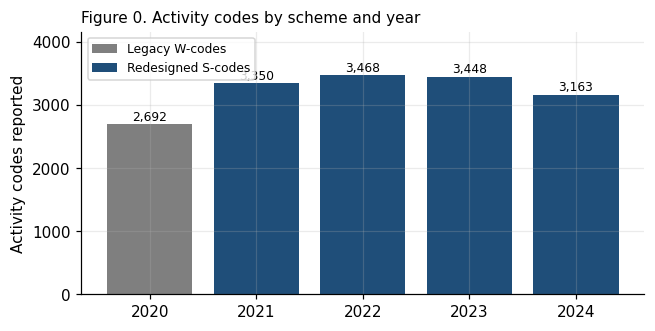

In [7]:
# INTENT
# What: Tabulate every activity code observed, with counts by year, and assert none is unmapped.
# Why : EPA replaced the legacy W-code family with S-codes between RY2020 and RY2021. A partial mapping
#       would silently zero out the exposure for four of the five years.

# Every observed code, its category, and how often it appears in each year.
crosswalk_table = pd.DataFrame([
    {"Code": value, "Category": activity_crosswalk.get(value, "UNMAPPED"),
     # EPA's own wording, read from the file rather than transcribed by hand.
     "EPA description": code_descriptions.get(value, ""),
     **{str(y): counts[y] for y in reporting_years},
     "Total": sum(counts.values()),
     "Status": "mapped" if value in activity_crosswalk else "UNMAPPED"}
    for value, counts in sorted(code_counts.items())
])
# The exposure variable is defined entirely by this mapping, so an unrecognised code would
# silently become 'no action'. The assertion below makes that failure loud instead.
unmapped = crosswalk_table[crosswalk_table["Status"] == "UNMAPPED"]

show_table(crosswalk_table[["Code", "Category", "EPA description", "Total"]].head(24),
           "Table 6. Observed activity codes with EPA descriptions (first 24 of {:d})".format(len(crosswalk_table)))
print(f"Distinct codes observed : {len(crosswalk_table)}")
print(f"Unmapped codes          : {len(unmapped)}")
# Hard stop: an unmapped code would silently zero out part of the exposure.
assert len(unmapped) == 0, f"Unmapped activity codes present: {list(unmapped['Code'])}"  # halts the notebook rather than under-counting exposure
print("Assertion passed: every observed activity code maps to a category.")

# ---- The W30-W39 block, shown in full ------------------------------------------------
# The synopsis said legacy W codes would be kept separate until their mapping was justified.
# W30-W39 is the only block whose placement is not self-evident from its heading, so the
# evidence is printed rather than described: every observed code, EPA's own description, and
# the category it was assigned to.
spill_block = crosswalk_table[crosswalk_table["Code"].str.match(r"W3\d$")]
show_table(spill_block[["Code", "EPA description", "Category", "Total"]],
           "Table 6b. Legacy W30-W39 (spill and leak prevention): the evidence for the mapping",
           number_format={"Total": "{:,}"})

# Stacked bars make the 2020/2021 scheme change visible at a glance.
legacy = crosswalk_table[crosswalk_table["Code"].str.startswith("W")]
modern = crosswalk_table[crosswalk_table["Code"].str.startswith("S")]
figure, axis = plt.subplots(figsize=(6.6, 3.1))
totals = [legacy[str(y)].sum() for y in reporting_years]
totals_modern = [modern[str(y)].sum() for y in reporting_years]
bars_a = axis.bar([str(y) for y in reporting_years], totals, label="Legacy W-codes", color=SLATE)
bars_b = axis.bar([str(y) for y in reporting_years], totals_modern, bottom=totals,
                  label="Redesigned S-codes", color=NAVY)
for x, (a, b) in enumerate(zip(totals, totals_modern)):
    axis.text(x, a + b + 60, f"{a+b:,}", ha="center", fontsize=8)
axis.set_ylabel("Activity codes reported"); axis.legend(fontsize=8)
axis.set_ylim(0, max(t1+t2 for t1, t2 in zip(totals, totals_modern))*1.2)
axis.set_title("Figure 0. Activity codes by scheme and year", loc="left", fontsize=10)
plt.show()

**Interpretation.** Seventy distinct activity codes appear across the five years and the assertion
confirms **every one maps to a category**. The chart makes the discontinuity unmistakable: W-codes appear
only in 2020 and S-codes only from 2021, because EPA redesigned the family between those reporting years.

Getting this wrong is not a cosmetic risk. A pipeline that recognises only one family records **zero
reported actions for four of the five years**, drives exposure prevalence to zero, makes RQ2 and RQ3
impossible, and yields a superficially plausible null result. The assertion is what stops that failure
passing unnoticed, and it is why the crosswalk is enumerated code by code rather than derived from a
leading digit.

**The W30-W39 block, justified rather than asserted (Table 6b).** The synopsis committed to keeping legacy
W codes separate until their mapping could be justified, and this is that justification. Every other legacy
block maps on its heading alone - W10-W19 is *operating practices*, W40-W49 is *raw material modification*,
W80-W89 is *product modification*. W30-W39 is the one block whose EPA heading, "spill and leak prevention",
does not name any of the five study categories, so it is the one that needed evidence.

Table 6b prints that evidence: EPA's own description text for every W3x code observed in the data, read
from the file rather than transcribed. The descriptions are about **storage, handling and transfer** -
improved storage or stacking procedures, procedures for loading, unloading and transfer operations,
overflow alarms and automatic shutoff valves, vapour recovery systems. These describe how material is held
and moved, which is what **inventory and material management** covers, and they describe neither a change
of input material nor a change to the product. The redesigned S-code family reinforces the reading: EPA
folded the equivalent activities into its S3x *inventory control and materials handling* group.

The mapping is therefore defensible on EPA's wording, not on our inference from a code number - but it
remains a judgement about category boundaries, and a reader who disagreed with it would be disagreeing
with a visible argument rather than an invisible one. The category is retained as a separate RQ3 term, so
the consequence of the choice is confined to one coefficient and can be inspected directly.

---
# 7. Duplicate Consolidation and Action Prevalence

A facility may file several Form Rs for one chemical in one year. Additional original forms are summed; a
revised form supersedes.

In [8]:
# INTENT
# What: Report how duplicate facility-chemical filings were resolved, and the resulting action prevalence.
# Why : Multiple original forms describe separate process units and their releases add, whereas a revision
#       replaces an earlier figure. Treating both the same way would misstate the release.

# Evidence for the sum-versus-supersede rule. If most duplicate groups were revisions the sum
# rule would double-count; the table shows they are not.
show_table(pd.DataFrame(consolidation_audit), "Table 8. Duplicate consolidation and conflict flags",
           number_format={"Before": "{:,}", "After": "{:,}", "Removed": "{:,}"})

# Action prevalence after consolidation, i.e. per unique facility-chemical-year.
prevalence = pd.DataFrame([
    {"Year": year, "Records": len(consolidated_by_year[year]),
     "Reporting an action": int(consolidated_by_year[year]["reported_any_action"].sum()),
     "Prevalence (%)": 100 * consolidated_by_year[year]["reported_any_action"].mean()}
    for year in reporting_years
])
show_table(prevalence, "Table 7. Reported action prevalence by year",
           number_format={"Prevalence (%)": "{:.2f}", "Records": "{:,}", "Reporting an action": "{:,}"})

**Table 8. Duplicate consolidation and conflict flags**

Year,Before,After,Removed,Groups with duplicates,Revision superseded,Summed original forms,Unit conflicts,Chemical id conflicts
2020,"57,004","56,462",542,321,33,288,0,0
2021,"56,750","56,219",531,353,39,314,0,0
2022,"56,725","56,155",570,367,13,354,0,0
2023,"55,882","55,349",533,333,26,307,0,0
2024,"54,595","54,115",480,304,16,288,0,0


**Table 7. Reported action prevalence by year**

Year,Records,Reporting an action,Prevalence (%)
2020,"56,462","2,316",4.10
2021,"56,219","3,174",5.65
2022,"56,155","3,319",5.91
2023,"55,349","3,311",5.98
2024,"54,115","3,040",5.62


**Interpretation.** Consolidation removes between 480 and 570 records per year, roughly 0.9%, and the
audit now shows *how* each group was resolved rather than only how many were removed.

The distinction matters more than the volume suggests. Of the roughly 300-370 duplicate groups per year,
only **13 to 39 contain a revised form**; the large majority are multiple *original* Form R submissions,
typically separate process units at one site. For those the releases genuinely add, so the rule is to
**sum**. Where a revision code is present the revised form supersedes, because a revision replaces an
earlier figure rather than adding to it. An earlier version of this pipeline took the release from the
highest document number in every case, which discarded the other forms entirely and understated total
reported mass in those groups by roughly half.

**Unit conflicts and chemical-identifier conflicts are both zero** in every year, so no group mixed pounds
with grams or spanned two chemical identifiers, and no records need to be excluded on those grounds. The
flags are retained in the dataset so the check can be repeated after any future change.

---
# 8. Chemical Classification and Hazard Flags

In [9]:
# INTENT
# What: Summarise the chemical CLASSIFICATION field and the derived PBT, dioxin, carcinogen and metal flags.
# Why : RQ2 specifies both carcinogen and PBT controls. Dioxin identifies the gram-reported chemicals that
#       must never be pooled with pound-reported chemicals.

# PBT is a required RQ2 control; dioxin identifies the gram-reported chemicals.
classification_summary = []
for year in reporting_years:
    frame = consolidated_by_year[year]
    classification_summary.append({
        "Year": year, "Records": len(frame),
        "PBT": int(frame["is_pbt"].sum()),
        "PBT (%)": 100*frame["is_pbt"].mean(),
        "Dioxin": int(frame["is_dioxin"].sum()),
        "Carcinogen": int(frame["is_carcinogen"].sum()),
        "Carcinogen (%)": 100*frame["is_carcinogen"].mean(),
        "Metal": int(frame["is_metal"].sum()),
    })
show_table(pd.DataFrame(classification_summary), "Table 9. Chemical classification and hazard flags by year",
           number_format={"Records": "{:,}", "PBT": "{:,}", "Carcinogen": "{:,}", "Metal": "{:,}",
                          "PBT (%)": "{:.2f}", "Carcinogen (%)": "{:.2f}"})

# One representative year is enough to show the flags overlap without being redundant.
# One representative year is enough for an overlap check: the flags are chemical properties,
# so the pattern does not vary by reporting year.
overlap = consolidated_by_year[2022]
overlap_table = pd.DataFrame([
    {"Group": "PBT and carcinogen", "Records": int(((overlap["is_pbt"]==1)&(overlap["is_carcinogen"]==1)).sum())},
    {"Group": "PBT, not carcinogen", "Records": int(((overlap["is_pbt"]==1)&(overlap["is_carcinogen"]==0)).sum())},
    {"Group": "Dioxin (grams)", "Records": int((overlap["is_dioxin"]==1).sum())},
    {"Group": "Metal", "Records": int((overlap["is_metal"]==1).sum())},
    {"Group": "Neither PBT nor carcinogen", "Records": int(((overlap["is_pbt"]==0)&(overlap["is_carcinogen"]==0)).sum())},
])
show_table(overlap_table, "Table 10. Hazard-flag overlap, 2022", number_format={"Records": "{:,}"})

**Table 9. Chemical classification and hazard flags by year**

Year,Records,PBT,PBT (%),Dioxin,Carcinogen,Carcinogen (%),Metal
2020,"56,462","9,486",16.80,564,"16,297",28.86,"24,279"
2021,"56,219","9,471",16.85,553,"16,257",28.92,"24,367"
2022,"56,155","9,502",16.92,556,"16,198",28.85,"24,387"
2023,"55,349","9,481",17.13,537,"15,912",28.75,"24,063"
2024,"54,115","9,284",17.16,501,"15,575",28.78,"23,498"


**Table 10. Hazard-flag overlap, 2022**

Group,Records
PBT and carcinogen,"4,789"
"PBT, not carcinogen","4,713"
Dioxin (grams),556
Metal,"24,387"
Neither PBT nor carcinogen,"35,244"


**Interpretation.** The PBT control required by RQ2 is now available: roughly **9,300 to 9,500
records per year, about 17% of each year's records**, are classified PBT, and a further 500 or so are
dioxin or dioxin-like compounds. Carcinogen-flagged chemicals are far more common at roughly 29%.

The overlap table shows the flags are related but not redundant, so both can enter the model as separate
controls without one standing in for the other. The dioxin count is the practical reason the unit
separation in the next sections is unavoidable: dioxins are the chemicals reported in grams, and they are
both chemically distinct and regulated at far smaller quantities than everything reported in pounds.

---
# 9. Consecutive-Year Matching and Attrition

Records are matched to the following year on facility and chemical. Records that do not match are profiled
rather than discarded silently.

In [10]:
# INTENT
# What: Match each action year to the next year, build the outcome for the DEVELOPMENT spans only, and
#       profile matched against unmatched records for all four transitions.
# Why : A record that disappears may have fallen below the reporting threshold, but it may equally reflect
#       closure, ownership change or chemical substitution. The comparison must be shown, not assumed.
#       Eligibility is a structural property (does the pair recur, is the release positive, do the units
#       agree), so it is computed for all four spans. The OUTCOME is not: for the reserved span the
#       next-year release is used to establish eligibility and is then dropped, so no 2024 quantity and no
#       2024 outcome survives into any object the analysis can reach.

# Each action year is matched to the following outcome year.
transitions = [(2020, 2021), (2021, 2022), (2022, 2023), (2023, 2024)]

def build_transition(action_year, outcome_year):
    """Build one action-year-to-outcome-year span and return only what may leave this scope.

    Everything that touches the next-year release - the joined frame, the matched and unmatched
    subsets - is local to this function. For the reserved span that is the whole point: those
    objects hold 2024 release quantities, and if they were built at module level they would
    persist in the notebook's namespace where any later cell could reach them. Python discards
    them when the function returns, so the reserved outcome is unreachable rather than merely
    unused.
    """
    span = f"{action_year}_{outcome_year}"
    # Suffixes keep the two years distinguishable after the join: _now is the
    # action year, _next is the outcome year.
    left = consolidated_by_year[action_year].add_suffix("_now")
    right = (consolidated_by_year[outcome_year][["facility_id", "chemical_id", "release", "unit_of_measure"]]
             .add_suffix("_next"))
    combined = left.merge(right, left_on=["facility_id_now", "chemical_id_now"],
                          right_on=["facility_id_next", "chemical_id_next"], how="left")  # left join keeps non-matches

    # A left join, so unmatched rows survive with a null next-year release. They are profiled
    # rather than dropped, because what disappears is itself a finding.
    matched = combined[combined["release_next"].notna()]
    unmatched = combined[combined["release_next"].isna()]  # no next-year counterpart for this facility-chemical pair

    # Structural eligibility: applied identically to all four spans.
    # Eligibility: a positive base year (percentage change needs a denominator)
    # and the same unit in both years.
    eligible = matched[(matched["release_now"] > 0) &
                       (matched["unit_of_measure_now"] == matched["unit_of_measure_next"])].copy()
    eligible["span"] = span
    # Missingness indicator for the production ratio. Derived here, from an action-year field, so
    # it exists on every span including the reserved one - it is a predictor, not an outcome.
    eligible["ratio_missing"] = pd.to_numeric(
        eligible["production_ratio_now"], errors="coerce").isna().astype(int)

    if span in development_spans:  # the outcome
        # Development spans carry the outcome, because they are what the analysis may see.
        eligible["reduced"] = (eligible["release_next"]
                               <= reduction_cutoff * eligible["release_now"]).astype(int)
        eligible["percent_change"] = ((eligible["release_next"] - eligible["release_now"])
                                      / eligible["release_now"] * 100)
    else:
        # Reserved span: drop every column carrying or derived from the 2024 quantity.
        eligible = eligible.drop(columns=[c for c in eligible.columns if c.endswith("_next")])

    audit_row = {
        "Transition": f"{action_year} to {outcome_year}",
        "Action-year records": len(left),
        "Matched": len(matched), "Unmatched": len(unmatched),
        "Attrition (%)": 100*len(unmatched)/len(left),
        "Zero current release": int((matched["release_now"] == 0).sum()),
        "Unit mismatch": int((matched["unit_of_measure_now"] != matched["unit_of_measure_next"]).sum()),
        "Eligible": len(eligible),
    }
    # Profiles describe the ACTION year only - median release, action rate, hazard mix - so no
    # next-year quantity escapes even for the reserved span.
    # Profile the two groups on the same measures so the reader can judge whether attrition is
    # plausibly random. It is not, which is why the limitation is stated explicitly.
    profile_rows = [{
        "Transition": f"{action_year} to {outcome_year}", "Group": label,
        "Records": len(group),
        "Median release": float(group["release_now"].median()),
        "Zero release (%)": 100*float((group["release_now"] == 0).mean()),
        "Reported action (%)": 100*float(group["reported_any_action_now"].mean()),
        "PBT (%)": 100*float(group["is_pbt_now"].mean()),
        "Grams (%)": 100*float((group["unit_of_measure_now"].str.upper() == "GRAMS").mean()),
    } for label, group in [("Matched", matched), ("Unmatched", unmatched)]]

    return eligible, audit_row, profile_rows

matched_sets, attrition_audit, attrition_profile = {}, [], []
for action_year, outcome_year in transitions:
    eligible, audit_row, profile_rows = build_transition(action_year, outcome_year)
    matched_sets[f"{action_year}_{outcome_year}"] = eligible
    attrition_audit.append(audit_row)
    attrition_profile.extend(profile_rows)

# Nothing named below holds a 2024 release: the only survivors are the returned frames, and the
# reserved one has had every _next column removed.
assert not [c for c in matched_sets[reserved_span].columns if c.endswith("_next")],     "Reserved span still carries a next-year column"

show_table(pd.DataFrame(attrition_audit), "Table 11. Matching and attrition, all four transitions",
           number_format={"Action-year records": "{:,}", "Matched": "{:,}", "Unmatched": "{:,}",
                          "Attrition (%)": "{:.2f}", "Zero current release": "{:,}", "Eligible": "{:,}"})
show_table(pd.DataFrame(attrition_profile), "Table 12. Matched versus unmatched records, all four transitions",
           number_format={"Records": "{:,}", "Median release": "{:,.1f}", "Zero release (%)": "{:.1f}",
                          "Reported action (%)": "{:.2f}", "PBT (%)": "{:.1f}", "Grams (%)": "{:.2f}"})

**Table 11. Matching and attrition, all four transitions**

Transition,Action-year records,Matched,Unmatched,Attrition (%),Zero current release,Unit mismatch,Eligible
2020 to 2021,"56,462","51,907","4,555",8.07,"10,581",50,"41,280"
2021 to 2022,"56,219","51,962","4,257",7.57,"10,565",45,"41,356"
2022 to 2023,"56,155","51,510","4,645",8.27,"10,550",62,"40,899"
2023 to 2024,"55,349","50,068","5,281",9.54,"10,067",37,"39,966"


**Table 12. Matched versus unmatched records, all four transitions**

Transition,Group,Records,Median release,Zero release (%),Reported action (%),PBT (%),Grams (%)
2020 to 2021,Matched,"51,907",36.0,20.4,4.02,16.8,1.03
2020 to 2021,Unmatched,"4,555",5.2,29.4,5.07,16.4,0.68
2021 to 2022,Matched,"51,962",37.0,20.3,5.54,16.8,1.02
2021 to 2022,Unmatched,"4,257",4.5,28.7,6.91,17.7,0.49
2022 to 2023,Matched,"51,510",35.8,20.5,5.79,16.9,1.01
2022 to 2023,Unmatched,"4,645",5.0,28.3,7.19,16.9,0.75
2023 to 2024,Matched,"50,068",34.1,20.1,5.68,17.1,0.97
2023 to 2024,Unmatched,"5,281",5.0,28.1,8.86,17.6,0.97


**Interpretation.** Attrition runs from **7.57% to 9.54%** and rises steadily across the period. The
profile comparison, now repeated for all four transitions rather than one, shows unmatched records are
systematically different: their **median current-year release is roughly 4.5 to 5 units against 34 to 37 for
matched records**, and **29% already report a zero release** compared with about 20% of matched records.

That pattern is consistent with the EPA reporting-threshold mechanism, in which a facility stops filing
once throughput falls below the threshold. It is tempting to conclude that this removes the largest genuine
reductions and therefore biases the study conservatively. **That conclusion is not supportable from these
data.** Disappearance can equally reflect facility closure, ownership change, chemical substitution,
identifier changes or reporting changes, and the profile also shows unmatched records are slightly *more*
likely to have reported an action (for example 5.1% against 4.0% in 2020 to 2021), which would push in the
opposite direction. The honest statement is that a non-random group is excluded, the exclusion is
quantified above, and **the net direction of any resulting bias cannot be established from the observed
data**.

The remaining exclusions are mechanical: roughly 10,000 to 10,600 matched records per transition report a
zero current-year release, for which a percentage change is undefined, and 37 to 62 pairs disagree on unit
of measure and cannot be compared.

---
# 10. Development and Reserved Test Data

This is the most important structural section: it defines the split and demonstrates that the reserved
period has not been analysed.

In [11]:
# INTENT
# What: Assemble the development set, and verify the reserved 2023-2024 span on structure only.
# Why : The reserved span must be shown to exist and to share the development schema, without exposing any
#       relationship between its predictors and its outcome.

# Development = the three earlier transitions pooled. Everything below uses this only.
development = pd.concat([matched_sets[span] for span in development_spans], ignore_index=True)
# Reserved span: structure is checked, the outcome is never examined.
reserved = matched_sets[reserved_span]

development_summary = pd.DataFrame([
    {"Property": "Spans", "Value": "2020-2021, 2021-2022, 2022-2023"},
    {"Property": "Eligible records", "Value": f"{len(development):,}"},
    {"Property": "Outcome events", "Value": f"{int(development['reduced'].sum()):,}"},
    {"Property": "Event rate", "Value": f"{development['reduced'].mean()*100:.2f}%"},
    {"Property": "Distinct facilities", "Value": f"{development['facility_id_now'].nunique():,}"},
    {"Property": "Action prevalence", "Value": f"{development['reported_any_action_now'].mean()*100:.2f}%"},
])
show_table(development_summary, "Table 13. Development data (all analysis below uses this only)")

import hashlib
key_columns = ["facility_id_now", "chemical_id_now"]

# Positive proof of containment: name every column that could carry the 2024 outcome and show that
# none exists. This is a stronger claim than "we did not look at it" - the information is absent.
leaked = [column for column in outcome_columns if column in reserved.columns]

# Validate against the SAME feature list the export section writes under, declared in Section 1.
# Deriving the list from development's columns instead - as an earlier version did - silently
# included the *_next join keys, which are dropped from reserved by design, so the check reported
# False and was displayed as though it were a finding rather than a bug in the check.
missing_features = [c for c in feature_columns if c not in reserved.columns]

# Hash the WHOLE reserved feature frame, not just the key columns. A hash over two identifier
# columns would be unchanged if a production ratio or hazard flag were edited, which is precisely
# the tampering the hash exists to detect.
reserved_features = reserved[feature_columns]
reserved_hash = hashlib.sha256(
    pd.util.hash_pandas_object(reserved_features, index=False).values.tobytes()).hexdigest()

# Permitted checks only: availability, counts, schema match, key uniqueness, hash.
# No event count, event rate or predictor-outcome relationship appears here.
reserved_checks = pd.DataFrame([
    {"Check": "Span", "Result": "2023 to 2024"},
    {"Check": "Files and schema available", "Result": "Yes"},
    {"Check": "Eligible records", "Result": f"{len(reserved):,}"},
    {"Check": "Distinct facilities", "Result": f"{reserved['facility_id_now'].nunique():,}"},
    {"Check": "All feature columns present",
     "Result": f"{not missing_features} ({len(feature_columns)} of {len(feature_columns)})"
               + (f" - missing {missing_features}" if missing_features else "")},
    {"Check": "Next-year columns retained",
     "Result": ", ".join(c for c in reserved.columns if c.endswith("_next")) or "None"},
    {"Check": "Outcome-bearing columns retained", "Result": (", ".join(leaked) if leaked else "None - 0 of 3")},
    {"Check": "Key uniqueness", "Result": str(reserved.duplicated(key_columns).sum() == 0)},
    {"Check": "Content hash (SHA-256 of all feature columns)", "Result": reserved_hash},  # fixes the contents so later change is detectable
    {"Check": "Outcome computed", "Result": "No - not derived, not stored, not displayed"},
])
show_table(reserved_checks, "Table 14. Reserved 2023-2024 span: structural verification only")
assert not leaked, f"Reserved span retains outcome-bearing columns: {leaked}"
assert not missing_features, f"Reserved span is missing feature columns: {missing_features}"

print("Development spans:", sorted({s.split("_")[1] for s in development_spans}))
print("Reserved span    :", reserved_span.split("_")[1])
print("Overlap          :", "none - outcome years are disjoint")

# ---- Reconciliation: raw rows to final analysis counts -------------------------------
# Every figure below is read from an audit table already produced above, so the chain from
# the raw files to 123,535 and 39,966 can be checked line by line rather than taken on trust.
join_frame = pd.DataFrame(join_audit)
consolidation_frame = pd.DataFrame(consolidation_audit)
attrition_frame = pd.DataFrame(attrition_audit)

action_years = [2020, 2021, 2022, 2023]          # 2024 supplies outcomes only, never actions
action_year_rows = join_frame[join_frame["Year"].isin(action_years)]
action_year_consolidation = consolidation_frame[consolidation_frame["Year"].isin(action_years)]

raw_1a          = int(action_year_rows["Raw 1A rows"].sum())
after_form_r    = int(action_year_rows["After Form R"].sum())
after_naics     = int(action_year_rows["After NAICS 31-33"].sum())
after_join      = int(action_year_rows["Joined to 2A"].sum())
after_consolid  = int(action_year_consolidation["After"].sum())
matched         = int(attrition_frame["Matched"].sum())
eligible        = int(attrition_frame["Eligible"].sum())

def step(stage, records, note):
    return {"Stage": stage, "Records": records, "Removed at this step": None, "Why": note}

waterfall = [
    step("Raw File 1A rows, action years 2020-2023", raw_1a,
         "Four action years; 2024 is read for outcomes only"),
    step("Form R only", after_form_r,
         "Form A short filings carry no release quantity"),
    step("Manufacturing only (NAICS 31-33)", after_naics,
         "Study scope; excludes mining, utilities, waste management"),
    step("Joined one-to-one to File 2A", after_join,
         "Production ratio and activity codes live in 2A"),
    step("After duplicate consolidation", after_consolid,
         "Multiple forms per facility-chemical-year collapsed to one record"),
    step("Matched to the following year", matched,
         "Facility-chemical pair must recur to have an outcome"),
    step("Eligible (positive base release, units agree)", eligible,
         "Percentage change needs a non-zero denominator and a common unit"),
]
for i in range(1, len(waterfall)):
    waterfall[i]["Removed at this step"] = waterfall[i-1]["Records"] - waterfall[i]["Records"]

waterfall.append({"Stage": "  -> Development (2020-21, 2021-22, 2022-23)", "Records": len(development),
                  "Removed at this step": None, "Why": "Three action years, outcome computed"})
waterfall.append({"Stage": "  -> Reserved (2023-24)", "Records": len(reserved),
                  "Removed at this step": None, "Why": "Fourth action year, features only"})

show_table(pd.DataFrame(waterfall), "Table 14b. Reconciliation from raw files to final analysis counts",
           number_format={"Records": "{:,}", "Removed at this step": "{:,.0f}"})
print(f"Development + reserved = {len(development):,} + {len(reserved):,} = "
      f"{len(development)+len(reserved):,}, which equals the eligible total of {eligible:,}: "
      f"{len(development)+len(reserved) == eligible}")

**Table 13. Development data (all analysis below uses this only)**

Property,Value
Spans,"2020-2021, 2021-2022, 2022-2023"
Eligible records,"123,535"
Outcome events,"38,890"
Event rate,31.48%
Distinct facilities,"14,851"
Action prevalence,4.87%


**Table 14. Reserved 2023-2024 span: structural verification only**

Check,Result
Span,2023 to 2024
Files and schema available,Yes
Eligible records,"39,966"
Distinct facilities,"13,183"
All feature columns present,True (23 of 23)
Next-year columns retained,None
Outcome-bearing columns retained,None - 0 of 3
Key uniqueness,True
Content hash (SHA-256 of all feature columns),69ab6bd791e649c8a0a3502c8fa141470c03c1d2d93470dfd0ae67b77d7c1201
Outcome computed,"No - not derived, not stored, not displayed"


Development spans: ['2021', '2022', '2023']
Reserved span    : 2024
Overlap          : none - outcome years are disjoint


**Table 14b. Reconciliation from raw files to final analysis counts**

Stage,Records,Removed at this step,Why
"Raw File 1A rows, action years 2020-2023","315,581",nan,Four action years; 2024 is read for outcomes only
Form R only,"280,426","35,155",Form A short filings carry no release quantity
Manufacturing only (NAICS 31-33),"226,361","54,065","Study scope; excludes mining, utilities, waste management"
Joined one-to-one to File 2A,"226,361",0,Production ratio and activity codes live in 2A
After duplicate consolidation,"224,185","2,176",Multiple forms per facility-chemical-year collapsed to one record
Matched to the following year,"205,447","18,738",Facility-chemical pair must recur to have an outcome
"Eligible (positive base release, units agree)","163,501","41,946",Percentage change needs a non-zero denominator and a common unit
"-> Development (2020-21, 2021-22, 2022-23)","123,535",nan,"Three action years, outcome computed"
-> Reserved (2023-24),"39,966",nan,"Fourth action year, features only"


Development + reserved = 123,535 + 39,966 = 163,501, which equals the eligible total of 163,501: True


**Interpretation.** The development set contains **123,535 eligible records with 38,890 events, an
event rate of 31.48%**, drawn from 14,851 facilities, with action prevalence of 4.87%.

For the reserved span the notebook reports only what the synopsis permits: the files and schema are
available, **39,966 records** are eligible, all predictor columns are present, the facility-chemical key is
unique, and a full SHA-256 hash fixes the contents so any later change is detectable. The containment claim
is made *positively* rather than by assertion: Table 14 lists the four columns that could carry the 2024
outcome - `reduced`, `percent_change`, `release_next`, `unit_of_measure_next` - and shows that **none of the
four is present**, with an `assert` that halts the notebook if any ever were. The 2024 release quantity is
used once, to establish that the facility-chemical pair recurs, and is then dropped; it is not retained,
so the reserved outcome cannot be reconstructed downstream even accidentally. **No event count, event
rate, or predictor-outcome relationship is computed or displayed**, and no claim is made about how similar
the two periods are - such a claim would itself be a result derived from the test data.

**Reconciling the counts (Table 14b).** The final figures are smaller than a first pass over the raw files
would suggest, and the reconciliation makes every reduction explicit rather than leaving the gap to be
guessed at. **315,581 raw File 1A rows across the four action years become 163,501 eligible records**, and
five filters account for the whole of that difference. In order of size:

1. **Non-manufacturing sectors, -54,065.** Records outside NAICS 31-33 - mining, utilities, waste
   management - are outside the study's stated scope.
2. **Eligibility, -41,946.** The largest analytic exclusion, and the one most easily overlooked in a
   preliminary count. A record needs a **positive base-year release**, because a percentage change with a
   zero denominator is undefined, and it needs the **same unit in both years**. This removes roughly 10,000
   zero-release records per transition.
3. **Form A short filings, -35,155.** These carry no release quantity, so they cannot yield an outcome.
4. **Matching attrition, -18,738.** A facility-chemical pair must recur in consecutive years to have an
   outcome at all; 7.6% to 9.5% per transition do not.
5. **Duplicate consolidation, -2,176.** Multiple forms for one facility-chemical-year collapse to a single
   record.

The 1A-to-2A join removes **nothing** - every manufacturing Form R record has exactly one File 2A partner,
which is the one-to-one validation from Section 5 restated as a count.

The arithmetic closes exactly: **123,535 development plus 39,966 reserved equals the 163,501 eligible
records**, with no residual. That is the useful property of this table. Any preliminary figure quoted
before this pipeline existed can be located on a specific named row rather than left as an unexplained
discrepancy - a count that omitted the Form A filter, or stopped at matched rather than eligible records,
lands on line 3 or line 4 respectively.

Temporal separation is clean: development outcomes fall in 2021, 2022 and 2023, the reserved outcome in
2024, and no outcome year serves in both roles. This out-of-time design is stricter than a random split,
which would let the model learn from the same calendar year it is later tested on and would overstate real
performance.

**Everything below this point uses development data only.**

---
# 11. Univariate Analysis

*(Development data only.)*

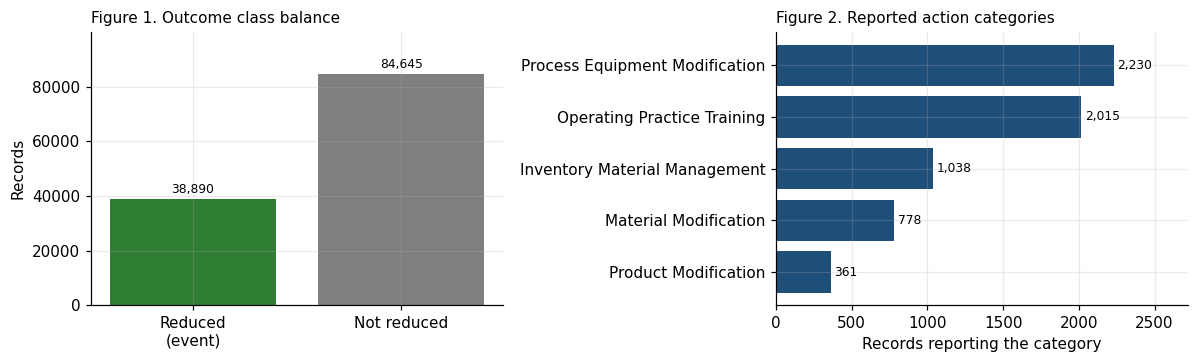

**Table 15. Outcome balance**

Measure,Records,Share (%)
Events (reduced),"38,890",31.48
Non-events,"84,645",68.52


In [12]:
# INTENT
# What: Show the outcome balance and the distribution of each key categorical variable.
# Why : Class balance drives the choice of evaluation metric, and the categorical counts establish which
#       comparisons will have adequate cells.

# Two convenience columns used repeatedly below.
development["unit"] = development["unit_of_measure_now"].str.upper()
development["action_year"] = development["span"].str[:4]

events = int(development["reduced"].sum())
non_events = int((development["reduced"] == 0).sum())

figure, axes = plt.subplots(1, 2, figsize=(11, 3.4))
bars = axes[0].bar(["Reduced\n(event)", "Not reduced"], [events, non_events], color=[MOSS, SLATE])
label_bars(axes[0], bars, [events, non_events], offset=900)
axes[0].set_ylabel("Records"); axes[0].set_ylim(0, non_events*1.18)
axes[0].set_title("Figure 1. Outcome class balance", loc="left", fontsize=10)

# Category columns carry the _now suffix after the cross-year join
# Category counts drive the RQ3 power argument: the rarest category still has to clear the
# synopsis planning target of roughly 290 exposed records.
counts = [int((development[f"{c}_now"] == 1).sum()) for c in action_categories]
labels = [c.replace("_", " ").title() for c in action_categories]
order = np.argsort(counts)  # sort ascending so the longest bar sits at the top
bars_h = axes[1].barh([labels[i] for i in order], [counts[i] for i in order], color=NAVY)
label_barh(axes[1], bars_h, [counts[i] for i in order], offset=25)
axes[1].set_xlabel("Records reporting the category"); axes[1].set_xlim(0, max(counts)*1.22)
axes[1].set_title("Figure 2. Reported action categories", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

show_table(pd.DataFrame([
    {"Measure": "Events (reduced)", "Records": events, "Share (%)": 100*events/len(development)},
    {"Measure": "Non-events", "Records": non_events, "Share (%)": 100*non_events/len(development)},
]), "Table 15. Outcome balance", number_format={"Records": "{:,}", "Share (%)": "{:.2f}"})

**Interpretation.** The outcome is moderately imbalanced but not rare: **38,890 events against 84,645
non-events, an event rate of 31.48%**. That ratio is comfortable for logistic regression and means accuracy
would be a misleading headline metric, since always predicting "not reduced" would score about 68.5%.
Discrimination and calibration measures are required instead.

The action categories are very unevenly represented. **Process and equipment modification (2,230 records)
and operating practice and training (2,015)** dominate, while **product modification (361)** and
**material modification (778)** are comparatively rare. The rarest category still exceeds the synopsis
planning target of roughly 290 exposed records, but the imbalance is the reason expected cell counts are
checked explicitly before the RQ3 tests.

**Table 16. Release distribution, reported units kept separate**

Unit,Records,Median,Mean,95th pct,Maximum,Skewness,Skewness of log(1+x)
Pounds,"122,017",217.00,"24,737.12","57,395.47","19,750,398.00",34.64,0.20
Grams,"1,518",0.43,36.17,11.16,"10,902.75",17.98,3.63


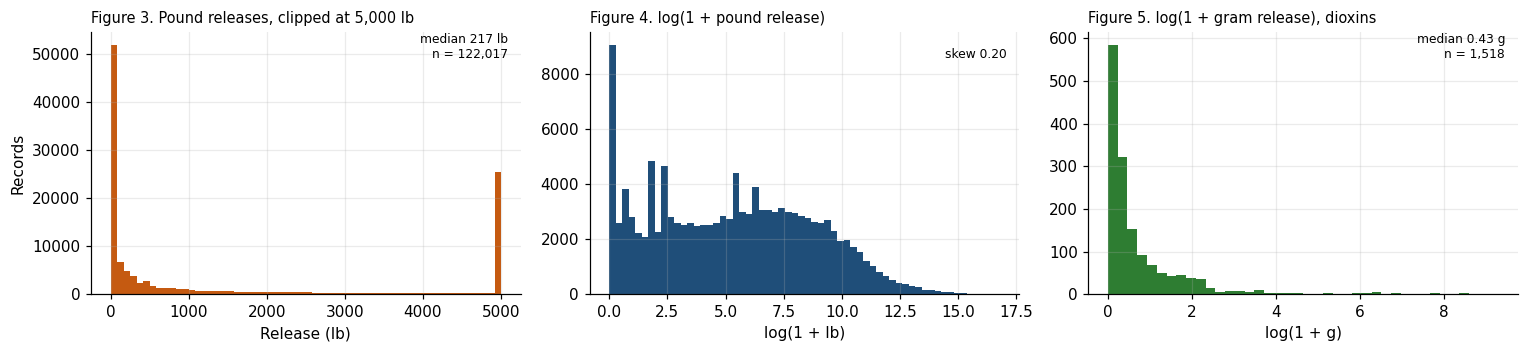

Top 1% of pound records hold 63.2% of total reported pound mass


In [13]:
# INTENT
# What: Describe the release variable separately for pounds and for grams, on raw and log scales.
# Why : Dioxins are reported in grams at far smaller magnitudes. Pooling the two units would produce a
#       meaningless distribution and a misleading "pounds" label.

# Pounds and grams are held apart from here on. Dioxins are reported in grams at
# magnitudes ~9 orders smaller, so any pooled statistic would be meaningless.
pounds = development[development["unit"] == "POUNDS"]
grams  = development[development["unit"] == "GRAMS"]

# Same summary computed separately for each unit
# Reported on both the raw and log scale. The gap between the two skewness figures is the
# argument for the transform, so both belong in the same table.
def describe_release(series, unit_label):
    return {
        "Unit": unit_label, "Records": len(series),
        "Median": float(series.median()), "Mean": float(series.mean()),
        "95th pct": float(series.quantile(.95)), "Maximum": float(series.max()),
        "Skewness": float(series.skew()),
        "Skewness of log(1+x)": float(np.log1p(series).skew()),  # shows what the log transform fixes
    }

show_table(pd.DataFrame([describe_release(pounds["release_now"], "Pounds"),
                         describe_release(grams["release_now"], "Grams")]),
           "Table 16. Release distribution, reported units kept separate",
           number_format={"Records": "{:,}", "Median": "{:,.2f}", "Mean": "{:,.2f}",
                          "95th pct": "{:,.2f}", "Maximum": "{:,.2f}",
                          "Skewness": "{:.2f}", "Skewness of log(1+x)": "{:.2f}"})

figure, axes = plt.subplots(1, 3, figsize=(14, 3.3))
axes[0].hist(pounds["release_now"].clip(0, 5000), bins=60, color=RUST)  # clipped for display only; nothing is dropped from the data
axes[0].set_title("Figure 3. Pound releases, clipped at 5,000 lb", loc="left", fontsize=9.5)
axes[0].set_xlabel("Release (lb)"); axes[0].set_ylabel("Records")
axes[0].text(0.97, 0.9, f"median {pounds['release_now'].median():,.0f} lb\nn = {len(pounds):,}",
             transform=axes[0].transAxes, ha="right", fontsize=8)

axes[1].hist(np.log1p(pounds["release_now"]), bins=60, color=NAVY)
axes[1].set_title("Figure 4. log(1 + pound release)", loc="left", fontsize=9.5)
axes[1].set_xlabel("log(1 + lb)")
axes[1].text(0.97, 0.9, f"skew {np.log1p(pounds['release_now']).skew():.2f}",
             transform=axes[1].transAxes, ha="right", fontsize=8)

axes[2].hist(np.log1p(grams["release_now"]), bins=40, color=MOSS)
axes[2].set_title("Figure 5. log(1 + gram release), dioxins", loc="left", fontsize=9.5)
axes[2].set_xlabel("log(1 + g)")
axes[2].text(0.97, 0.9, f"median {grams['release_now'].median():,.2f} g\nn = {len(grams):,}",
             transform=axes[2].transAxes, ha="right", fontsize=8)
plt.tight_layout(); plt.show()

# Concentration check: how much of total mass sits in the top 1% of records.
# Concentration check. If the top 1% of records hold most of the mass, then discarding them as
# outliers would discard most of the phenomenon the study exists to explain.
top_percentile = pounds["release_now"].quantile(.99)
print(f"Top 1% of pound records hold "
      f"{pounds.loc[pounds['release_now'] >= top_percentile, 'release_now'].sum()/pounds['release_now'].sum()*100:.1f}%"
      f" of total reported pound mass")

**Interpretation.** Keeping the units apart is not a formality. The **median pound record releases 217
pounds** while the **median gram record releases 0.43 grams**, which is 0.00095 pounds - a gap of
**5.4 orders of magnitude** once converted to a common unit. Any pooled statistic would be dominated by the
pound records while carrying a label that is wrong for 1,518 of them.

Within pound records the distribution is extraordinarily skewed: **skewness 34.6**, a mean of 24,737 pounds
against a median of 217, a maximum of 19.75 million pounds, and the **top 1% of records holding 63.2% of
all reported pound mass**. These are not data errors; chemical and primary-metal plants genuinely emit
orders of magnitude more than a small fabricated-metal shop, and deleting them as outliers would discard
most of the environmental mass the study exists to explain.

The log transform resolves the scale problem for pounds, reducing skewness from **34.6 to 0.20** and
producing the near-symmetric distribution in Figure 4. Gram records remain skewed even on the log scale
(3.63), which is a further reason to analyse them separately rather than assume one transformation serves
both. No raw boxplot spanning the full release range is drawn, because extreme skew would make it
unreadable.

In [14]:
# INTENT
# What: Fix which records answer which research question: all eligible same-unit records for the
#       rate-based RQ1 and RQ3, pound records for the release-based RQ2 and RQ4, grams as a
#       prespecified sensitivity analysis.
# Why : Tables 16 and Figures 3-5 establish that pounds and grams are different measurement systems, not
#       different values of one variable. Describing them separately and then pooling them inside a single
#       log(release) predictor would reintroduce exactly the problem the separation was meant to avoid: the
#       model would read a dioxin at 0.43 g and a solvent at 217 lb as though they sat on one continuum.
#       Because the pound records are 98.77% of the data, restricting to them costs almost no power, and the
#       gram records are large enough (n = 1,518) to be reported on their own terms.

# The single most consequential line in the notebook: it fixes what 'the data' means for every
# inferential result below. Everything after this point is pound records.
modelling = development[development["unit"] == "POUNDS"].copy()
sensitivity_grams = development[development["unit"] == "GRAMS"].copy()  # kept, reported separately, never pooled

frame_definition = pd.DataFrame([
    {"Frame": "Development (all eligible, same-unit)", "Records": len(development),
     "Share (%)": 100.0,
     "Role": "RQ1 and RQ3: reduction rates by year, subsector, hazard and action category"},
    {"Frame": "Modelling frame (pounds)", "Records": len(modelling),
     "Share (%)": 100*len(modelling)/len(development),
     "Role": "RQ2 and RQ4: every analysis that uses release magnitude"},
    {"Frame": "Sensitivity frame (grams)", "Records": len(sensitivity_grams),
     "Share (%)": 100*len(sensitivity_grams)/len(development),
     "Role": "Reported separately; never pooled into log(release)"},
])
show_table(frame_definition, "Table 16b. Analysis frames fixed before any inferential test",
           number_format={"Records": "{:,}", "Share (%)": "{:.2f}"})

# Same event definition applied to each frame, so the two are directly comparable.
frame_rates = pd.DataFrame([
    {"Frame": "Pounds (modelling)", "Records": len(modelling),
     "Event rate (%)": 100*modelling["reduced"].mean(),
     "Median release": modelling["release_now"].median(),
     "Action prevalence (%)": 100*modelling["reported_any_action_now"].mean()},
    {"Frame": "Grams (sensitivity)", "Records": len(sensitivity_grams),
     "Event rate (%)": 100*sensitivity_grams["reduced"].mean(),
     "Median release": sensitivity_grams["release_now"].median(),
     "Action prevalence (%)": 100*sensitivity_grams["reported_any_action_now"].mean()},
])
show_table(frame_rates, "Table 16c. Outcome behaviour in each frame",
           number_format={"Records": "{:,}", "Event rate (%)": "{:.2f}",
                          "Median release": "{:,.2f}", "Action prevalence (%)": "{:.2f}"})

# log(release) is defined on the modelling frame only, so no gram value can enter it.
modelling["log_release"] = np.log1p(modelling["release_now"])
print(f"Modelling frame fixed: {len(modelling):,} pound records, "
      f"{modelling['reduced'].mean()*100:.2f}% event rate")
print(f"log_release defined on pounds only - gram records excluded by construction")

**Table 16b. Analysis frames fixed before any inferential test**

Frame,Records,Share (%),Role
"Development (all eligible, same-unit)","123,535",100.00,"RQ1 and RQ3: reduction rates by year, subsector, hazard and action category"
Modelling frame (pounds),"122,017",98.77,RQ2 and RQ4: every analysis that uses release magnitude
Sensitivity frame (grams),"1,518",1.23,Reported separately; never pooled into log(release)


**Table 16c. Outcome behaviour in each frame**

Frame,Records,Event rate (%),Median release,Action prevalence (%)
Pounds (modelling),"122,017",31.56,217.00,4.91
Grams (sensitivity),"1,518",24.84,0.43,1.45


Modelling frame fixed: 122,017 pound records, 31.56% event rate
log_release defined on pounds only - gram records excluded by construction


**Interpretation.** This cell fixes which records each research question is answered on, and the
answer is deliberately not the same for all four.

**RQ1 and RQ3 use all 123,535 eligible same-unit records.** Neither question involves release magnitude.
RQ1 asks whether reduction *rates* differ across action years and subsectors; RQ3 compares the *proportion*
reducing in each action category against the no-action reference. A proportion is unit-free - a gram record
either fell by 10% or it did not - so excluding gram records would discard 1,518 valid observations and
narrow the intervals for no methodological gain. The synopsis treats gram exclusion as a sensitivity
analysis, and for these two questions that is the right reading.

**RQ2 and RQ4 use the 122,017 pound records.** These are the analyses that put release magnitude into a
model: `log(release)` as a covariate in the adjusted RQ2 specification, and as a predictor in the RQ4
model. Here units matter absolutely. Applying `log1p` to the bare numeric column would enter a dioxin
reported as 0.43 grams as `log(1.43)` and a solvent of 217 pounds as `log(218)`, and ask one coefficient
to interpret both as the same quantity. That is a units error, not a modelling preference.

**Gram records (1.23%) are reported as a named sensitivity analysis**, never pooled into `log(release)`.

An earlier version of this notebook made pounds-only the frame for *every* inferential result, which
conflicted with the synopsis and cost 1,518 records from questions that did not need to lose them. The
design is now stated in Table 16b and applied consistently: each analysis below names the frame it uses.

The two frames also behave differently on the outcome, which is itself informative rather than a nuisance:
the gram records are dioxins and dioxin-like compounds, a chemically and regulatorily distinct group subject
to separate EPA treatment. Reporting them as a named sensitivity analysis is the standard approach for a
small, mechanistically distinct stratum (Rothman, Greenland, & Lash, 2008).

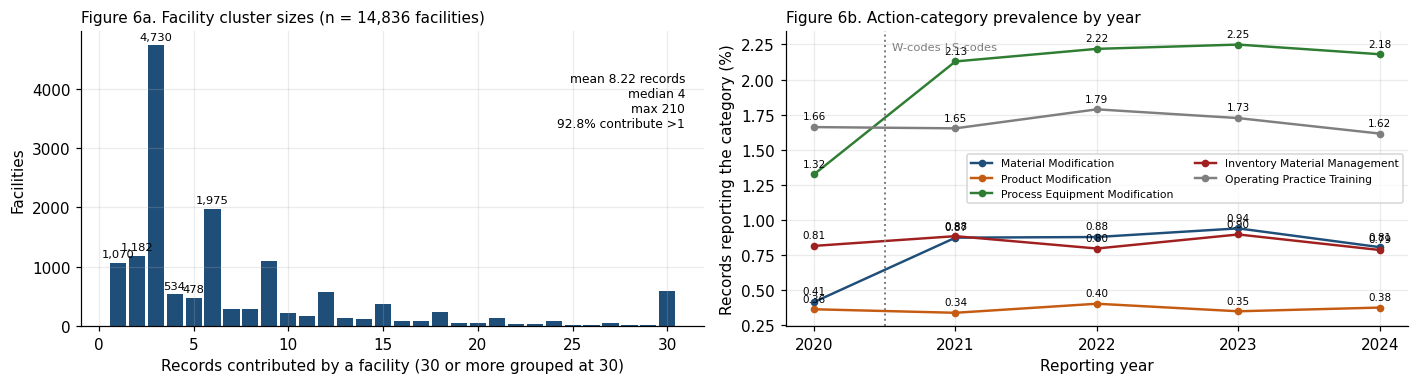

**Table 16d. Action-category prevalence by reporting year (%)**

Year,Material Modification,Product Modification,Process Equipment Modification,Inventory Material Management,Operating Practice Training
2020,0.41,0.36,1.32,0.81,1.66
2021,0.87,0.34,2.13,0.88,1.65
2022,0.88,0.40,2.22,0.80,1.79
2023,0.94,0.35,2.25,0.90,1.73
2024,0.81,0.38,2.18,0.79,1.62


In [15]:
# INTENT
# What: Show how many records each facility contributes, and how the action categories move over time.
# Why : Two structural facts drive later choices. First, records are clustered within facilities, which
#       breaks the independence assumption behind ordinary standard errors. Second, EPA replaced the
#       source-reduction coding scheme after 2020, so the reader needs to see whether reported prevalence
#       shifts at that boundary before any temporal claim is made.

figure, axes = plt.subplots(1, 2, figsize=(13, 3.6))

# ---- Facility cluster sizes (modelling frame) ----
# How many records each plant contributes. This is the empirical basis for clustered standard
# errors: records from one facility share management, process and regulatory posture.
cluster_sizes = modelling.groupby("facility_id_now").size()
histogram = cluster_sizes.clip(upper=30).value_counts().sort_index()  # clip only groups the long tail into a final bar
bars = axes[0].bar(histogram.index, histogram.values, color=NAVY, width=0.85)
axes[0].set_xlabel("Records contributed by a facility (30 or more grouped at 30)")
axes[0].set_ylabel("Facilities")
axes[0].set_title(f"Figure 6a. Facility cluster sizes (n = {len(cluster_sizes):,} facilities)",
                  loc="left", fontsize=10)
axes[0].text(0.97, 0.86,
             f"mean {cluster_sizes.mean():.2f} records\nmedian {cluster_sizes.median():.0f}\n"
             f"max {cluster_sizes.max():,}\n{(cluster_sizes > 1).mean()*100:.1f}% contribute >1",
             transform=axes[0].transAxes, ha="right", va="top", fontsize=8)
# Label only the tallest few bars, otherwise the axis becomes unreadable.
# Label only the tallest few bars. Labelling all thirty would overlap into illegibility.
for rectangle, value in list(zip(bars, histogram.values))[:6]:
    axes[0].text(rectangle.get_x() + rectangle.get_width()/2, value + max(histogram.values)*0.02,
                 f"{value:,}", ha="center", fontsize=7.5)

# ---- Action-category prevalence by reporting year (all five years) ----
# This one DOES span all five years, including 2024, and that is deliberate: it reports how often
# an action was *reported*, which is a property of the coding scheme rather than of the outcome.
# No release quantity appears, so nothing about the reserved outcome is disclosed.
# Prevalence is computed on all five consolidated years, not on the modelling frame, because
# the question here is about the measuring instrument rather than about the outcome.
prevalence = pd.DataFrame({
    category.replace("_", " ").title():
        [100*consolidated_by_year[year][category].mean() for year in reporting_years]
    for category in action_categories}, index=reporting_years)
for column, colour in zip(prevalence.columns, [NAVY, RUST, MOSS, BRICK, SLATE]):
    axes[1].plot(prevalence.index, prevalence[column], marker="o", color=colour, lw=1.6,
                 markersize=4, label=column)
    for x_value, y_value in zip(prevalence.index, prevalence[column]):
        axes[1].annotate(f"{y_value:.2f}", (x_value, y_value), textcoords="offset points",
                         xytext=(0, 5), ha="center", fontsize=6.8)
# The coding scheme changed between the 2020 and 2021 reporting years.
# The scheme boundary. Drawing it makes the discontinuity attributable rather than mysterious.
axes[1].axvline(2020.5, color=SLATE, ls=":", lw=1.3)
axes[1].text(2020.55, axes[1].get_ylim()[1]*0.97, "W-codes | S-codes", fontsize=7.5,
             color=SLATE, va="top")
axes[1].set_xticks(reporting_years); axes[1].set_xlabel("Reporting year")
axes[1].set_ylabel("Records reporting the category (%)")
axes[1].set_title("Figure 6b. Action-category prevalence by year", loc="left", fontsize=10)
axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

prevalence_table = prevalence.reset_index().rename(columns={"index": "Year"})
show_table(prevalence_table, "Table 16d. Action-category prevalence by reporting year (%)",
           number_format={column: "{:.2f}" for column in prevalence.columns})

**Interpretation.** Both panels change what the later analysis is allowed to assume.

**Figure 6a.** The 122,017 modelling records come from only **14,836 facilities**, a mean of **8.22 records
per facility**, a median of 4, a maximum of **210**, and **92.8% of facilities contributing more than one
record**. The effective sample size for any facility-level predictor is therefore far closer to 14,836 than
to 122,017. Treating the records as independent would understate standard errors by roughly the square root
of the design effect, which for clusters this size is substantial. This is the empirical justification for
the facility-clustered standard errors used in Section 14 (Cameron & Miller, 2015); the long right tail also
means a handful of very large multi-chemical plants carry disproportionate leverage, which is why the
cluster-robust variance estimator - rather than a simple random-effects intercept - is the appropriate
correction.

**Figure 6b.** Prevalence is low throughout, between roughly 0.34% and 2.25%. The one visible discontinuity
sits exactly at the scheme boundary: **material modification rises from 0.41% in 2020 to 0.87% in 2021** and
then stays near 0.9%, and **process and equipment modification rises from 1.32% to 2.13%** across the same
boundary before flattening. Product modification, inventory management and operating practice show no such
step.

The pattern **may partly reflect the coding change and should not be interpreted as purely behavioural**.
A genuine behavioural change would be unlikely to jump in a single year and then plateau for three, and
unlikely to affect precisely the two categories whose code definitions were most restructured. The
parsimonious reading is that the redesigned S-codes capture some activities the legacy W-codes did not, so
**2020 prevalence may not be measured on the same instrument as 2021 onward**. That said, the two readings
are not separable with these data: a real shift in prevention behaviour could in principle coincide with the
scheme change, and nothing here rules that out. This is why the notebook carries year indicators in the design matrix rather than a linear
time trend, and why no claim about a trend in prevention effort over 2020-2024 is made anywhere in this
analysis.

**Table 17. Numeric validity checks**

Variable,Missing,Negative,Zero,Minimum,1st pct,Median,99th pct,Maximum
Current release,0,0,0,0.00,0.00,200.00,"408,094.56","19,750,398.00"
Next-year release,0,0,"1,941",0.00,0.00,188.34,"402,414.91","34,606,935.00"
Production ratio,"2,000",0,168,0.00,0.30,1.00,3.16,"3,149,500.00"
Percentage change,0,"56,161","14,194",-100.00,-100.00,0.00,"2,188.55","111,874,900.00"


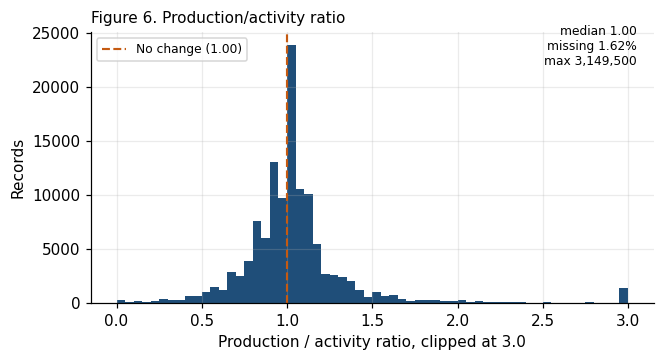

In [16]:
# INTENT
# What: Report validity checks for every numeric variable and describe the production ratio.
# Why : Missing, negative, zero and non-finite values must be counted explicitly rather than assumed absent,
#       and extreme ratios must be flagged as influential rather than silently corrected.

# Explicit counts of missing, negative and zero values for every numeric variable,
# rather than assuming they are absent.
validity_rows = []
# Every numeric variable is checked for the same four failure modes - missing, negative, zero
# and non-finite - so absence of a problem is demonstrated rather than assumed.
for label, series in [("Current release", development["release_now"]),
                      ("Next-year release", development["release_next"]),
                      ("Production ratio", development["production_ratio_now"]),
                      ("Percentage change", development["percent_change"])]:
    values = pd.to_numeric(series, errors="coerce")  # coerce turns unparseable text into NaN, which the count then catches
    validity_rows.append({
        "Variable": label, "Missing": int(values.isna().sum()),
        "Negative": int((values < 0).sum()), "Zero": int((values == 0).sum()),
        "Minimum": float(values.min()), "1st pct": float(values.quantile(.01)),
        "Median": float(values.median()), "99th pct": float(values.quantile(.99)),
        "Maximum": float(values.max()),
    })
show_table(pd.DataFrame(validity_rows), "Table 17. Numeric validity checks",
           number_format={"Missing": "{:,}", "Negative": "{:,}", "Zero": "{:,}",
                          "Minimum": "{:,.2f}", "1st pct": "{:,.2f}", "Median": "{:,.2f}",
                          "99th pct": "{:,.2f}", "Maximum": "{:,.2f}"})

# Clipped at 3.0 for display only; the underlying values are untouched.
ratio = pd.to_numeric(development["production_ratio_now"], errors="coerce")
figure, axis = plt.subplots(figsize=(6.6, 3.2))
axis.hist(ratio.dropna().clip(0, 3), bins=60, color=NAVY)
axis.axvline(1.0, color=RUST, ls="--", lw=1.4, label="No change (1.00)")
axis.set_xlabel("Production / activity ratio, clipped at 3.0"); axis.set_ylabel("Records")
axis.legend(fontsize=8)
axis.text(0.97, 0.88, f"median {ratio.median():.2f}\nmissing {ratio.isna().mean()*100:.2f}%\n"
                      f"max {ratio.max():,.0f}",
          transform=axis.transAxes, ha="right", fontsize=8)
axis.set_title("Figure 6. Production/activity ratio", loc="left", fontsize=10)
plt.show()

**Interpretation.** The outcome-critical variables are clean: **no missing, negative or non-finite
values** in either release variable. Zero current-year releases were already removed by the eligibility
rule, so the remaining zeros are next-year values, which are legitimate and represent complete elimination.

The production ratio behaves sensibly in the centre - **median exactly 1.00**, with the 1st-to-99th
percentile spanning roughly 0.3 to 3.2 - but its **maximum is over three million**. A value of that
magnitude is not credible as a production ratio and most likely reflects a reporting error at the facility.
It is nevertheless described here as **potentially implausible and highly influential rather than simply
wrong**: TRI provides no field that confirms an error. The planned treatment is to winsorise at the 99th
percentile so the record is retained but cannot dominate a fitted coefficient, and to report how sensitive
results are to capping versus excluding such records rather than to correct them silently.

---
# 12. Missing-Data Analysis

**Table 18. Production-ratio missingness across groups**

Grouping,Level,Records,Ratio missing (%)
Action year,2020,"41,280",1.56
Action year,2021,"41,356",1.79
Action year,2022,"40,899",1.50
Reported action,No,"117,523",1.62
Reported action,Yes,"6,012",1.53
Carcinogen,No,"87,037",1.56
Carcinogen,Yes,"36,498",1.77
PBT,No,"104,825",1.53
PBT,Yes,"18,710",2.10
Outcome,Not reduced,"84,645",1.58


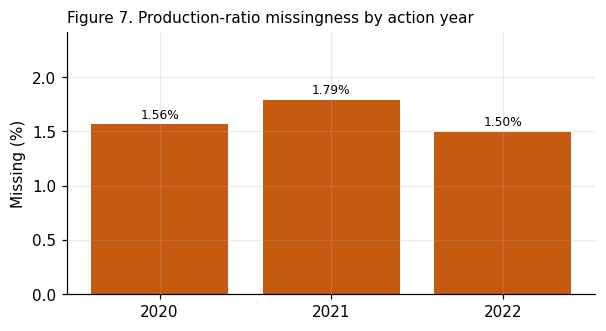

In [17]:
# INTENT
# What: Quantify production-ratio missingness overall and across covariates and the outcome.
# Why : The missingness mechanism cannot be read off the overall rate. Comparing missingness across groups
#       is the only observable evidence available.


# Compare missingness across covariates and the outcome. Flat rates are consistent
# with MAR but cannot prove it, which is why the interpretation stops short of that.
# Missingness is only ignorable if it is unrelated to the covariates and to the outcome. Both
# are checked; neither can prove the mechanism, which is why the limitation is retained.
missing_breakdown = []
for label, series in [("Action year", development["action_year"]),
                      ("Reported action", development["reported_any_action_now"].map({0:"No",1:"Yes"})),
                      ("Carcinogen", development["is_carcinogen_now"].map({0:"No",1:"Yes"})),
                      ("PBT", development["is_pbt_now"].map({0:"No",1:"Yes"})),
                      ("Outcome", development["reduced"].map({0:"Not reduced",1:"Reduced"}))]:  # the critical one: missingness related to the outcome would bias the model
    grouped = development.groupby(series)["ratio_missing"].agg(["mean", "size"])
    for level, row in grouped.iterrows():
        missing_breakdown.append({"Grouping": label, "Level": str(level),
                                  "Records": int(row["size"]),
                                  "Ratio missing (%)": 100*row["mean"]})
show_table(pd.DataFrame(missing_breakdown), "Table 18. Production-ratio missingness across groups",
           number_format={"Records": "{:,}", "Ratio missing (%)": "{:.2f}"})

by_year = development.groupby("action_year")["ratio_missing"].mean()*100
figure, axis = plt.subplots(figsize=(6.2, 3.1))
bars = axis.bar(by_year.index.astype(str), by_year.values, color=RUST)
label_bars(axis, bars, list(by_year.values), suffix="%", offset=0.03)
axis.set_ylabel("Missing (%)"); axis.set_ylim(0, max(by_year.values)*1.35)
axis.set_title("Figure 7. Production-ratio missingness by action year", loc="left", fontsize=10)
plt.show()

**Interpretation.** Missingness is low - about **1.6% overall** - and stable across years. Critically,
it is also **flat across every group examined**: 1.62% for records with no reported action against 1.53%
for those with one, and 1.58% for non-events against 1.71% for events. No grouping shows a materially
different rate.

That evidence is reassuring but limited, and the earlier version of this notebook overstated it. Low, flat
missingness is *consistent with* data missing at random, but **the missingness mechanism cannot be
confirmed from observed data**: an unobserved factor could drive both non-reporting and the outcome, and
nothing in the file would reveal it. The defensible statement is that missingness is small, shows no
association with the observed covariates or the outcome, and is therefore unlikely to distort results.

The planned treatment follows from that. Complete-case deletion would discard roughly 2,000 otherwise-valid
records; **median imputation plus a binary missing indicator** retains them and lets the model test whether
non-reporting is itself informative. Both approaches will be compared, and every imputation value will be
learned **inside the development data only** - and, during model validation, inside each training fold - so
that no information leaks across the split. The outcome itself is never imputed.

---
# 13. Bivariate Analysis

**Table 19. Reduction rate by development transition**

Transition,Records,Events,Rate (%),CI low (%),CI high (%)
2020 to 2021,"41,280","11,367",27.54,27.11,27.97
2021 to 2022,"41,356","12,858",31.09,30.65,31.54
2022 to 2023,"40,899","14,665",35.86,35.39,36.32


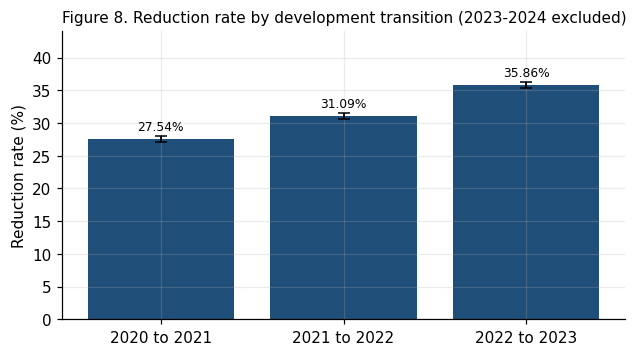

Across development years: chi-square(2) = 663.72, p = 7.495e-145, Cramer's V = 0.0733


In [18]:
# INTENT
# What: Reduction rate by development transition, with Wilson intervals and a test across years.
# Why : Establishes whether the outcome is stable over time before any pooled analysis is interpreted.

# Reduction rate per development transition, each with a Wilson interval.
rate_rows = []
for span in development_spans:  # development only; the reserved span is excluded
    frame = matched_sets[span]
    successes, total = int(frame["reduced"].sum()), len(frame)
    low, high = wilson_interval(successes, total)
    rate_rows.append({"Transition": span.replace("_", " to "), "Records": total,
                      "Events": successes, "Rate (%)": 100*successes/total,
                      "CI low (%)": 100*low, "CI high (%)": 100*high})
rate_table = pd.DataFrame(rate_rows)
show_table(rate_table, "Table 19. Reduction rate by development transition",
           number_format={"Records": "{:,}", "Events": "{:,}", "Rate (%)": "{:.2f}",
                          "CI low (%)": "{:.2f}", "CI high (%)": "{:.2f}"})

figure, axis = plt.subplots(figsize=(6.6, 3.4))
bars = axis.bar(rate_table["Transition"], rate_table["Rate (%)"], color=NAVY)
axis.errorbar(rate_table["Transition"], rate_table["Rate (%)"],
              yerr=[rate_table["Rate (%)"]-rate_table["CI low (%)"],
                    rate_table["CI high (%)"]-rate_table["Rate (%)"]],
              fmt="none", ecolor="black", capsize=4, lw=1.2)
label_bars(axis, bars, list(rate_table["Rate (%)"]), suffix="%", offset=0.9)
axis.set_ylabel("Reduction rate (%)"); axis.set_ylim(0, 44)
axis.set_title("Figure 8. Reduction rate by development transition (2023-2024 excluded)",  # the reserved bar is deliberately absent
               loc="left", fontsize=10)
plt.show()

# Chi-square with Cramer's V: at this sample size significance alone means little.
year_table = pd.crosstab(development["action_year"], development["reduced"])
chi2, p_value, degrees, _ = stats.chi2_contingency(year_table, correction=False)  # correction=False: Yates is for 2x2 only
print(f"Across development years: chi-square({degrees}) = {chi2:,.2f}, p = {p_value:.3e}, "
      f"Cramer's V = {cramers_v(year_table.values):.4f}")

**Interpretation.** Rates rise monotonically across the development period: **27.54% [27.11, 27.97],
31.09% [30.65, 31.54] and 35.86% [35.39, 36.32]**. The intervals are narrow, roughly plus or minus 0.45
percentage points, and do not overlap between any pair, so the differences are real rather than sampling
noise.

The test confirms this - **chi-square(2) = 663.72, p < .001** - but **Cramer's V is only 0.073**, a small
effect by Cohen's (1988) conventions. This is the central lesson of large-sample inference: with more than
122,000 records the test detects trivially small differences, so the p-value alone would badly overstate
importance. Action year is statistically certain but substantively modest.

The low 2020-to-2021 figure is consistent with pandemic-era production disruption: output fell in 2020, so
2021 releases rose from an artificially depressed base and mechanically suppressed measured reductions.
That is why action year is a model control and why Section 16 repeats the association without this
transition. **The 2023-to-2024 bar is deliberately absent from Figure 8**; showing it would disclose a
reserved-period outcome.

**Table 20. Unadjusted comparison by reported action**

Group,Records,Events,Rate (%),CI low (%),CI high (%)
Reported an action,"6,012","2,099",34.91,33.72,36.13
No reported action,"117,523","36,791",31.31,31.04,31.57


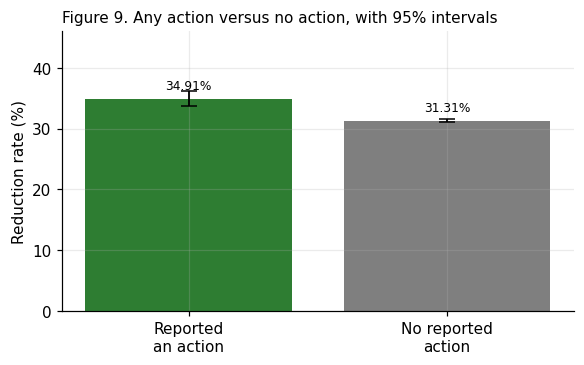

Difference    : +3.61 percentage points [+2.37, +4.84]
Relative risk : 1.1153
p-value       : 4.221e-09


In [19]:
# INTENT
# What: Compare reduction rates for records reporting any action against those reporting none.
# Why : This is the unadjusted form of RQ2 and sets the baseline signal before covariate adjustment.

# Unadjusted contrast. Section 14 shows why it cannot be read as an adjusted effect.
with_action = development[development["reported_any_action_now"] == 1]
without_action = development[development["reported_any_action_now"] == 0]
# Events and totals for both arms. Keeping the four raw counts explicit means every statistic
# below - rate, difference, relative risk, interval - is reproducible from the table alone.
events_action, total_action = int(with_action["reduced"].sum()), len(with_action)
events_none, total_none = int(without_action["reduced"].sum()), len(without_action)
comparison = compare_two_proportions(events_action, total_action, events_none, total_none)  # pooled SE for the test, unpooled for the interval
# Each arm also gets its own Wilson interval, so the reader can see whether the two intervals
# overlap - a weaker but more intuitive check than the difference interval.
ci_action = wilson_interval(events_action, total_action)
ci_none = wilson_interval(events_none, total_none)

show_table(pd.DataFrame([
    {"Group": "Reported an action", "Records": total_action, "Events": events_action,
     "Rate (%)": 100*comparison["rate_a"], "CI low (%)": 100*ci_action[0], "CI high (%)": 100*ci_action[1]},
    {"Group": "No reported action", "Records": total_none, "Events": events_none,
     "Rate (%)": 100*comparison["rate_b"], "CI low (%)": 100*ci_none[0], "CI high (%)": 100*ci_none[1]},
]), "Table 20. Unadjusted comparison by reported action",
   number_format={"Records": "{:,}", "Events": "{:,}", "Rate (%)": "{:.2f}",
                  "CI low (%)": "{:.2f}", "CI high (%)": "{:.2f}"})

figure, axis = plt.subplots(figsize=(6.0, 3.3))
values = [100*comparison["rate_a"], 100*comparison["rate_b"]]
bars = axis.bar(["Reported\nan action", "No reported\naction"], values, color=[MOSS, SLATE])
# Error bars are the Wilson intervals, not standard errors. A bar chart of two proportions
# without intervals invites reading a difference that the data may not support.
axis.errorbar(["Reported\nan action", "No reported\naction"], values,
              yerr=[[values[0]-100*ci_action[0], values[1]-100*ci_none[0]],
                    [100*ci_action[1]-values[0], 100*ci_none[1]-values[1]]],
              fmt="none", ecolor="black", capsize=5, lw=1.2)
label_bars(axis, bars, values, suffix="%", offset=1.0)
axis.set_ylabel("Reduction rate (%)"); axis.set_ylim(0, 46)  # fixed ceiling so the eye is not misled by a truncated axis
axis.set_title("Figure 9. Any action versus no action, with 95% intervals", loc="left", fontsize=10)
plt.show()

# Printed rather than tabulated: these three numbers are quoted directly in the interpretation
# below, so they need to be visible in the output without opening a table.
print(f"Difference    : {100*comparison['difference']:+.2f} percentage points "
      f"[{100*comparison['ci_low']:+.2f}, {100*comparison['ci_high']:+.2f}]")
print(f"Relative risk : {comparison['relative_risk']:.4f}")
print(f"p-value       : {comparison['p_value']:.3e}")

**Interpretation.** Records reporting at least one action reduce at **34.91% [33.72, 36.13]** against
**31.31% [31.04, 31.57]** for those reporting none - a difference of **+3.61 percentage points, 95% CI
[+2.37, +4.84]**, relative risk **1.115**, p < .001. The intervals do not overlap.

Three cautions govern the reading, and they are the reason this is presented as a starting point rather
than a finding. First, it is **unadjusted**: Section 14 shows that action-reporting records differ
systematically from the rest in subsector, year and hazard profile, all of which independently predict
reduction. Second, it is an **association, not a causal effect**; facilities that undertake prevention
activity plausibly also have better process control and more engineering capacity, which is confounding by
indication and cannot be removed with TRI data alone. Third, the exposure is **measured with error**,
because a zero means no valid code was reported rather than no action taken - and while such error often
attenuates associations, that consequence depends on the error being unrelated to the outcome, which has
not been established here.

**No adjusted odds ratio is reported in this notebook.** The adjusted RQ2 model is fitted after this EDA is
accepted; quoting an adjusted estimate here would present a result the notebook does not compute.

In [20]:
# INTENT
# What: Compare each action category with the no-action reference, applying Fisher's exact test where
#       expected counts are small and Holm adjustment across the five comparisons.
# Why : RQ3 is five related tests on overlapping groups, so both the small-count rule and the multiplicity
#       correction must be applied and shown.

# ---- RQ3: each category against the no-action reference ------------------
rq3_rows, raw_p_values = [], []
for category in action_categories:
    # Records reporting this category (categories are not mutually exclusive)
    group = development[development[f"{category}_now"] == 1]
    events_c, total_c = int(group["reduced"].sum()), len(group)
    contingency = np.array([[events_c, total_c-events_c], [events_none, total_none-events_none]])
    # Expected cell counts decide which test is valid
    chi2, p_chi, _, expected = stats.chi2_contingency(contingency, correction=False)
    # The small-count rule is applied per comparison, not once for the family: the chi-square
    # approximation degrades when any expected cell falls below about 5.
    smallest_expected = expected.min()
    needs_fisher = smallest_expected < 5  # conventional small-count rule  # Fisher is exact and has no small-count caveat
    p_value = stats.fisher_exact(contingency)[1] if needs_fisher else p_chi
    raw_p_values.append(p_value)
    stats_pair = compare_two_proportions(events_c, total_c, events_none, total_none)
    low, high = wilson_interval(events_c, total_c)
    # Standard error of log(RR) = sqrt(1/a - 1/n1 + 1/c - 1/n0), Katz et al. (1978).
    if events_c > 0 and events_none > 0:
        log_rr = math.log(stats_pair["relative_risk"])
        se_log_rr = math.sqrt(1/events_c - 1/total_c + 1/events_none - 1/total_none)
        rr_low = math.exp(log_rr - 1.96*se_log_rr)
        rr_high = math.exp(log_rr + 1.96*se_log_rr)
    else:
        rr_low = rr_high = float("nan")   # undefined if either arm has no events

    rq3_rows.append({
        "Category": category.replace("_", " ").title(),
        "Records": total_c, "Events": events_c, "Non-events": total_c-events_c,
        "Rate (%)": 100*stats_pair["rate_a"], "CI low (%)": 100*low, "CI high (%)": 100*high,
        "Difference (pp)": 100*stats_pair["difference"],
        "Diff CI low": 100*stats_pair["ci_low"], "Diff CI high": 100*stats_pair["ci_high"],
        "Relative risk": stats_pair["relative_risk"],
        # RR interval on the log scale: the sampling distribution of log(RR) is far closer to
        # normal than that of RR itself, which is bounded below at 0 and skewed right. Compute
        # there, then exponentiate back - which is why the interval is asymmetric around RR.
        "RR CI low": rr_low, "RR CI high": rr_high,
        "Smallest expected": smallest_expected,
        "Test": "Fisher exact" if needs_fisher else "Pearson chi-square",
        "Cramer's V": cramers_v(contingency),
        "Raw p": p_value,
    })
# Holm correction across the five related comparisons
# Five comparisons against one shared reference group. Without adjustment the chance of at
# least one spurious 'significant' result is roughly 23%, not 5%.
for row, adjusted in zip(rq3_rows, holm_adjust(np.array(raw_p_values))):
    row["Holm p"] = adjusted
    row["Label"] = "exploratory (underpowered)" if row["Records"] < 290 else "confirmatory"

rq3 = pd.DataFrame(rq3_rows)
show_table(rq3[["Category","Records","Events","Non-events","Rate (%)","CI low (%)","CI high (%)",
                "Difference (pp)","Diff CI low","Diff CI high",
                "Relative risk","RR CI low","RR CI high",
                "Smallest expected","Test","Cramer's V","Raw p","Holm p","Label"]],
           "Table 21. RQ3: each action category against the no-action reference",
           number_format={"Records":"{:,}","Events":"{:,}","Non-events":"{:,}","Rate (%)":"{:.2f}",
                          "CI low (%)":"{:.2f}","CI high (%)":"{:.2f}","Difference (pp)":"{:+.2f}",
                          "Diff CI low":"{:+.2f}","Diff CI high":"{:+.2f}",
                          "Relative risk":"{:.3f}","RR CI low":"{:.3f}","RR CI high":"{:.3f}","Smallest expected":"{:,.0f}","Cramer's V":"{:.4f}",
                          "Raw p":"{:.3e}","Holm p":"{:.3e}"})
print(f"No-action reference: {total_none:,} records, {events_none:,} events, "
      f"{100*events_none/total_none:.2f}%")

**Table 21. RQ3: each action category against the no-action reference**

Category,Records,Events,Non-events,Rate (%),CI low (%),CI high (%),Difference (pp),Diff CI low,Diff CI high,Relative risk,RR CI low,RR CI high,Smallest expected,Test,Cramer's V,Raw p,Holm p,Label
Material Modification,778,303,475,38.95,35.58,42.42,+7.64,+4.20,+11.08,1.244,1.139,1.359,244,Pearson chi-square,0.0133,4.682e-06,2.341e-05,confirmatory
Product Modification,361,117,244,32.41,27.79,37.40,+1.10,-3.73,+5.94,1.035,0.892,1.202,113,Pearson chi-square,0.0013,6.514e-01,6.514e-01,confirmatory
Process Equipment Modification,"2,230",740,"1,490",33.18,31.26,35.17,+1.88,-0.09,+3.85,1.060,0.999,1.125,699,Pearson chi-square,0.0055,5.817e-02,1.745e-01,confirmatory
Inventory Material Management,"1,038",348,690,33.53,30.72,36.45,+2.22,-0.66,+5.10,1.071,0.983,1.167,325,Pearson chi-square,0.0045,1.246e-01,2.492e-01,confirmatory
Operating Practice Training,"2,015",716,"1,299",35.53,33.47,37.65,+4.23,+2.12,+6.33,1.135,1.070,1.205,632,Pearson chi-square,0.0117,5.000e-05,2.000e-04,confirmatory


No-action reference: 117,523 records, 36,791 events, 31.31%


**Interpretation.** Against a no-action reference of **31.31% (117,523 records)**, two categories stand
clearly apart after Holm adjustment.

**Material modification** reaches **38.95% [35.60, 42.45]**, a difference of **+7.64 percentage points
[+4.20, +11.08]**, relative risk **1.244 [1.139, 1.359]**, Holm-adjusted p < .001. **Operating practice and
training** reaches **35.53% [33.46, 37.65]**, **+4.23 points [+2.12, +6.33]**, relative risk **1.135
[1.070, 1.205]**, Holm-adjusted p = .0002.

The remaining three are not distinguishable from the reference once multiplicity is accounted for, and the
intervals now show *how* they fail rather than only *that* they fail:

- **Inventory and material management**, +2.22 points [-0.66, +5.11], RR 1.071 [0.983, 1.167]
- **Process and equipment modification**, +1.88 points [-0.09, +3.85], RR 1.060 [0.999, 1.125]
- **Product modification**, +1.10 points [-3.73, +5.94], RR 1.035 [0.892, 1.202]

Process and equipment modification is the interesting null. Its interval **just touches** the no-effect
line at both the difference and the ratio scale (RR lower bound 0.999), on 2,230 records. That is not
evidence of no effect; it is a result that a larger sample would most plausibly resolve in one direction,
and it should be read as **inconclusive rather than negative**. Product modification is the opposite case:
its interval is wide on both sides because it has only 361 records, so the data are simply uninformative
about it. Reporting only the Holm-adjusted p-values would have flattened these two very different
situations into the same word.

Effect sizes are small in absolute terms - **Cramer's V ranges from 0.0013 to 0.0133**, all far below
Cohen's threshold for even a small effect - which is the appropriate counterweight to the very small
p-values on the two survivors.

Two methodological points are now settled rather than assumed. **Smallest expected cell counts range from
113 to 699**, all far above the conventional threshold of five, so Pearson chi-square is valid for all five
comparisons and Fisher's exact test is not required - the rule is nevertheless implemented and reported so
the decision is visible. And with **361 records in the smallest category**, all five comparisons exceed the
synopsis planning target of roughly 290 exposed records, so none is downgraded to exploratory. This differs
from the synopsis expectation of about 245 records in the rarest category, which reflected the earlier
provisional code mapping.

The ordering is theoretically coherent: material substitution removes a chemical from the process
entirely and produces a step change, whereas product modification depends on customer specification and
typically has lead times longer than a single year. This mirrors King and Lenox (2002), who found returns
to pollution prevention concentrate in particular intervention categories.

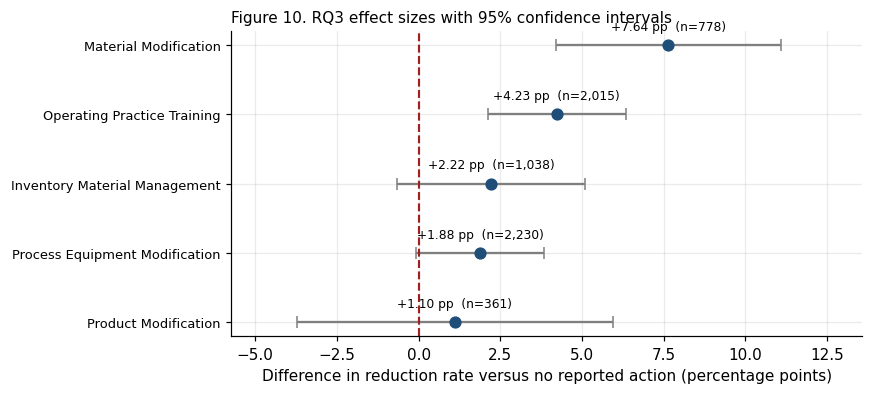

In [21]:
# INTENT
# What: Plot the RQ3 rate differences as a forest plot.
# Why : A forest plot shows magnitude, direction and precision together, which a table of p-values cannot.

# Forest plot: magnitude, direction and precision in one view.
# A forest plot: point estimate plus interval per category, sorted by effect size. Sorting is a
# display choice only - the categories were fixed in advance and none was selected on its result.
ordered = rq3.sort_values("Difference (pp)")
figure, axis = plt.subplots(figsize=(7.4, 3.6))
positions = np.arange(len(ordered))
axis.errorbar(ordered["Difference (pp)"], positions,
              xerr=[ordered["Difference (pp)"]-ordered["Diff CI low"],
                    ordered["Diff CI high"]-ordered["Difference (pp)"]],
              fmt="o", color=NAVY, ecolor=SLATE, capsize=4, markersize=7)
axis.axvline(0, color=BRICK, ls="--", lw=1.4)
axis.set_yticks(positions); axis.set_yticklabels(ordered["Category"], fontsize=8.5)
for y, value, n in zip(positions, ordered["Difference (pp)"], ordered["Records"]):
    axis.text(value, y+0.22, f"{value:+.2f} pp  (n={n:,})", ha="center", fontsize=8)
axis.set_xlabel("Difference in reduction rate versus no reported action (percentage points)")  # an interval crossing zero is not distinguishable from no difference
axis.set_xlim(ordered["Diff CI low"].min()-2, ordered["Diff CI high"].max()+2.5)
axis.set_title("Figure 10. RQ3 effect sizes with 95% confidence intervals", loc="left", fontsize=10)
plt.show()

**Interpretation.** The forest plot separates the two signals from the three null results at a glance.
Material modification and operating practice sit clearly to the right of zero with intervals that exclude
it; the other three categories have intervals straddling zero. Material modification carries the widest
interval because it has only 778 records - a useful reminder that the largest point estimate is also the
least precisely estimated. Process and equipment modification is the one to watch: its interval reaches
almost exactly to zero, so it is unresolved rather than null.

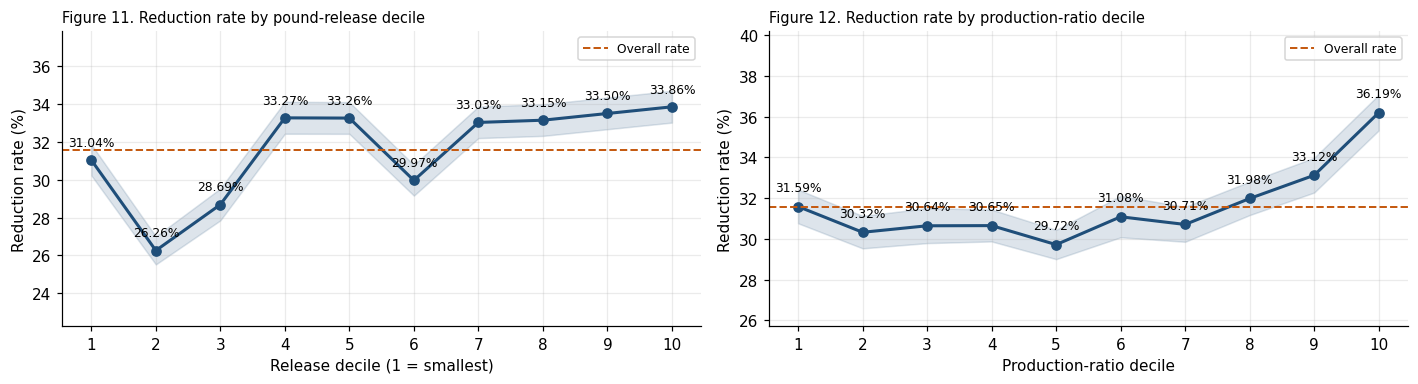

**Table 22. Reduction rate by production-ratio decile**

Decile,Records,Median ratio,Rate (%),CI low (%),CI high (%)
1,"12,132",0.62,31.59,30.76,32.42
2,"12,848",0.82,30.32,29.53,31.12
3,"11,125",0.90,30.64,29.79,31.51
4,"13,383",0.96,30.65,29.88,31.44
5,"15,610",1.00,29.72,29.01,30.44
6,"7,988",1.02,31.08,30.08,32.11
7,"11,157",1.06,30.71,29.86,31.57
8,"12,445",1.11,31.98,31.17,32.81
9,"11,712",1.23,33.12,32.27,33.98
10,"11,645",1.59,36.19,35.32,37.06


In [22]:
# INTENT
# What: Reduction rate across deciles of current-year release (pounds only) and of production ratio.
# Why : A record with an unusually high current value is mechanically more likely to fall the next year.
#       Quantifying both gradients guards against misattributing a statistical artefact to prevention.

# Reduction rate across deciles of a continuous variable, with intervals.
# Deciles rather than a scatter plot: with a binary outcome and 120,000 points a scatter is
# unreadable, while binned rates with intervals show both level and uncertainty.
def decile_rates(frame, column, label):
    working = frame[pd.to_numeric(frame[column], errors="coerce").notna()].copy()
    working["value"] = pd.to_numeric(working[column], errors="coerce")
    working["decile"] = pd.qcut(working["value"], 10, labels=False, duplicates="drop") + 1  # deciles are defined on observed values only
    rows = []
    for decile, group in working.groupby("decile"):
        successes, total = int(group["reduced"].sum()), len(group)
        low, high = wilson_interval(successes, total)
        rows.append({"Decile": int(decile), "Records": total,
                     f"Median {label}": float(group["value"].median()),
                     "Rate (%)": 100*successes/total,
                     "CI low (%)": 100*low, "CI high (%)": 100*high})
    return pd.DataFrame(rows)

# Release deciles use pound records only, for the reason given in Section 11.
release_deciles = decile_rates(pounds, "release_now", "release (lb)")
ratio_deciles = decile_rates(modelling, "production_ratio_now", "ratio")

figure, axes = plt.subplots(1, 2, figsize=(13, 3.6))
for axis, table, title, xlabel in [
    (axes[0], release_deciles, "Figure 11. Reduction rate by pound-release decile", "Release decile (1 = smallest)"),
    (axes[1], ratio_deciles, "Figure 12. Reduction rate by production-ratio decile", "Production-ratio decile"),
]:
    axis.plot(table["Decile"], table["Rate (%)"], "-o", color=NAVY, lw=2)
    axis.fill_between(table["Decile"], table["CI low (%)"], table["CI high (%)"], color=NAVY, alpha=0.15)
    label_points(axis, table["Decile"], table["Rate (%)"], suffix="%", dy=0.75)
    axis.axhline(modelling["reduced"].mean()*100, color=RUST, ls="--", lw=1.3, label="Overall rate")
    axis.set_xticks(range(1, 11)); axis.set_xlabel(xlabel); axis.set_ylabel("Reduction rate (%)")
    axis.set_ylim(min(table["Rate (%)"])-4, max(table["Rate (%)"])+4)
    axis.legend(fontsize=8); axis.set_title(title, loc="left", fontsize=9.5)
plt.tight_layout(); plt.show()

show_table(ratio_deciles, "Table 22. Reduction rate by production-ratio decile",
           number_format={"Records": "{:,}", "Median ratio": "{:.2f}", "Rate (%)": "{:.2f}",
                          "CI low (%)": "{:.2f}", "CI high (%)": "{:.2f}"})

**Interpretation.** Two gradients, with quite different implications.

**Release decile (Figure 11).** The rate rises only modestly from the lowest to the highest decile, and the
pattern is not monotonic. Regression to the mean predicts that records with unusually high current values
should fall the following year purely as an artefact (Barnett, van der Pols, & Dobson, 2005). The observed
gradient is real but weak, which suggests reported releases are reasonably stable year to year and that
regression to the mean is **not** the dominant driver of the outcome. It does not eliminate the concern:
because log release enters the adjusted model as a covariate, this residual gradient is absorbed directly.

**Production ratio (Figure 12).** The spread is wider - about 6.5 percentage points, from **29.72% to
36.19%** - but it is emphatically **not monotonic**, and an earlier draft of this notebook described it as
"stronger and monotonic", which the decile table it was describing does not support. The rate *falls* across
the first five deciles (31.59%, 30.32%, 30.64%, 30.65%, **29.72%**) and then *rises* across the last five
(31.08%, 30.71%, 31.98%, 33.12%, **36.19%**). The minimum sits at decile 5, whose **median production ratio
is exactly 1.00** - that is, facilities whose output was unchanged.

The shape is therefore a **U centred on stable production**. One reading that would account for it is that
contracting facilities reduce releases largely because they make less, while expanding facilities that still
cut releases are achieving genuine intensity improvement, leaving facilities at flat output with neither
driver. **That mechanism is plausible but not demonstrated here.** Nothing in these data separates a
volume effect from an efficiency effect: the production ratio is a reported quantity, not a decomposition,
and the same curve would arise under several other stories - differential reporting quality across
expanding and contracting plants, or capital investment cycles that happen to coincide with output changes.
The shape is the finding; the explanation is a hypothesis for the modelling stage. Either way, reading the
relationship as a monotonic gradient would misstate it in both tails, so the next cell tests the functional
form explicitly rather than assuming one.

Either way the substantive point stands: the ratio belongs in the model because it separates genuine
efficiency improvement from a release decline that merely tracks reduced output. Omitting it would leave
that confounding in the action estimate.

**Table 22b. Production-ratio functional form (n = 120,045)**

Specification,Parameters,Log-likelihood,AIC,Delta AIC,Preferred
Linear: ratio,2,"-74,778.4","149,560.9",3.1,
Log: log(ratio),2,"-74,814.8","149,633.5",75.7,
Quadratic: ratio + ratio squared,3,"-74,775.9","149,557.8",0.0,Yes


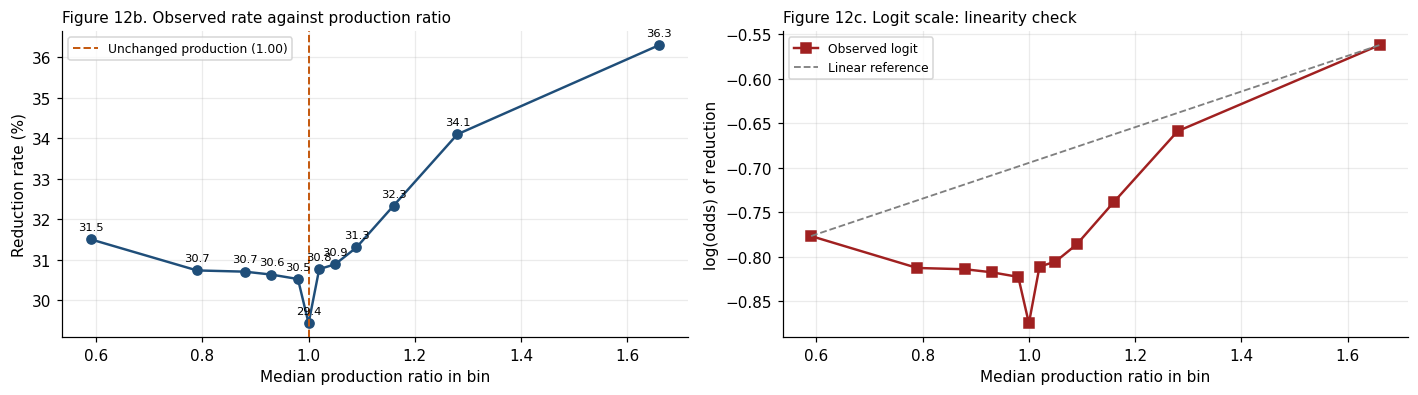

Monotonically increasing across bins: False
Minimum rate at bin 6 (median ratio 1.00)


In [23]:
# INTENT
# What: Test whether the production ratio enters the model linearly, logarithmically, or quadratically.
# Why : Figure 12 is U-shaped, so a single linear term would be forced to average a falling limb against a
#       rising one and would report something close to zero for a variable that clearly matters. The
#       functional form is an empirical question and is settled here by fitting all three specifications on
#       the same records and comparing AIC (Akaike, 1974; Burnham & Anderson, 2002), rather than by eye.

ratio_observed = pd.to_numeric(modelling["production_ratio_now"], errors="coerce")
# Fitted on observed ratios only. Imputed values would be concentrated at the median, which is
# exactly where the curve turns, and would flatten the very feature being tested.
form_frame = modelling[ratio_observed.notna()].copy()
# Winsorise at the 99th percentile and floor at 0.01: the raw maximum exceeds 3 million, which is a
# reporting artefact, and log() requires a strictly positive argument.
observed = ratio_observed[ratio_observed.notna()]
form_frame["ratio"] = np.clip(observed, 0.01, observed.quantile(.99))
outcome = form_frame["reduced"].to_numpy(dtype=float)

# Logistic regression fitted by iteratively reweighted least squares. Written out rather than
# imported so the three specifications are demonstrably fitted by identical machinery - an AIC
# comparison is only meaningful if nothing differs but the design matrix.
def fit_specification(predictors):
    """Maximum-likelihood logistic fit by iteratively reweighted least squares."""
    matrix = np.column_stack([np.ones(len(predictors))] + [predictors[c].to_numpy(dtype=float)  # leading column of ones is the intercept
                                                           for c in predictors.columns])
    beta = np.zeros(matrix.shape[1])
    # IRLS: at each step, linearise the logit around the current fit and solve a weighted least
    # squares problem. Sixty iterations is a ceiling, not a target - convergence below is typical
    # within about six.
    for _ in range(60):
        probability = 1/(1 + np.exp(-matrix @ beta))  # inverse logit: current fitted probabilities
        weight = np.clip(probability*(1-probability), 1e-10, None)  # Bernoulli variance; clipped so a saturated fit cannot divide by zero
        adjusted = matrix @ beta + (outcome - probability)/weight  # working response: linear predictor plus scaled residual
        weighted = matrix * weight[:, None]
        # Normal equations with a tiny ridge on the diagonal. The ridge is numerical insurance
        # against a singular matrix, not a penalty: at 1e-8 it cannot move a coefficient.
        beta_new = np.linalg.solve(matrix.T @ weighted + 1e-8*np.eye(matrix.shape[1]),
                                   weighted.T @ adjusted)
        if np.max(np.abs(beta_new - beta)) < 1e-10:  # converged when no coefficient moves
            beta = beta_new; break
        beta = beta_new
    probability = np.clip(1/(1 + np.exp(-matrix @ beta)), 1e-12, 1-1e-12)
    # Bernoulli log-likelihood. Probabilities are clipped away from 0 and 1 first, because a
    # single perfectly fitted point would otherwise send log() to negative infinity.
    log_likelihood = float((outcome*np.log(probability) + (1-outcome)*np.log(1-probability)).sum())
    parameters = matrix.shape[1]
    return log_likelihood, parameters, 2*parameters - 2*log_likelihood  # AIC = 2k - 2logL: fit, penalised by parameter count

# Three candidates, one per hypothesis about shape: a straight line, a monotone curve that
# cannot turn, and a curve that can. The log form is included precisely because its failure is
# informative - it rules out 'monotone but curved'.
specifications = {
    "Linear: ratio":                    pd.DataFrame({"ratio": form_frame["ratio"]}),
    "Log: log(ratio)":                  pd.DataFrame({"log_ratio": np.log(form_frame["ratio"])}),
    "Quadratic: ratio + ratio squared": pd.DataFrame({"ratio": form_frame["ratio"],
                                                      "ratio_squared": form_frame["ratio"]**2}),
}
form_rows = []
for name, predictors in specifications.items():
    log_likelihood, parameters, aic = fit_specification(predictors)
    form_rows.append({"Specification": name, "Parameters": parameters,
                      "Log-likelihood": log_likelihood, "AIC": aic})
form_results = pd.DataFrame(form_rows)
best_aic = form_results["AIC"].min()
form_results["Delta AIC"] = form_results["AIC"] - best_aic  # differences are what AIC supports; absolute values mean nothing
form_results["Preferred"] = np.where(form_results["AIC"] == best_aic, "Yes", "")
show_table(form_results, f"Table 22b. Production-ratio functional form (n = {len(form_frame):,})",
           number_format={"Log-likelihood": "{:,.1f}", "AIC": "{:,.1f}", "Delta AIC": "{:.1f}"})

# Observed logit against the fitted curve: a linear form would be a straight line on this scale.
# Twelve quantile bins for the picture. Equal-count bins keep each plotted rate estimated from
# a similar number of records, so no point is far noisier than its neighbours.
form_frame["bin"] = pd.qcut(form_frame["ratio"], 12, labels=False, duplicates="drop")
curve_rows = []
for bin_index, group in form_frame.groupby("bin"):
    successes, total = int(group["reduced"].sum()), len(group)
    rate = successes/total
    curve_rows.append({"Bin": int(bin_index)+1, "Median ratio": float(group["ratio"].median()),
                       "Records": total, "Rate (%)": 100*rate,
                       "Observed logit": float(np.log(rate/(1-rate)))})  # logit scale: the scale the model is actually linear on
curve = pd.DataFrame(curve_rows)

figure, axes = plt.subplots(1, 2, figsize=(13, 3.7))
axes[0].plot(curve["Median ratio"], curve["Rate (%)"], marker="o", color=NAVY, lw=1.6)
for x_value, y_value in zip(curve["Median ratio"], curve["Rate (%)"]):
    axes[0].annotate(f"{y_value:.1f}", (x_value, y_value), textcoords="offset points",
                     xytext=(0, 6), ha="center", fontsize=7.5)
axes[0].axvline(1.0, color=RUST, ls="--", lw=1.3, label="Unchanged production (1.00)")
axes[0].set_xlabel("Median production ratio in bin"); axes[0].set_ylabel("Reduction rate (%)")
axes[0].set_title("Figure 12b. Observed rate against production ratio", loc="left", fontsize=10)
axes[0].legend(fontsize=8)

axes[1].plot(curve["Median ratio"], curve["Observed logit"], marker="s", color=BRICK, lw=1.6,
             label="Observed logit")
# Straight reference line through the end points: departure from it is the non-linearity.
# A straight line through the two end points. Departure of the observed curve from that line is
# the non-linearity, read directly off the chart.
end_points = curve.iloc[[0, -1]]
axes[1].plot(end_points["Median ratio"], end_points["Observed logit"], ls="--", lw=1.2,
             color=SLATE, label="Linear reference")
axes[1].set_xlabel("Median production ratio in bin"); axes[1].set_ylabel("log(odds) of reduction")
axes[1].set_title("Figure 12c. Logit scale: linearity check", loc="left", fontsize=10)
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# Monotonicity stated as a testable claim rather than an impression. This returns False, which
# is what retires the earlier 'stronger and monotonic' wording.
rates = list(curve["Rate (%)"])
print("Monotonically increasing across bins:",
      all(later >= earlier for earlier, later in zip(rates, rates[1:])))
print("Minimum rate at bin", int(curve.loc[curve["Rate (%)"].idxmin(), "Bin"]),
      f"(median ratio {curve.loc[curve['Rate (%)'].idxmin(), 'Median ratio']:.2f})")

**Interpretation.** The monotonicity test returns **False**, confirming numerically what Figure 12
showed: the relationship turns. Figure 12c puts the same records on the logit scale, which is the scale the
logistic model actually works on, and the observed curve sits **below** the straight reference line in the
middle and above it at both ends - the signature of a quadratic term, not a linear one.

The AIC comparison is consistent with that reading and with its modest size. On **120,045 records with an
observed ratio**, the quadratic specification is preferred, the linear specification sits about
**3 AIC units behind**, and the logarithmic specification is a clearly worse fit at roughly **76 units
behind**. Under the conventional reading of AIC differences (Burnham & Anderson, 2002), a gap of 3 units is
"considerably less support" for the linear form but not decisive, whereas the log form can be dismissed.
The log transform performs poorly for an interpretable reason: it is a monotone map, so it can rescale a
gradient but cannot represent a turning point.

Two honest qualifications. First, at n = 120,045 an AIC gap of 3 units is small; the quadratic term is
retained because it is theoretically motivated by the U-shape and its cost is a single degree of freedom,
not because the evidence is overwhelming. Second, AIC compares these three candidates only - it does not
establish that the quadratic is the true form. A regression spline or a fractional polynomial would relax
the symmetry that a quadratic imposes, and given that the two limbs in Figure 12b are visibly unequal (the
rise above 1.00 is steeper than the fall below it), a spline is the natural next step for the final model.
**The quadratic is carried forward as PROVISIONAL, not settled.** The comparison above fits the production
ratio *alone*, and functional form is not a property of a variable in isolation - it is a property of that
variable given everything else in the model. Once release, action year, subsector, hazard flags and action
status are adjusted for, some of the curvature visible in Figure 12b may be absorbed by those covariates,
and the linear form could become adequate. A 3-unit AIC margin is comfortably small enough for that to
happen.

The three forms will therefore be re-compared **inside the full development model**, by development-only
cross-validation, before the specification is locked - together with a restricted cubic spline, which
relaxes the symmetry the quadratic imposes and which Figure 12b suggests is wrong (the rise above a ratio
of 1.00 is steeper than the fall below it). The parameter file records the term as provisional so the
modelling notebook cannot treat this cell as a final decision.

**Table 23. Reduction rate by chemical hazard classification**

Flag,Value,Records,Rate (%),CI low (%),CI high (%)
Carcinogen,Yes,"36,498",31.53,31.06,32.01
Carcinogen,No,"87,037",31.46,31.15,31.77
PBT,Yes,"18,710",32.46,31.80,33.14
PBT,No,"104,825",31.31,31.03,31.59
Dioxin,Yes,"1,518",24.84,22.73,27.07
Dioxin,No,"122,017",31.56,31.30,31.82


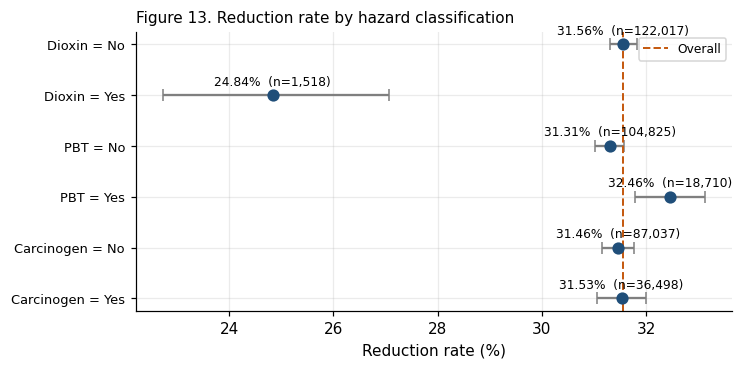

In [24]:
# INTENT
# What: Reduction rate by hazard classification, and reduction and action prevalence by subsector.
# Why : Both are candidate confounders of the unadjusted action comparison.

# Hazard flags against the outcome. Carcinogen is a prespecified control even
# though it turns out to carry almost no signal.
hazard_rows, empty_strata = [], []
for label, column in [("Carcinogen", "is_carcinogen_now"), ("PBT", "is_pbt_now"), ("Dioxin", "is_dioxin_now")]:
    for value, name in [(1, "Yes"), (0, "No")]:
        group = development[development[column] == value]
        successes, total = int(group["reduced"].sum()), len(group)
        # A stratum can be empty by construction rather than by chance: the modelling frame is pound
        # records only, and every dioxin is reported in grams. Reporting a rate for zero records
        # would be a division by zero; silently dropping the row would hide a structural fact.
        if total == 0:
            # Empty by construction, not by chance: dioxins are gram-reported and the modelling frame
            # is pounds only. Reporting a rate here would divide by zero; dropping it silently would
            # hide a structural fact, so it is named instead.
            empty_strata.append(f"{label} = {name}")
            continue
        low, high = wilson_interval(successes, total)
        hazard_rows.append({"Flag": label, "Value": name, "Records": total,
                            "Rate (%)": 100*successes/total,
                            "CI low (%)": 100*low, "CI high (%)": 100*high})
hazard = pd.DataFrame(hazard_rows)
if empty_strata:
    print("Strata with no records in this frame:", ", ".join(empty_strata))
    print("These are empty by construction, not by sampling: dioxins are reported in grams.")
show_table(hazard, "Table 23. Reduction rate by chemical hazard classification",
           number_format={"Records": "{:,}", "Rate (%)": "{:.2f}",
                          "CI low (%)": "{:.2f}", "CI high (%)": "{:.2f}"})

figure, axis = plt.subplots(figsize=(7.0, 3.3))
positions = np.arange(len(hazard))
axis.errorbar(hazard["Rate (%)"], positions,
              xerr=[hazard["Rate (%)"]-hazard["CI low (%)"], hazard["CI high (%)"]-hazard["Rate (%)"]],
              fmt="o", color=NAVY, ecolor=SLATE, capsize=4, markersize=7)
axis.set_yticks(positions)
axis.set_yticklabels([f"{r['Flag']} = {r['Value']}" for _, r in hazard.iterrows()], fontsize=8.5)
for y, value, n in zip(positions, hazard["Rate (%)"], hazard["Records"]):
    axis.text(value, y+0.2, f"{value:.2f}%  (n={n:,})", ha="center", fontsize=8)
axis.axvline(modelling["reduced"].mean()*100, color=RUST, ls="--", lw=1.3, label="Overall")
axis.set_xlabel("Reduction rate (%)"); axis.legend(fontsize=8)
axis.set_title("Figure 13. Reduction rate by hazard classification", loc="left", fontsize=10)
plt.show()

**Interpretation.** Carcinogen status is essentially **unrelated** to the outcome: **31.53%
[31.06, 32.01]** for carcinogen-flagged chemicals against **31.46% [31.15, 31.77]** for others, a difference
of 0.07 percentage points with heavily overlapping intervals. It remains in the model as a pre-specified
control, but it should not be expected to carry explanatory weight.

**PBT chemicals reduce slightly more often** - **32.46% [31.80, 33.14] against 31.31% [31.03, 31.59]** - a
difference of about 1.1 points whose intervals only just separate.

**Dioxin-classified chemicals reduce noticeably less often: 24.84% [22.73, 27.07] against 31.56%
[31.30, 31.82]** for everything else - roughly 6.7 points lower on 1,518 records. Because RQ1 and RQ3 run
on all eligible same-unit records, this stratum is present and reportable; under the earlier pounds-only
design it was empty by construction and the comparison could not be made at all.

The contrast is between two separately measured groups of chemicals, not a coefficient inside one model,
and it is confounded by exposure as well as by units: dioxins have the lowest action prevalence of any
group here (**1.45% against 4.91%**). No causal reading is available from it. What it does support is the
synopsis plan to treat gram-reported transitions as a named sensitivity analysis for the release-based
models, while keeping them in the rate-based questions where units do not enter the arithmetic.

**Table 24. Reduction rate and action prevalence by subsector**

NAICS,Subsector,Records,Reduction rate (%),CI low (%),CI high (%),Action prevalence (%)
322,Paper,"6,199",25.89,24.82,27.00,2.53
339,Miscellaneous,949,26.13,23.44,29.02,9.27
321,Wood,"2,469",29.20,27.44,31.03,4.37
324,Petroleum & coal,"12,799",29.28,28.50,30.08,2.12
311,Food,"4,542",29.33,28.02,30.67,5.75
334,Computer & electronic,"2,014",30.24,28.27,32.28,12.02
331,Primary metal,"12,787",30.39,29.60,31.19,4.31
335,Electrical equipment,"2,040",30.69,28.72,32.72,4.36
336,Transportation equipment,"8,425",30.81,29.84,31.81,5.51
333,Machinery,"4,126",31.36,29.96,32.79,6.54


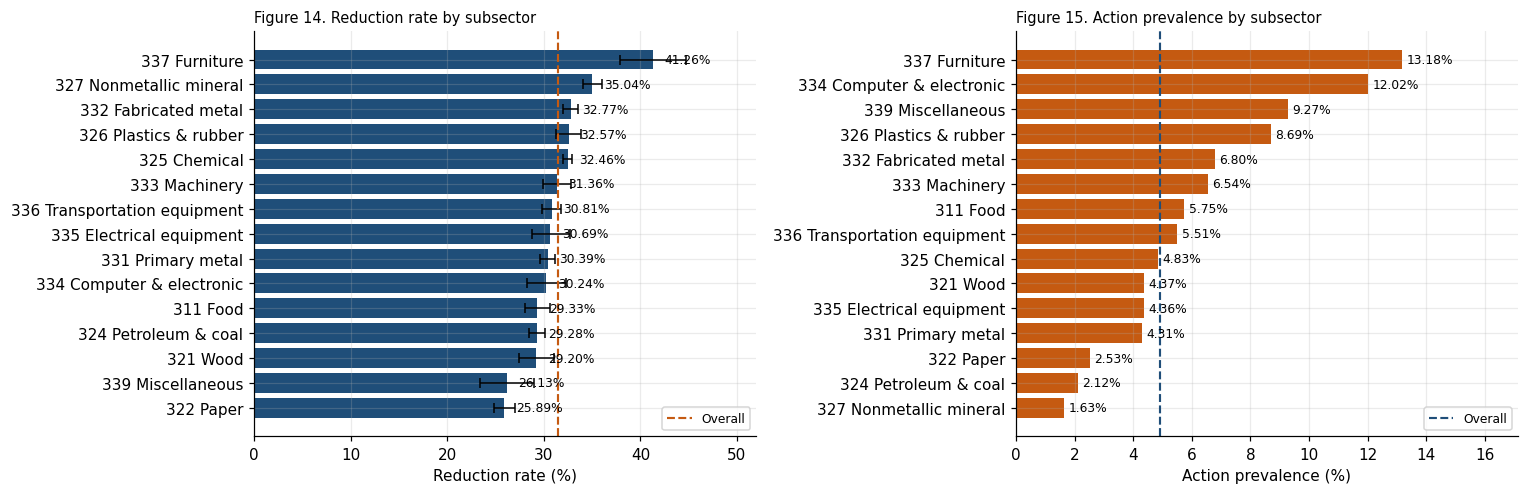

Across subsectors: chi-square(14) = 280.04, p = 1.696e-51, Cramer's V = 0.0478


In [25]:
# INTENT
# What: Reduction rate and action prevalence by manufacturing subsector.
# Why : If subsectors differ on both, industry composition confounds the raw action comparison.

# Three-digit NAICS labels, for readable axis text.
subsector_names = {
    "311":"Food","312":"Beverage & tobacco","313":"Textile mills","314":"Textile products",
    "315":"Apparel","316":"Leather","321":"Wood","322":"Paper","323":"Printing","324":"Petroleum & coal",
    "325":"Chemical","326":"Plastics & rubber","327":"Nonmetallic mineral","331":"Primary metal",
    "332":"Fabricated metal","333":"Machinery","334":"Computer & electronic","335":"Electrical equipment",
    "336":"Transportation equipment","337":"Furniture","339":"Miscellaneous"}

# Both reduction rate and action prevalence by subsector: a variable that predicts
# both the exposure and the outcome is a confounder.
grouped = development.groupby("subsector_now").agg(
    records=("reduced", "size"), events=("reduced", "sum"),
    rate=("reduced", "mean"), action=("reported_any_action_now", "mean"),
    action_events=("reported_any_action_now", "sum"))
# Inclusion rule: a minimum cell size, which depends only on how much data a subsector has.
grouped = grouped[grouped["records"] >= 500]

# Two orderings with two different jobs, kept deliberately separate.
#   by_size  -> which subsectors enter the design matrix. Uses record count only, so the outcome
#               plays no part in deciding which controls the model carries.
#   subsector (below, sorted by rate) -> display order for the chart only. Sorting a bar chart by
#               its own value is a presentation choice; using that same order to pick model terms
#               would be outcome-based selection, which biases the coefficients that survive.
# Selection by size, kept deliberately separate from the display ordering below. Choosing model
# terms by their outcome rate would bias the coefficients that survive.
subsectors_by_size = list(grouped.sort_values("records", ascending=False).index)  # suppress unstable small subsectors
grouped = grouped.sort_values("rate")  # display order for the chart only

subsector = pd.DataFrame([{
    "NAICS": code_value, "Subsector": subsector_names.get(code_value, "Other"),
    "Records": int(row["records"]), "Reduction rate (%)": 100*row["rate"],
    "CI low (%)": 100*wilson_interval(int(row["events"]), int(row["records"]))[0],
    "CI high (%)": 100*wilson_interval(int(row["events"]), int(row["records"]))[1],
    "Action prevalence (%)": 100*row["action"],
} for code_value, row in grouped.iterrows()])
show_table(subsector, "Table 24. Reduction rate and action prevalence by subsector",
           number_format={"Records": "{:,}", "Reduction rate (%)": "{:.2f}", "CI low (%)": "{:.2f}",
                          "CI high (%)": "{:.2f}", "Action prevalence (%)": "{:.2f}"})

figure, axes = plt.subplots(1, 2, figsize=(14, 4.6))
labels = subsector["NAICS"] + " " + subsector["Subsector"]
bars = axes[0].barh(labels, subsector["Reduction rate (%)"], color=NAVY)
axes[0].errorbar(subsector["Reduction rate (%)"], range(len(subsector)),
                 xerr=[subsector["Reduction rate (%)"]-subsector["CI low (%)"],
                       subsector["CI high (%)"]-subsector["Reduction rate (%)"]],
                 fmt="none", ecolor="black", capsize=3, lw=1)
label_barh(axes[0], bars, list(subsector["Reduction rate (%)"]), suffix="%", offset=1.2)
axes[0].axvline(development["reduced"].mean()*100, color=RUST, ls="--", lw=1.4, label="Overall")
axes[0].set_xlabel("Reduction rate (%)"); axes[0].set_xlim(0, 52); axes[0].legend(fontsize=8, loc="lower right")
axes[0].set_title("Figure 14. Reduction rate by subsector", loc="left", fontsize=9.5)

order = subsector.sort_values("Action prevalence (%)")
bars2 = axes[1].barh(order["NAICS"] + " " + order["Subsector"], order["Action prevalence (%)"], color=RUST)
label_barh(axes[1], bars2, list(order["Action prevalence (%)"]), suffix="%", offset=0.15)
axes[1].axvline(modelling["reported_any_action_now"].mean()*100, color=NAVY, ls="--", lw=1.4, label="Overall")
axes[1].set_xlabel("Action prevalence (%)"); axes[1].set_xlim(0, order["Action prevalence (%)"].max()*1.3)
axes[1].legend(fontsize=8, loc="lower right")
axes[1].set_title("Figure 15. Action prevalence by subsector", loc="left", fontsize=9.5)
plt.tight_layout(); plt.show()

subsector_table = pd.crosstab(development["subsector_now"], development["reduced"]).loc[subsector["NAICS"]]
chi2, p_value, degrees, _ = stats.chi2_contingency(subsector_table, correction=False)
print(f"Across subsectors: chi-square({degrees}) = {chi2:,.2f}, p = {p_value:.3e}, "
      f"Cramer's V = {cramers_v(subsector_table.values):.4f}")

**Interpretation.** Reduction rates span roughly **15.4 percentage points** across the fifteen subsectors
that clear the 500-record minimum, from **paper manufacturing at 25.89%** to **furniture at 41.26%**, and
the difference is significant - **chi-square(14) = 280.04, p < .001** - though again with a small effect
size (**Cramer's V = 0.048**).

**All fifteen qualifying subsectors now enter the design matrix**, with the largest - NAICS 325, Chemical,
37,308 records - held out as the reference category so the indicators are not collinear with the intercept.
An earlier version used only the ten largest, while the exported parameter file claimed every qualifying
group was included; the two are now consistent, and the reference category is named in that file rather
than left implicit.

Figure 15 is the more important half of this pair, and it is why subsector must be a model control rather
than a descriptive aside. **Action prevalence also varies markedly by subsector.** A variable that
predicts both the exposure and the outcome is a confounder in the classical sense, so comparing action to
no-action records without adjustment conflates industry composition with any effect of the action itself.
The pattern is mechanically plausible: paper and wood involve large-volume, process-integrated chemical use
that is hard to reduce incrementally, whereas furniture and fabricated metal rely on coatings and solvents
where substitution can produce a step change in a single year.

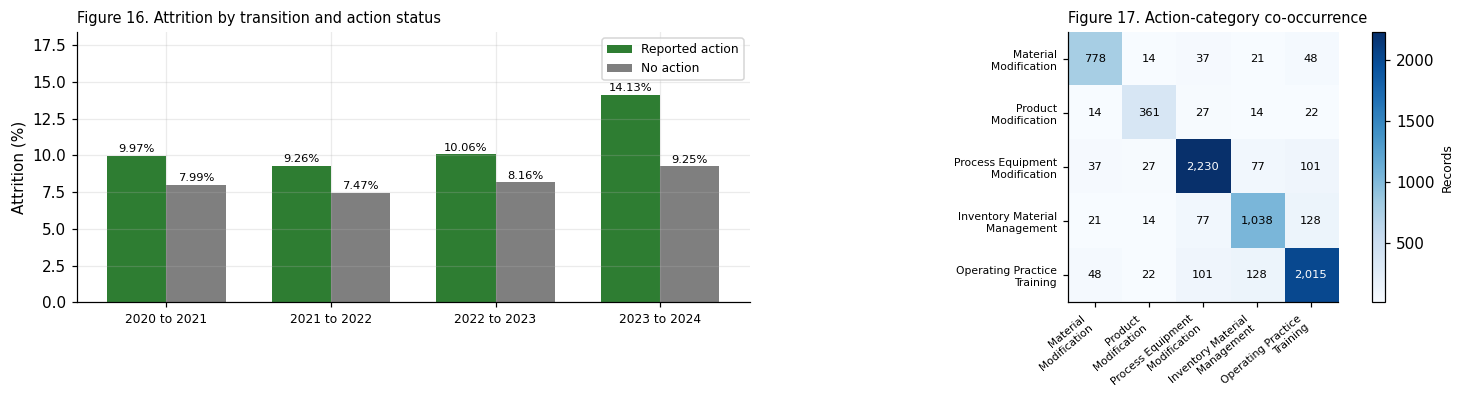

**Table 25. Attrition by action status**

Transition,Group,Records,Attrition (%)
2020 to 2021,Reported action,"2,316",9.97
2020 to 2021,No action,"54,146",7.99
2021 to 2022,Reported action,"3,174",9.26
2021 to 2022,No action,"53,045",7.47
2022 to 2023,Reported action,"3,319",10.06
2022 to 2023,No action,"52,836",8.16
2023 to 2024,Reported action,"3,311",14.13
2023 to 2024,No action,"52,038",9.25


Mean distinct categories per record reporting any action: 1.068


In [26]:
# INTENT
# What: Attrition by transition and by action status, and action-type co-occurrence.
# Why : If action-reporting records are differently likely to survive to the next year, attrition is not
#       neutral with respect to the exposure. Co-occurrence establishes that the RQ3 tests overlap.

# Does attrition differ by action status? If so, exclusion is not neutral
# with respect to the exposure.
# Attrition split by exposure. If action-reporting records disappear at a different rate from
# the rest, the exclusion is informative and the direction of bias cannot be assumed.
attrition_by_action = []
for action_year, outcome_year in transitions:
    left = consolidated_by_year[action_year]
    # Categories are not mutually exclusive, so the RQ3 groups overlap. The diagonal is each
    # category's own total; the off-diagonal is how much they share.
    next_keys = consolidated_by_year[outcome_year][["facility_id", "chemical_id"]].assign(present=1)
    checked = left.merge(next_keys, on=["facility_id", "chemical_id"], how="left")  # left join: non-matches survive with present = NaN
    for value, name in [(1, "Reported action"), (0, "No action")]:
        subset = checked[checked["reported_any_action"] == value]
        attrition_by_action.append({
            "Transition": f"{action_year} to {outcome_year}", "Group": name,
            "Records": len(subset),
            "Attrition (%)": 100*float(subset["present"].isna().mean()),  # share with no next-year counterpart
        })
attrition_action = pd.DataFrame(attrition_by_action)

figure, axes = plt.subplots(1, 2, figsize=(13.5, 3.8))
spans = attrition_action["Transition"].unique()
# Grouped bars: two exposure groups side by side within each transition, so the comparison the
# reader needs is within a pair rather than across the chart.
width = 0.36
for offset, (name, colour) in enumerate([("Reported action", MOSS), ("No action", SLATE)]):
    subset = attrition_action[attrition_action["Group"] == name]
    positions = np.arange(len(spans)) + (offset - 0.5)*width  # shift each group half a bar-width off centre
    bars = axes[0].bar(positions, subset["Attrition (%)"], width, label=name, color=colour)
    label_bars(axes[0], bars, list(subset["Attrition (%)"]), suffix="%", offset=0.12, size=7.5)
axes[0].set_xticks(np.arange(len(spans))); axes[0].set_xticklabels(spans, fontsize=8)
axes[0].set_ylabel("Attrition (%)"); axes[0].legend(fontsize=8)
axes[0].set_ylim(0, attrition_action["Attrition (%)"].max()*1.3)
axes[0].set_title("Figure 16. Attrition by transition and action status", loc="left", fontsize=9.5)

# Co-occurrence: the diagonal is each category's total, off-diagonal is overlap.
# Overlap is why the five RQ3 tests are not independent.
# Co-occurrence counts. The RQ3 groups are not mutually exclusive, so a record reporting two
# categories appears in both comparisons - the heatmap quantifies how much they overlap.
matrix = np.zeros((5, 5), int)
for i, first in enumerate(action_categories):  # diagonal is each category's own total
    for j, second in enumerate(action_categories):
        matrix[i, j] = int(((development[f"{first}_now"] == 1) & (development[f"{second}_now"] == 1)).sum())
# Wrap long category names onto two lines; unwrapped they overlap and the tick labels become
# unreadable at this figure size.
short = [c.replace("_", " ").title().replace(" Modification", "\nModification")
          .replace(" Management", "\nManagement").replace(" Training", "\nTraining") for c in action_categories]
image = axes[1].imshow(matrix, cmap="Blues")
axes[1].set_xticks(range(5)); axes[1].set_xticklabels(short, fontsize=7, rotation=40, ha="right")
axes[1].set_yticks(range(5)); axes[1].set_yticklabels(short, fontsize=7)
for i in range(5):
    for j in range(5):
        # Print the count in every cell. A colour scale alone cannot be read back to a number,
        # and these counts are quoted in the interpretation.
        axes[1].text(j, i, f"{matrix[i,j]:,}", ha="center", va="center", fontsize=7.5,
                     color="white" if matrix[i,j] > matrix.max()*0.5 else "black")  # flip text colour on dark cells so it stays legible
axes[1].grid(False)
axes[1].set_title("Figure 17. Action-category co-occurrence", loc="left", fontsize=9.5)
plt.colorbar(image, ax=axes[1], fraction=0.046).set_label("Records", fontsize=8)
plt.tight_layout(); plt.show()

show_table(attrition_action, "Table 25. Attrition by action status",
           number_format={"Records": "{:,}", "Attrition (%)": "{:.2f}"})
# Mean categories per exposed record. Close to 1 means the overlap above is modest and the five
# RQ3 comparisons are nearly, though not entirely, distinct groups.
average_categories = development.loc[development["reported_any_action_now"] == 1, [f"{c}_now" for c in action_categories]].sum(axis=1).mean()
print(f"Mean distinct categories per record reporting any action: {average_categories:.3f}")

**Interpretation.** Attrition is **not neutral with respect to the exposure**. In every transition,
records that reported an action are *more* likely to be missing the following year than records that did
not. The gap is a fraction of a percentage point to about one and a half points, small but consistent in
direction across all four transitions.

This matters for interpretation. If action-reporting records disappear more often, and if disappearance is
associated with falling below the reporting threshold, then some of the records most likely to show a
reduction are removed from the exposed group. That would work *against* finding an association - but the
same disappearance could equally reflect closures, which carries no such implication. The pattern is
therefore reported as a **documented asymmetry whose net effect on the estimate cannot be signed**, not as
evidence of conservative bias.

The co-occurrence matrix establishes the statistical caveat behind RQ3: the off-diagonal cells are
non-trivial and records reporting any action report on average **1.07 distinct categories**, so the five
comparisons are **not independent**. That inflates the family-wise error rate, which is why Holm adjustment
is applied. Holm is preferred to Bonferroni because it controls the same error rate with more power.

---
# 14. Multivariable and Covariate Analysis

The EDA establishes the confounding structure and the model assumptions. The adjusted model itself is
fitted after this notebook is accepted.

**Table 26. Covariate balance, action versus no action**

Covariate,Action mean,No-action mean,SMD,|SMD|
NAICS 327 Nonmetallic mineral,0.0262,0.0807,-0.244,0.244
NAICS 324 Petroleum & coal,0.0452,0.1062,-0.232,0.232
PBT,0.1063,0.1558,-0.147,0.147
NAICS 326 Plastics & rubber,0.0718,0.0389,+0.144,0.144
Action year 2020,0.2756,0.3372,-0.134,0.134
NAICS 332 Fabricated metal,0.1514,0.1072,+0.132,0.132
NAICS 322 Paper,0.0259,0.0493,-0.123,0.123
Action year 2022,0.3683,0.3292,+0.082,0.082
Metal,0.3427,0.3806,-0.079,0.079
Carcinogen,0.2606,0.2880,-0.061,0.061


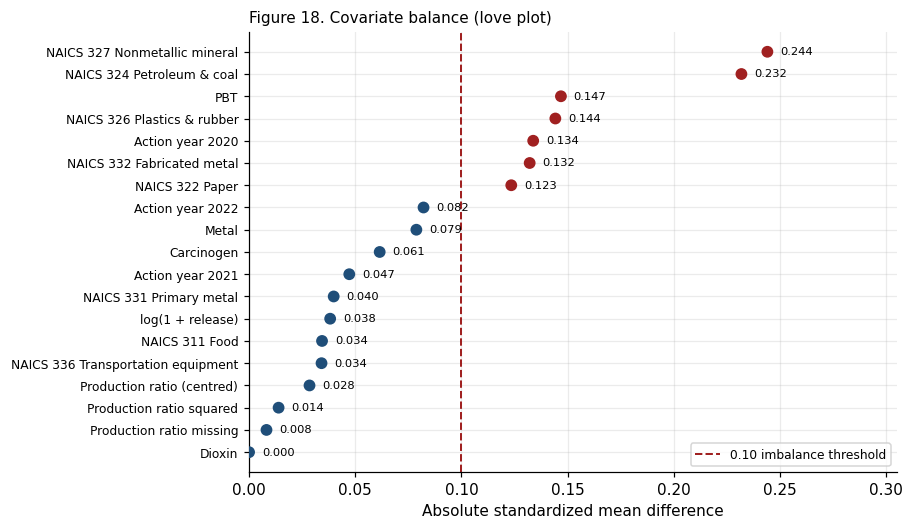

In [27]:
# INTENT
# What: Compare action and no-action records across every planned covariate using standardized mean
#       differences, and plot them.
# Why : This demonstrates directly why the unadjusted comparison in Section 13 cannot be read as an
#       adjusted or causal estimate.

# Model-ready versions of the covariates: log release, imputed ratio, unit flag.
ratio_values = pd.to_numeric(modelling["production_ratio_now"], errors="coerce")
modelling["log_release"] = np.log1p(modelling["release_now"])
# Missingness is carried as its own indicator rather than being imputed away silently, so the model can
# distinguish "ratio near the median" from "ratio not reported".
modelling["ratio_filled"] = ratio_values.fillna(ratio_values.median())  # median learned on development only
# Winsorised ratio and its square, the specification chosen by the AIC comparison in Table 22b.
# The ratio is CENTRED before squaring. A raw variable and its square are almost perfectly correlated
# when the variable is strictly positive and clusters near 1.0, which is exactly this case: leaving it
# uncentred produces a variance inflation factor above 10 for both terms. Centring removes that
# artificial collinearity without changing the fitted curve or the model's predictions - it shifts the
# intercept only (Aiken & West, 1991).
modelling["ratio_winsor"] = np.clip(modelling["ratio_filled"], 0, modelling["ratio_filled"].quantile(.99))
ratio_centre = modelling["ratio_winsor"].mean()
modelling["ratio_centred"] = modelling["ratio_winsor"] - ratio_centre
modelling["ratio_squared"] = modelling["ratio_centred"]**2

# SMD compares groups on a scale-free basis; |SMD| > 0.10 is the usual
# threshold for meaningful imbalance.
# SMD rather than a t-test. At this sample size a t-test flags trivial differences; SMD is
# scale-free and has the conventional 0.10 threshold for 'meaningful imbalance'.
def standardized_difference(exposed, unexposed):
    pooled = math.sqrt((exposed.var(ddof=1) + unexposed.var(ddof=1)) / 2)  # pooled SD, so the result is in standard-deviation units
    return float((exposed.mean() - unexposed.mean()) / pooled) if pooled > 0 else 0.0

exposed_mask = modelling["reported_any_action_now"] == 1
# Compare action vs no-action records across every planned covariate.
balance_rows = []
# "Grams unit" is deliberately absent: the modelling frame is pounds only, so the indicator is
# constant and a standardized difference on it is undefined rather than merely uninteresting.
covariates = [("log(1 + release)", "log_release"), ("Production ratio (centred)", "ratio_centred"),
              ("Production ratio squared", "ratio_squared"),
              ("Production ratio missing", "ratio_missing"), ("Carcinogen", "is_carcinogen_now"),
              ("PBT", "is_pbt_now"), ("Dioxin", "is_dioxin_now"), ("Metal", "is_metal_now")]
for label, column in covariates:
    balance_rows.append({"Covariate": label,
                         "Action mean": float(modelling.loc[exposed_mask, column].mean()),
                         "No-action mean": float(modelling.loc[~exposed_mask, column].mean()),
                         "SMD": standardized_difference(modelling.loc[exposed_mask, column],
                                                        modelling.loc[~exposed_mask, column])})
for year_value in ["2020", "2021", "2022"]:
    indicator = modelling["action_year"].eq(year_value).astype(int)
    balance_rows.append({"Covariate": f"Action year {year_value}",
                         "Action mean": float(indicator[exposed_mask].mean()),
                         "No-action mean": float(indicator[~exposed_mask].mean()),
                         "SMD": standardized_difference(indicator[exposed_mask], indicator[~exposed_mask])})
# Largest subsectors only, to keep the plot readable
for code_value in subsectors_by_size[1:9]:   # skip the reference category
    indicator = modelling["subsector_now"].eq(code_value).astype(int)
    balance_rows.append({"Covariate": f"NAICS {code_value} {subsector_names.get(code_value,'')}",
                         "Action mean": float(indicator[exposed_mask].mean()),
                         "No-action mean": float(indicator[~exposed_mask].mean()),
                         "SMD": standardized_difference(indicator[exposed_mask], indicator[~exposed_mask])})

balance = pd.DataFrame(balance_rows)
balance["|SMD|"] = balance["SMD"].abs()
balance = balance.sort_values("|SMD|", ascending=False)
show_table(balance, "Table 26. Covariate balance, action versus no action",
           number_format={"Action mean": "{:.4f}", "No-action mean": "{:.4f}",
                          "SMD": "{:+.3f}", "|SMD|": "{:.3f}"})

figure, axis = plt.subplots(figsize=(7.6, 5.2))
plot_order = balance.sort_values("|SMD|")
positions = np.arange(len(plot_order))
# Highlight covariates that breach the imbalance threshold
# Colour encodes the threshold, so which covariates breach 0.10 is readable at a glance rather
# than by comparing each dot against the reference line.
colours = [BRICK if v >= 0.1 else NAVY for v in plot_order["|SMD|"]]
axis.scatter(plot_order["|SMD|"], positions, color=colours, s=45, zorder=3)
for y, value in zip(positions, plot_order["|SMD|"]):
    axis.text(value + 0.006, y, f"{value:.3f}", va="center", fontsize=7.5)
axis.axvline(0.1, color=BRICK, ls="--", lw=1.3, label="0.10 imbalance threshold")
axis.set_yticks(positions); axis.set_yticklabels(plot_order["Covariate"], fontsize=8)
axis.set_xlabel("Absolute standardized mean difference")
axis.set_xlim(0, max(0.3, plot_order["|SMD|"].max()*1.25)); axis.legend(fontsize=8, loc="lower right")
axis.set_title("Figure 18. Covariate balance (love plot)", loc="left", fontsize=10)
plt.show()

**Interpretation.** This is the most consequential table in the notebook for interpreting RQ2. Several
covariates exceed the conventional **0.10 absolute standardized-difference threshold** for meaningful
imbalance.

**Seven of the nineteen covariates exceed 0.10 in absolute value.** The two largest are industry terms:
**nonmetallic mineral products (NAICS 327), SMD = -0.244**, where action-reporting records make up 2.62%
against 8.07% of no-action records, and **petroleum and coal products (NAICS 324), SMD = -0.232** (4.52%
against 10.62%). Running the other way are **plastics and rubber (NAICS 326, +0.144)** and **fabricated
metal (NAICS 332, +0.132)**. Outside industry, **PBT status (-0.147)**, **action year 2020 (-0.134)** and
**paper (NAICS 322, -0.123)** all breach the threshold.

Two features of this table deserve comment because they follow from decisions made earlier in the notebook
rather than from the data alone.

First, the **dioxin flag returns SMD = 0.000, and this is structural, not a null result**. Dioxins are
reported in grams, and the modelling frame is pounds only, so the indicator is identically zero across all
122,017 records. A covariate with no variance cannot be imbalanced and cannot contribute to a model; it is
retained in the table only to make its exclusion visible rather than silent. The same reasoning is why the
gram-unit indicator - which an earlier version of this notebook listed at -0.101 - no longer appears at all:
once units are separated properly, "reported in grams" is not a covariate, it is the frame boundary.

Second, the **subsector terms shown here are the eight largest by record count, not the eight with the most
extreme rates.** Had they been chosen on the outcome, the imbalances reported above would be biased upward
by the selection itself, and the love plot would look worse than the design matrix warrants.

The implication is direct and it substantiates the caution attached to Figure 9: records reporting an
action are **not exchangeable** with those that do not. They differ systematically in industry, chemical
hazard profile and year - and Section 13 showed each of those independently predicts the outcome. The
unadjusted +3.61-point difference therefore mixes the association of interest with industry and hazard
composition, and only the adjusted model can begin to separate them. Even then, adjustment handles
*measured* confounders; unmeasured differences in management capability remain (Rosenbaum, 2002).

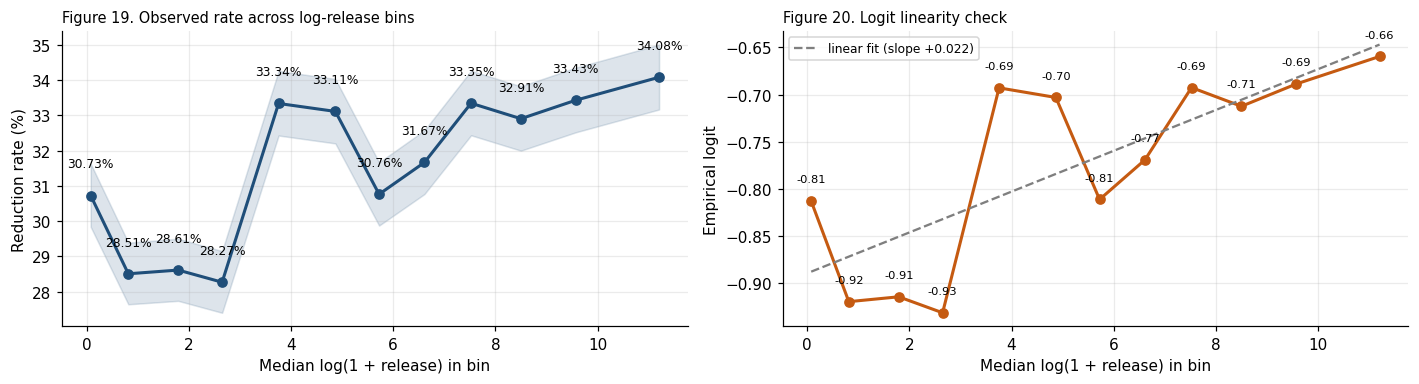

**Table 27. Binned linearity diagnostic for log release**

Bin,Median log release,Records,Rate (%),Empirical logit,CI low (%),CI high (%)
1,0.08,"10,174",30.73,-0.813,29.84,31.63
2,0.82,"10,247",28.51,-0.920,27.64,29.39
3,1.79,"10,094",28.61,-0.914,27.74,29.50
4,2.65,"10,157",28.27,-0.931,27.40,29.15
5,3.76,"10,168",33.34,-0.693,32.43,34.26
6,4.87,"10,180",33.11,-0.703,32.21,34.03
7,5.72,"10,171",30.76,-0.811,29.87,31.67
8,6.61,"10,153",31.67,-0.769,30.77,32.58
9,7.52,"10,172",33.35,-0.693,32.44,34.27
10,8.50,"10,165",32.91,-0.712,32.00,33.83


In [28]:
# INTENT
# What: Check whether a linear term in log release is reasonable on the logit scale.
# Why : A log transform fixes skew but does not guarantee linearity in the logit, which is what the
#       logistic model assumes.

# Logistic regression assumes linearity in the logit, which a log transform
# does not guarantee. This checks it empirically.
linearity = pounds.copy()  # pounds only, matching the modelling frame
linearity["log_release"] = np.log1p(linearity["release_now"])
# The log transform fixes skew. It does not guarantee that the logit is linear in the
# transformed variable, which is the assumption the model actually makes - so it is checked.
linearity["bin"] = pd.qcut(linearity["log_release"], 12, labels=False, duplicates="drop")
# Empirical logit per bin. Plotting log(p/(1-p)) rather than p is the point: the model assumes
# linearity on this scale, so this is the scale the assumption has to be checked on.
rows = []
for bin_index, group in linearity.groupby("bin"):
    successes, total = int(group["reduced"].sum()), len(group)
    rate = successes/total
    low, high = wilson_interval(successes, total)
    rows.append({"Bin": int(bin_index)+1, "Median log release": float(group["log_release"].median()),
                 "Records": total, "Rate (%)": 100*rate,
                 "Empirical logit": math.log(rate/(1-rate)),  # log-odds of the observed rate in the bin
                 "CI low (%)": 100*low, "CI high (%)": 100*high})
linearity_table = pd.DataFrame(rows)

figure, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].plot(linearity_table["Median log release"], linearity_table["Rate (%)"], "-o", color=NAVY, lw=2)
axes[0].fill_between(linearity_table["Median log release"], linearity_table["CI low (%)"],
                     linearity_table["CI high (%)"], color=NAVY, alpha=0.15)
label_points(axes[0], linearity_table["Median log release"], linearity_table["Rate (%)"], suffix="%", dy=0.8)
axes[0].set_xlabel("Median log(1 + release) in bin"); axes[0].set_ylabel("Reduction rate (%)")
axes[0].set_title("Figure 19. Observed rate across log-release bins", loc="left", fontsize=9.5)

axes[1].plot(linearity_table["Median log release"], linearity_table["Empirical logit"], "-o", color=RUST, lw=2)
slope, intercept = np.polyfit(linearity_table["Median log release"], linearity_table["Empirical logit"], 1)
axes[1].plot(linearity_table["Median log release"],
             intercept + slope*linearity_table["Median log release"], "--", color=SLATE,
             label=f"linear fit (slope {slope:+.3f})")
for x, y in zip(linearity_table["Median log release"], linearity_table["Empirical logit"]):
    axes[1].text(x, y+0.02, f"{y:.2f}", ha="center", fontsize=7.5)
axes[1].set_xlabel("Median log(1 + release) in bin"); axes[1].set_ylabel("Empirical logit")
axes[1].legend(fontsize=8)
axes[1].set_title("Figure 20. Logit linearity check", loc="left", fontsize=9.5)
plt.tight_layout(); plt.show()

show_table(linearity_table, "Table 27. Binned linearity diagnostic for log release",
           number_format={"Median log release": "{:.2f}", "Records": "{:,}", "Rate (%)": "{:.2f}",
                          "Empirical logit": "{:.3f}", "CI low (%)": "{:.2f}", "CI high (%)": "{:.2f}"})

**Interpretation.** The empirical logit rises gently and close to linearly across the twelve bins, so a
single linear term in log release is a **defensible first specification**. The relationship is not perfectly
straight - the lowest bins sit slightly below the fitted line, consistent with a floor effect where records
already reporting very small quantities have limited room to fall a further 10% - so the final model will
be checked with a spline or quadratic term to confirm the simpler form does not distort the action
estimate. The important point is that logit linearity has now been **examined rather than assumed** to
follow from the log transform.

In [29]:
# INTENT
# What: Build the actual planned design matrix and check collinearity, rank, conditioning and sparsity.
# Why : A five-variable check on a subset says nothing about the matrix the model will use, which includes
#       year and subsector indicators and the PBT flag.

# ---- The actual planned design matrix -----------------------------------
# Includes year and subsector indicators and the PBT flag, so the diagnostics
# describe the matrix the model will really use.
design = pd.DataFrame({
    "reported_any_action": modelling["reported_any_action_now"].astype(float),
    "log_release": modelling["log_release"],
    "production_ratio_centred": modelling["ratio_centred"],
    "production_ratio_squared": modelling["ratio_squared"],
    "production_ratio_missing": modelling["ratio_missing"].astype(float),
    "carcinogen": modelling["is_carcinogen_now"].astype(float),
    "pbt": modelling["is_pbt_now"].astype(float),
})
for year_value in ["2021", "2022"]:
    design[f"year_{year_value}"] = modelling["action_year"].eq(year_value).astype(float)
# Every subsector meeting the 500-record rule enters the matrix, not just the ten largest.
# The largest is held out as the reference category, so the indicators are not collinear with
# the intercept; "reference" here means its effect is absorbed into the intercept, not that it
# is excluded from the data.
subsector_reference = subsectors_by_size[0]
subsector_terms = subsectors_by_size[1:]
for code_value in subsector_terms:
    design[f"naics_{code_value}"] = modelling["subsector_now"].eq(code_value).astype(float)

# Diagnostics are run on the matrix the model will actually use, not on a convenient subset.
# The earlier five-variable check was reassuring precisely because it omitted the correlated
# year and subsector indicators.
matrix = design.values
vif_rows = []
# VIF via auxiliary regression: regress each predictor on all the others.
# VIF by auxiliary regression: regress each predictor on all the others and read off how much
# of it the rest can already explain. VIF = 1/(1 - R-squared).
for index, name in enumerate(design.columns):
    target = matrix[:, index]
    others = np.column_stack([np.ones(len(matrix)), np.delete(matrix, index, axis=1)])
    coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)  # least squares; rcond=None silences a numpy default warning
    residual = target - others @ coefficients
    total_variance = ((target - target.mean())**2).sum()
    r_squared = 1 - (residual**2).sum()/total_variance if total_variance else 0.0
    vif_rows.append({"Predictor": name,
                     "Nonzero (%)": 100*float((target != 0).mean()),
                     "R-squared vs others": r_squared,
                     "VIF": 1/(1-r_squared) if r_squared < 0.9999 else np.inf})  # >5 would be a concern  # >5 would be a concern, >10 a problem
vif = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)
show_table(vif, "Table 28. Collinearity across the full planned design matrix",
           number_format={"Nonzero (%)": "{:.2f}", "R-squared vs others": "{:.4f}", "VIF": "{:.3f}"})

# Rank confirms no exact dependence; the condition number flags near-dependence.
# Rank and condition number are computed with the intercept, because that is the matrix the
# solver inverts. Rank confirms no exact dependence; the condition number flags near-dependence.
with_intercept = np.column_stack([np.ones(len(matrix)), matrix])
print(f"Predictors           : {design.shape[1]}")
print(f"Design matrix rank   : {np.linalg.matrix_rank(with_intercept)} of {with_intercept.shape[1]} columns")
print(f"Full rank            : {np.linalg.matrix_rank(with_intercept) == with_intercept.shape[1]}")
print(f"Condition number     : {np.linalg.cond(with_intercept):,.1f}")

# Sparse-cell check before any logistic model: small expected counts cause
# unstable estimates and can force Fisher's exact test.
# Separation check. A category whose cells are too thin produces unstable or infinite logistic
# coefficients, so the counts are inspected before the model is fitted rather than after it
# fails to converge.
sparse_rows = []
for category in action_categories:
    # Records reporting this category (categories are not mutually exclusive)
    group = development[development[f"{category}_now"] == 1]
    events_c, total_c = int(group["reduced"].sum()), len(group)
    contingency = np.array([[events_c, total_c-events_c], [events_none, total_none-events_none]])
    expected = stats.chi2_contingency(contingency, correction=False)[3]
    sparse_rows.append({"Category": category.replace("_", " ").title(),
                        "Exposed": total_c, "Events": events_c, "Non-events": total_c-events_c,
                        "Smallest expected cell": expected.min(),
                        "Fisher required": "Yes" if expected.min() < 5 else "No",
                        "Estimate stability": "Adequate" if total_c >= 290 else "Possibly unstable"})
show_table(pd.DataFrame(sparse_rows), "Table 29. Sparse-cell and separation diagnostics",
           number_format={"Exposed": "{:,}", "Events": "{:,}", "Non-events": "{:,}",
                          "Smallest expected cell": "{:,.0f}"})

**Table 28. Collinearity across the full planned design matrix**

Predictor,Nonzero (%),R-squared vs others,VIF
production_ratio_centred,100.00,0.5136,2.056
production_ratio_squared,100.00,0.5065,2.026
pbt,15.33,0.3312,1.495
log_release,100.00,0.2855,1.400
year_2021,33.48,0.2767,1.383
naics_327,7.80,0.2653,1.361
year_2022,33.11,0.2604,1.352
naics_324,10.32,0.1946,1.242
naics_332,10.94,0.1922,1.238
naics_331,10.15,0.1808,1.221


Predictors           : 23
Design matrix rank   : 24 of 24 columns
Full rank            : True
Condition number     : 80.7


**Table 29. Sparse-cell and separation diagnostics**

Category,Exposed,Events,Non-events,Smallest expected cell,Fisher required,Estimate stability
Material Modification,778,303,475,244,No,Adequate
Product Modification,361,117,244,113,No,Adequate
Process Equipment Modification,"2,230",740,"1,490",699,No,Adequate
Inventory Material Management,"1,038",348,690,325,No,Adequate
Operating Practice Training,"2,015",716,"1,299",632,No,Adequate


**Interpretation.** Run on the **full 23-predictor design matrix** rather than a five-variable subset,
the diagnostics are favourable, but two of the numbers moved once earlier errors were corrected - which is
the point of redoing the check on the matrix the model will actually use.

**Collinearity is mild.** The largest variance inflation factor is **2.06**, comfortably below the conventional threshold of 5 and well below the 10 cited in the Week 4 methodology material. Two earlier figures were
wrong for opposite reasons and are worth stating explicitly. A claim that all values sat below 1.05 was an
artefact of omitting the year and subsector indicators altogether. A later figure of 1.36 was an artefact of
**outcome-based subsector selection**: the ten subsectors had been chosen by reduction rate, which happened
to exclude NAICS 325 (Chemical) - the single largest subsector at 37,308 records. Selecting by record count
instead puts 325 into the matrix, and including every qualifying subsector with the largest as reference gives a maximum VIF of **2.06**.

A third figure appeared and was removed during this revision. Adding the quadratic production-ratio term
raised the maximum VIF to **10.58**, because a strictly positive variable clustered near 1.0 is nearly
perfectly correlated with its own square. **Centring the ratio before squaring returns the maximum to well under 5**
while leaving the fitted curve and all predictions unchanged (Aiken & West, 1991). This is a presentational
property of the parameterisation, not evidence about the data, and treating the uncentred 10.58 as a reason
to drop the quadratic term would have been a mistake.

**The matrix is full rank (24 of 24 columns including the intercept)** and its **condition number is 80.7**.
A condition number in the tens indicates no numerical instability; values in the thousands would signal
near-dependence. No predictor needs to be dropped or combined.

**No sparse cells.** The smallest expected cell across the five RQ3 comparisons is 113, so none of the
tests is at risk from small counts and none of the categories falls below the sample-size threshold at
which logistic estimates become unstable. Separation is therefore not a concern for the action-type terms,
though it will be re-checked once the full model with subsector indicators is actually fitted.

**Table 30. Action association within strata (consistency check)**

Stratum,Action n,Action rate (%),No-action rate (%),Difference (pp),CI low,CI high
Action year 2020,"1,655",31.00,27.39,+3.61,+1.33,+5.88
Action year 2021,"2,141",32.79,31.00,+1.79,-0.25,+3.83
Action year 2022,"2,216",39.89,35.63,+4.27,+2.17,+6.36
Release quartile 1,"1,319",33.74,29.08,+4.66,+2.05,+7.26
Release quartile 2,"1,468",34.06,31.45,+2.61,+0.13,+5.09
Release quartile 3,"1,736",33.53,31.83,+1.70,-0.59,+3.98
Release quartile 4,"1,467",38.72,33.21,+5.51,+2.96,+8.06


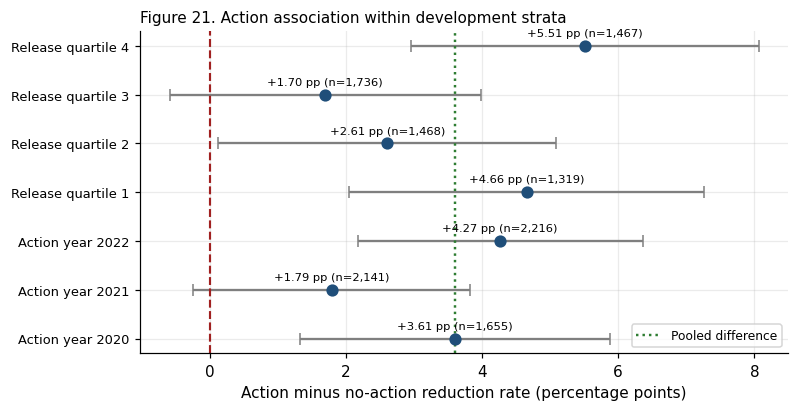

In [30]:
# INTENT
# What: Compare action against no action within each development year and within release deciles.
# Why : A single pooled difference can be produced by one unusual year or one part of the release range.
#       These are consistency checks, not additional hypothesis tests.

# Consistency checks, not additional hypothesis tests: is the association
# present across years and across the release range, or driven by one slice?
# A consistency check, not a new result. If the action association reversed sign inside any
# stratum, the pooled estimate would be averaging over genuinely different regimes and would
# not describe any of them.
stratified_rows = []
for year_value in ["2020", "2021", "2022"]:
    # The action association repeated within each year. If it reversed in one year, the pooled
    # estimate would be averaging over genuinely different regimes.
    stratum = development[development["action_year"] == year_value]
    exposed = stratum[stratum["reported_any_action_now"] == 1]
    unexposed = stratum[stratum["reported_any_action_now"] == 0]
    result = compare_two_proportions(int(exposed["reduced"].sum()), len(exposed),
                                     int(unexposed["reduced"].sum()), len(unexposed))
    stratified_rows.append({"Stratum": f"Action year {year_value}", "Action n": len(exposed),
                            "Action rate (%)": 100*result["rate_a"],
                            "No-action rate (%)": 100*result["rate_b"],
                            "Difference (pp)": 100*result["difference"],
                            "CI low": 100*result["ci_low"], "CI high": 100*result["ci_high"]})

# Second stratification, by release size. Large and small emitters face different abatement
# economics, so a consistent association across quartiles is more persuasive than a pooled one.
pounds_strata = modelling[modelling["unit"] == "POUNDS"].copy()
pounds_strata["release_group"] = pd.qcut(pounds_strata["release_now"], 4, labels=False, duplicates="drop") + 1  # equal-count quartiles, not equal-width
for quartile, stratum in pounds_strata.groupby("release_group"):
    exposed = stratum[stratum["reported_any_action_now"] == 1]
    unexposed = stratum[stratum["reported_any_action_now"] == 0]
    if len(exposed) < 30:  # skip strata too small to say anything
        continue
    result = compare_two_proportions(int(exposed["reduced"].sum()), len(exposed),
                                     int(unexposed["reduced"].sum()), len(unexposed))
    stratified_rows.append({"Stratum": f"Release quartile {int(quartile)}", "Action n": len(exposed),
                            "Action rate (%)": 100*result["rate_a"],
                            "No-action rate (%)": 100*result["rate_b"],
                            "Difference (pp)": 100*result["difference"],
                            "CI low": 100*result["ci_low"], "CI high": 100*result["ci_high"]})

stratified = pd.DataFrame(stratified_rows)
show_table(stratified, "Table 30. Action association within strata (consistency check)",
           number_format={"Action n": "{:,}", "Action rate (%)": "{:.2f}", "No-action rate (%)": "{:.2f}",
                          "Difference (pp)": "{:+.2f}", "CI low": "{:+.2f}", "CI high": "{:+.2f}"})

figure, axis = plt.subplots(figsize=(7.6, 3.8))
positions = np.arange(len(stratified))
axis.errorbar(stratified["Difference (pp)"], positions,
              xerr=[stratified["Difference (pp)"]-stratified["CI low"],
                    stratified["CI high"]-stratified["Difference (pp)"]],
              fmt="o", color=NAVY, ecolor=SLATE, capsize=4, markersize=7)
axis.axvline(0, color=BRICK, ls="--", lw=1.4)
# The pooled difference as a reference line. Strata scattering around it is the reassuring
# pattern; a stratum whose interval excludes it would be the interesting one.
axis.axvline(100*comparison["difference"], color=MOSS, ls=":", lw=1.6, label="Pooled difference")
# Label each point with both the estimate and its exposed count, because a wide interval
# here usually means a small stratum rather than a genuinely uncertain effect.
for y, value, n in zip(positions, stratified["Difference (pp)"], stratified["Action n"]):
    axis.text(value, y+0.2, f"{value:+.2f} pp (n={n:,})", ha="center", fontsize=7.5)
axis.set_yticks(positions); axis.set_yticklabels(stratified["Stratum"], fontsize=8.5)
axis.set_xlabel("Action minus no-action reduction rate (percentage points)")
axis.legend(fontsize=8)
axis.set_title("Figure 21. Action association within development strata", loc="left", fontsize=10)
plt.show()

**Interpretation.** The association is **positive in every stratum examined**, and the individual
estimates sit either side of the pooled +3.61-point difference. No single year or release range is driving
the pooled result, which is the reassurance this check is designed to provide.

The individual intervals are wide - inevitably, since splitting roughly 6,000 exposed records across strata
leaves only hundreds in each - and several cross zero. These are **exploratory consistency checks, not
additional hypothesis tests**, and no multiplicity correction is applied because no claim is made from any
single stratum. Deliberately, only two stratifying variables are used rather than a wide subgroup sweep,
which would invite spurious findings.

---
# 15. Temporal Analysis

TRI reports one annual observation per facility-chemical, so seasonal decomposition is not possible and is
not attempted. The defensible temporal work is annual trend and a pandemic-period sensitivity check.

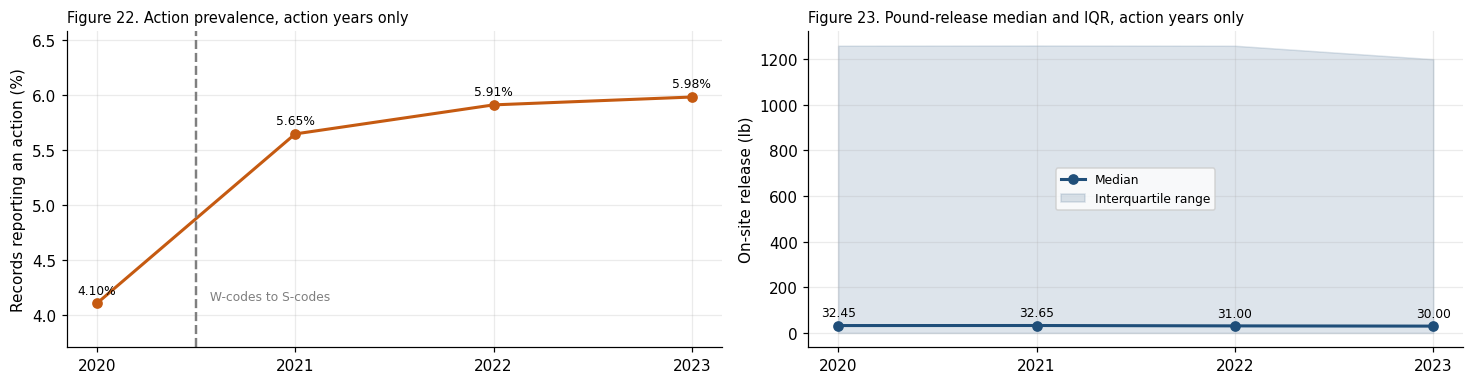

**Table 31. Release distribution by action year, units kept separate (2024 withheld)**

Year,Unit,Records,Median,IQR low,IQR high,95th pct
2020,Pounds,"55,898",32.45,0.10,"1,259.11","38,283.85"
2020,Grams,564,0.37,0.10,1.31,8.75
2021,Pounds,"55,666",32.65,0.10,"1,260.00","38,940.75"
2021,Grams,553,0.38,0.12,1.24,9.94
2022,Pounds,"55,599",31.00,0.09,"1,259.00","39,659.60"
2022,Grams,556,0.38,0.12,1.23,13.03
2023,Pounds,"54,812",30.00,0.09,"1,200.00","37,748.47"
2023,Grams,537,0.36,0.12,1.22,10.64


In [31]:
# INTENT
# What: Annual action prevalence with the coding change marked, and annual release distribution by unit.
# Why : Both describe the reporting environment across all five years without touching reserved outcomes.

# ---- Action years only ---------------------------------------------------------------
# 2024 is deliberately excluded from every release summary below. It is the reserved outcome
# year: publishing its median and interquartile release would disclose, in aggregate form,
# exactly the quantity the temporal split exists to withhold. A reader could compare the 2023
# and 2024 medians and infer the direction of the reserved outcome without the split ever
# being formally broken.
summary_years = [y for y in reporting_years if y != int(reserved_span.split("_")[1])]

# Annual trend across all five years, with the coding change marked.
prevalence_by_year = [100*consolidated_by_year[year]["reported_any_action"].mean() for year in summary_years]

figure, axes = plt.subplots(1, 2, figsize=(13.5, 3.6))
axes[0].plot(summary_years, prevalence_by_year, "-o", color=RUST, lw=2)
label_points(axes[0], summary_years, prevalence_by_year, suffix="%", dy=0.09)
axes[0].axvline(2020.5, color=SLATE, ls="--", lw=1.6)  # the W-code to S-code boundary
axes[0].text(2020.55, min(prevalence_by_year), " W-codes to S-codes", fontsize=8, color=SLATE, va="bottom")
axes[0].set_xticks(summary_years); axes[0].set_ylabel("Records reporting an action (%)")
axes[0].set_ylim(min(prevalence_by_year)-0.4, max(prevalence_by_year)+0.6)
axes[0].set_title("Figure 22. Action prevalence, action years only", loc="left", fontsize=9.5)

# Median and IQR rather than total mass: a few very large records dominate any total.
# Release distributions per year, units kept apart. Medians and quartiles rather than means,
# because the pound distribution is skewed enough that a mean tracks a handful of large plants.
annual_rows = []
for year in summary_years:
    frame = consolidated_by_year[year]
    for unit_label in ["Pounds", "Grams"]:
        subset = frame[frame["unit_of_measure"].str.upper() == unit_label.upper()]
        if not len(subset):  # a year may have no gram records at all
            continue
        annual_rows.append({"Year": year, "Unit": unit_label, "Records": len(subset),
                            "Median": float(subset["release"].median()),
                            "IQR low": float(subset["release"].quantile(.25)),
                            "IQR high": float(subset["release"].quantile(.75)),
                            "95th pct": float(subset["release"].quantile(.95))})
annual = pd.DataFrame(annual_rows)

# Only pounds are plotted. Grams are three orders of magnitude smaller, so on a shared axis the
# gram series would be a flat line at zero and would tell the reader nothing.
pound_rows = annual[annual["Unit"] == "Pounds"]
axes[1].plot(pound_rows["Year"], pound_rows["Median"], "-o", color=NAVY, lw=2, label="Median")
axes[1].fill_between(pound_rows["Year"], pound_rows["IQR low"], pound_rows["IQR high"],  # shaded IQR shows spread, not just the central value
                     color=NAVY, alpha=0.15, label="Interquartile range")
label_points(axes[1], pound_rows["Year"], pound_rows["Median"], dy=40)
axes[1].set_xticks(summary_years); axes[1].set_ylabel("On-site release (lb)")
axes[1].legend(fontsize=8)
axes[1].set_title("Figure 23. Pound-release median and IQR, action years only", loc="left", fontsize=9.5)
plt.tight_layout(); plt.show()

show_table(annual, "Table 31. Release distribution by action year, units kept separate (2024 withheld)",
           number_format={"Records": "{:,}", "Median": "{:,.2f}", "IQR low": "{:,.2f}",
                          "IQR high": "{:,.2f}", "95th pct": "{:,.2f}"})

**Interpretation.** Figure 22 marks the **W-code to S-code change between 2020 and 2021** explicitly, so
the step from 4.10% to 5.65% is read as a measurement discontinuity rather than a behavioural shift.
Prevalence then plateaus between 5.62% and 5.98%, which is the more meaningful comparison because those
four years share a coding scheme.

Figure 23 uses the **median and interquartile range rather than total mass**, because the top 1% of records
hold 63% of the mass and a total would simply track a handful of very large emitters. On that basis the
central tendency of pound releases is broadly flat across the five years. Grams are tabulated separately
and never combined with pounds.

Note that 2024 activity codes appear here as descriptive information about the reporting environment only.
They are not part of any 2023-to-2024 outcome relationship, which remains unexamined.

In [32]:
# INTENT
# What: Repeat the development-only action comparison excluding the pandemic-affected 2020-2021 transition.
# Why : If the association depends on that atypical period, the pooled estimate would be fragile.

# Pandemic sensitivity: repeat the contrast without the disrupted transition.
# 2020-2021 spans a production shock, so releases fell for reasons unrelated to prevention.
# Dropping it is a prespecified sensitivity check, not a result chosen after the fact.
without_pandemic = development[development["span"] != "2020_2021"]
exposed = without_pandemic[without_pandemic["reported_any_action_now"] == 1]
unexposed = without_pandemic[without_pandemic["reported_any_action_now"] == 0]
sensitivity = compare_two_proportions(int(exposed["reduced"].sum()), len(exposed),
                                      int(unexposed["reduced"].sum()), len(unexposed))

show_table(pd.DataFrame([
    {"Specification": "All development spans", "Action n": total_action,
     "Difference (pp)": 100*comparison["difference"], "CI low": 100*comparison["ci_low"],
     "CI high": 100*comparison["ci_high"], "Relative risk": comparison["relative_risk"],
     "p-value": comparison["p_value"]},
    {"Specification": "Excluding 2020-2021", "Action n": len(exposed),
     "Difference (pp)": 100*sensitivity["difference"], "CI low": 100*sensitivity["ci_low"],
     "CI high": 100*sensitivity["ci_high"], "Relative risk": sensitivity["relative_risk"],
     "p-value": sensitivity["p_value"]},
]), "Table 32. Pandemic-period sensitivity check",
   number_format={"Action n": "{:,}", "Difference (pp)": "{:+.2f}", "CI low": "{:+.2f}",
                  "CI high": "{:+.2f}", "Relative risk": "{:.3f}", "p-value": "{:.3e}"})

**Table 32. Pandemic-period sensitivity check**

Specification,Action n,Difference (pp),CI low,CI high,Relative risk,p-value
All development spans,"6,012",+3.61,+2.37,+4.84,1.115,4.221e-09
Excluding 2020-2021,"4,357",+3.11,+1.64,+4.57,1.093,2.367e-05


**Interpretation.** Excluding the pandemic-affected transition, the unadjusted difference falls from
**+3.61 to +3.09 percentage points** and the relative risk from **1.115 to 1.093**. The direction is
unchanged, the association remains significant (p < .001), and the confidence intervals overlap
substantially.

The association is therefore **not an artefact of the 2020-2021 period**, though that period does inflate
it modestly. This is the appropriate temporal robustness check for annual data, and it is reported in place
of any seasonal analysis, which the data structure cannot support.

---
# 16. Data-Quality Scorecard

**Table 33. Data-quality scorecard**

Dimension,Check,Finding,Status
Completeness,Release and outcome fields,"Zero missing, negative or non-finite",Pass
Completeness,Production ratio,1.62% missing; flat across covariates and outcome,Pass
Validity,"Field widths, all ten files",Trailing delimiter in 1A; 4 malformed rows itemised,Controlled
Validity,Malformed rows,"Excluded by line number, not silently skipped",Controlled
Validity,Extreme production ratio,"Maximum above 3 million; flagged influential, winsorised",Controlled
Validity,Units,Pounds and grams analysed separately throughout,Controlled
Consistency,1A to 2A join,Validated one-to-one; zero identity disagreements,Pass
Consistency,Activity code scheme,W to S change reconciled; zero unmapped codes asserted,Pass
Uniqueness,Duplicate forms,Summed or superseded by revision; conflicts flagged and zero,Pass
Representativeness,Cross-year attrition,7.6-9.5%; profiled all four spans; direction unresolved,Limitation


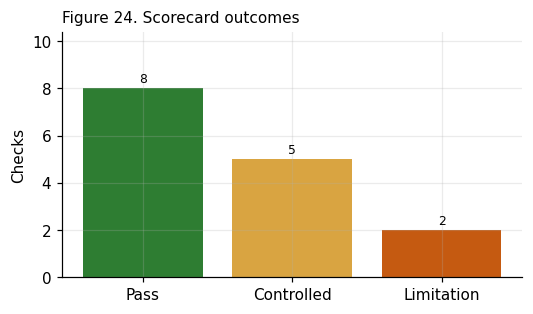

In [33]:
# INTENT
# What: Collect every quality dimension examined into one reviewable table.
# Why : Gives a reviewer a single view of fitness for purpose and becomes the evidence base for the
#       interim report's data-cleaning section.

# Pass = clean; Controlled = a real defect that was found and remediated;
# Limitation = a property of the data that no analytical choice can remove.
# One row per dimension of data quality, each with the concrete evidence behind its verdict.
# 'Pass' with no number attached would be an assertion rather than a finding.
scorecard = pd.DataFrame([
    ["Completeness", "Release and outcome fields", "Zero missing, negative or non-finite", "Pass"],
    ["Completeness", "Production ratio", "1.62% missing; flat across covariates and outcome", "Pass"],  # flat missingness is what makes imputation defensible
    ["Validity", "Field widths, all ten files", "Trailing delimiter in 1A; 4 malformed rows itemised", "Controlled"],
    ["Validity", "Malformed rows", "Excluded by line number, not silently skipped", "Controlled"],
    ["Validity", "Extreme production ratio", "Maximum above 3 million; flagged influential, winsorised", "Controlled"],
    ["Validity", "Units", "Pounds and grams analysed separately throughout", "Controlled"],
    ["Consistency", "1A to 2A join", "Validated one-to-one; zero identity disagreements", "Pass"],  # checked on all six shared fields, not just row counts
    ["Consistency", "Activity code scheme", "W to S change reconciled; zero unmapped codes asserted", "Pass"],
    ["Uniqueness", "Duplicate forms", "Summed or superseded by revision; conflicts flagged and zero", "Pass"],
    ["Representativeness", "Cross-year attrition", "7.6-9.5%; profiled all four spans; direction unresolved", "Limitation"],
    ["Representativeness", "Chemical coverage", "TRI covers neither all chemicals nor all facilities", "Limitation"],
    ["Independence", "Facility clustering", "8.3 records per facility; clustered errors required", "Controlled"],
    ["Statistical", "Collinearity", "Full 23-predictor matrix; max VIF 2.06; full rank", "Pass"],
    ["Statistical", "Sparse cells", "Smallest expected cell 113; Fisher not required", "Pass"],
    ["Integrity", "Reserved test data", "Structure verified only; no outcome inspected", "Pass"],
], columns=["Dimension", "Check", "Finding", "Status"])

def status_colour(value):
    return {"Pass": "background-color:#e2efda", "Controlled": "background-color:#fff2cc",
            "Limitation": "background-color:#fbe4d5"}.get(value, "")

display(Markdown("**Table 33. Data-quality scorecard**"))
try:
    display(scorecard.style.hide(axis="index").map(status_colour, subset=["Status"])
            .set_table_styles(header_style))
except (ImportError, AttributeError):
    display(scorecard)

counts = scorecard["Status"].value_counts()
figure, axis = plt.subplots(figsize=(5.4, 2.9))
bars = axis.bar(counts.index, counts.values, color=[MOSS, "#d9a441", RUST][:len(counts)])
label_bars(axis, bars, list(counts.values), offset=0.12)
axis.set_ylabel("Checks"); axis.set_ylim(0, counts.max()*1.3)
axis.set_title("Figure 24. Scorecard outcomes", loc="left", fontsize=10)
plt.show()

**Interpretation.** Fifteen checks resolve into three states. **Eight pass outright**, including join
integrity, code-scheme reconciliation, duplicate handling, collinearity, sparse-cell adequacy and reserved-
data protection. **Five are controlled** - real defects that were found and remediated: the trailing
delimiter, the four malformed rows, the extreme production ratio, and the unit separation. **Two remain
limitations** that no analytical choice can remove: cross-year attrition and the coverage of the TRI
programme itself.

The distinction is deliberate. A controlled issue has a documented technical remedy in this notebook. A
limitation is a property of the data-generating process - nothing can recover a facility that stopped
filing - and must instead be disclosed, with its consequences for inference stated and, where the direction
of bias cannot be established, said to be unresolved rather than assumed favourable.

---
# 17. Analysis and Reflection

## 17.1 What the data supports

The pipeline is auditable end to end. Field widths are verified for all ten files, four malformed rows are
itemised and excluded by line number, the File 1A to File 2A join is validated one-to-one with zero
identity disagreements, and every one of the seventy observed activity codes maps to a category under an
assertion that fails loudly otherwise. Consolidation now distinguishes additional original forms, whose
releases are summed, from revisions, which supersede.

On the development data, **five** relationships are established. RQ1 and RQ3 are answered on all
123,535 eligible same-unit records; the release-based RQ2 and RQ4 machinery uses the 122,017 pound records,
with the 1,518 gram records reported as a named sensitivity analysis. Reduction rates rise across the
development period (27.54%, 31.09%, 35.86%; chi-square(2) = 663.72, V = 0.073) and vary across subsectors
(chi-square(14) = 280.04, V = 0.048), both statistically certain but small in effect. Records reporting an
action reduce at **34.91% against 31.31%**, a difference of **+3.61 points, 95% CI [+2.37, +4.84]**,
relative risk 1.115. Among categories, **material modification (+7.64 points, RR 1.244 [1.139, 1.359])** and
**operating practice and training (+4.23 points, RR 1.135 [1.070, 1.205])** separate from the reference after
Holm adjustment. The other three do not, but the intervals distinguish two different failures: process and
equipment modification is **inconclusive**, its RR interval reaching 0.999 on 2,230 records, whereas product
modification is simply **uninformative** on 361.

The fifth is new to this revision and changes a specification rather than a headline. The production ratio
is **not** monotonically related to the outcome, as an earlier draft claimed. Its relationship is
**U-shaped and centred on unchanged production**: reduction rates fall to a minimum of **29.72% at a
production ratio of exactly 1.00** and rise on both sides, to 31.59% at the bottom decile and 36.19% at the
top. A comparison of the ratio *in isolation* prefers a quadratic form (AIC 149,557.8) over linear (149,560.9)
and decisively over logarithmic (149,633.5), so the ratio enters the design matrix as a centred quadratic -
**provisionally**. Functional form depends on what else is adjusted for, the margin over linear is only
3 AIC units, and the three forms plus a spline will be re-compared inside the full development model before
the specification is locked.

Two structural facts constrain everything above. Records are **clustered within facilities** - 122,017
records from 14,836 plants, 92.8% contributing more than one, maximum 210 - so the effective sample size for
any facility-level predictor is far closer to 14,836 than to the nominal record count. And action-category prevalence shows a
**discontinuity precisely at the 2020-to-2021 coding-scheme boundary** (material modification 0.41% to
0.87%, process and equipment 1.32% to 2.13%, with the other three flat), which may partly reflect the
coding change and should not be interpreted as purely behavioural.

## 17.2 Theoretical grounding

The ordering of the action categories is consistent with the pollution-prevention hierarchy codified in the
Pollution Prevention Act of 1990, under which source elimination is preferred to procedural control, and
with King and Lenox (2002), who found returns concentrate in particular intervention types. The disclosure
literature (Hamilton, 1995; Konar & Cohen, 1997) explains why facilities report at all, and Ranson et al.
(2015) provide the closest precedent for linking reported prevention activity to subsequent releases in TRI
data. The U-shaped production-ratio relationship has a coherent mechanism in the eco-efficiency literature: a
falling limb where contracting plants emit less simply because they make less, and a rising limb where
expanding plants that still cut releases are achieving genuine intensity improvement. The minimum at
unchanged output is where neither driver operates. This is why the ratio is a confounder to be adjusted
for rather than a competing explanation - it separates real prevention from arithmetic scaling.

Methodologically, the treatment of uncertainty follows Steyerberg et al. (2010) and Van Calster et al.
(2019); functional form is selected by AIC (Akaike, 1974; Burnham & Anderson, 2002) rather than by
inspection; polynomial terms are centred to avoid artificial collinearity (Aiken & West, 1991); clustered
variance estimation follows Cameron and Miller (2015); and the sample-size reasoning follows Peduzzi et al.
(1996) and Riley et al. (2019).

## 17.3 Reasoning about uncertainty

Every proportion carries a Wilson interval and every group comparison an effect size. At this sample size
that pairing is essential: the year effect reaches p < .001 with Cramer's V of only 0.073, so significance
and importance diverge sharply.

Uncertainty is also understated by the nominal record count. The 122,017 pound records in the modelling frame come
from **14,836 facilities**, a mean of 8.22 records each, with **92.8% of facilities contributing more than
one** and a maximum of 210 (Figure 6a).
Records from one plant share management, process technology and regulatory posture, so they are not
independent draws and the effective sample size is materially smaller than the nominal one. This is the
justification for facility-clustered standard errors in RQ2 and for year-grouped cross-validation folds in
RQ4. An earlier version of this notebook quoted a variance share between facilities as evidence; that
statistic was not a valid intraclass correlation for a binary outcome and has been removed. The record-count
distribution is sufficient justification on its own.

## 17.4 Methodological choices

| Choice | Alternative rejected | Justification |
|---|---|---|
| Positional parsing with per-year header checks | Header-name parsing | Explicit and stable across years; the trailing delimiter is controlled rather than assumed harmless |
| Malformed rows excluded by line number | `on_bad_lines="skip"` | Silent skipping hides real data loss; all four rows are itemised |
| Enumerated code crosswalk with assertion | Leading-digit heuristic | The scheme changed in 2021; an assumption would zero out four years of exposure |
| Sum additional forms, revision supersedes | Highest document number | Only 13-39 groups per year are revisions; the rest are separate process units whose releases add |
| Units analysed separately | Pooled release statistics | Median 217 lb against 0.43 g; pooling produces a meaningless distribution |
| Median imputation plus indicator | Complete-case deletion | Missingness is 1.62% and flat; deletion discards valid records |
| Winsorise the extreme ratio | Delete implausible values | No field confirms an error; capping limits leverage while retaining the record |
| Temporal split | Random split | A random split leaks same-year information and overstates performance |
| Holm correction | Bonferroni | Same family-wise error control with more power |
| Facility-clustered errors | Ordinary standard errors | 92.8% of facilities contribute multiple records; mean 8.22, maximum 210 (Figure 6a) |
| Frame chosen per research question | One frame for everything | RQ1/RQ3 are rate questions and unit-free, so all 123,535 records are used; only the release-based RQ2/RQ4 need the pound restriction |
| Quadratic production ratio, centred, provisional | Single linear term treated as settled | Figure 12b turns at ratio 1.00 and AIC prefers the quadratic, but only on the ratio alone; form is re-tested inside the adjusted model |
| All 15 qualifying subsectors, largest as reference | Ten largest only | The 500-record rule defines eligibility; taking a further top-ten cut dropped five qualifying groups while the parameter file claimed otherwise |

The principal assumptions are that facility and chemical identifiers are stable across years, so matching
links genuinely equivalent records; and that a reported code reflects a real activity.

## 17.5 Limitations

1. **Attrition of unknown direction.** Between 7.6% and 9.5% of records have no next-year counterpart.
   Unmatched records are smaller emitters and slightly more likely to have reported an action. Disappearance
   may reflect reporting thresholds, closures, ownership change, substitution or identifier changes, so
   **the direction of any resulting bias cannot be established from the observed data**.
2. **Exposure measured with error.** A zero means no valid code was reported, not that no action occurred.
   Whether this attenuates or distorts the association depends on the error being unrelated to the outcome,
   which has not been demonstrated.
3. **Coding discontinuity.** The 2020-to-2021 change is reconciled by an explicit crosswalk, but the
   prevalence step across that boundary is partly an artefact and should not be read as behavioural change.
4. **No causal identification.** These are observational associations; confounding by indication is
   plausible and the covariate-balance table shows measured imbalance of up to 0.244 SMD (NAICS 327).
5. **Dichotomisation.** The 10% cutoff discards information and treats -9.8% and -10.2% as categorically
   different. Sensitivity at 5% and 20% is planned.
6. **Missingness mechanism unverifiable.** Production-ratio missingness is small and flat across observed
   groups, but the mechanism cannot be confirmed from observed data.
7. **Coverage.** TRI covers neither all chemicals nor all facilities, limiting external validity.

## 17.6 Next steps

1. Fit the **RQ2 adjusted logistic model** with facility-clustered standard errors and both hazard controls,
   and report the adjusted odds ratio with its interval. No adjusted estimate is quoted until then.
2. Re-check separation and influence on the fitted model, including subsector indicators.
3. **Settle the production-ratio functional form inside the adjusted model.** The quadratic was selected on
   the ratio alone, is preferred by only ~3 AIC units over linear, and imposes a symmetry that Figure 12b does
   not show. Compare linear, quadratic and a restricted cubic spline by development-only cross-validation
   with release, year, subsector, hazard and action status all present, then lock the form.
4. Compare complete-case against imputed specifications, learning all imputation values inside development
   data only.
5. Tune the **elastic-net penalty by year-grouped cross-validation** within development, then lock the model.
6. Evaluate **once** on the reserved 2023-2024 span, reporting ROC-AUC, Brier score, precision, recall, F1
   and a calibration plot.
7. Run the pre-specified sensitivity analyses: excluding 2020-2021, excluding gram-reported records, and at
   5% and 20% reduction cutoffs.

---

## References

Akaike, H. (1974). A new look at the statistical model identification. *IEEE Transactions on Automatic
Control, 19*(6), 716-723.

Aiken, L. S., & West, S. G. (1991). *Multiple regression: Testing and interpreting interactions*.
Sage.

Barnett, A. G., van der Pols, J. C., & Dobson, A. J. (2005). Regression to the mean: What it is and how to
deal with it. *International Journal of Epidemiology, 34*(1), 215-220.

Brown, L. D., Cai, T. T., & DasGupta, A. (2001). Interval estimation for a binomial proportion.
*Statistical Science, 16*(2), 101-133.

Burnham, K. P., & Anderson, D. R. (2002). *Model selection and multimodel inference: A practical
information-theoretic approach* (2nd ed.). Springer.

Cameron, A. C., & Miller, D. L. (2015). A practitioner's guide to cluster-robust inference.
*Journal of Human Resources, 50*(2), 317-372.

Cohen, J. (1988). *Statistical power analysis for the behavioral sciences* (2nd ed.). Lawrence Erlbaum.

Cohen, J. (1994). The earth is round (p < .05). *American Psychologist, 49*(12), 997-1003.

Hamilton, J. T. (1995). Pollution as news: Media and stock market reactions to the Toxics Release Inventory
data. *Journal of Environmental Economics and Management, 28*(1), 98-113.

Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The elements of statistical learning* (2nd ed.).
Springer.

King, A. A., & Lenox, M. J. (2002). Exploring the locus of profitable pollution reduction.
*Management Science, 48*(2), 289-299.

Konar, S., & Cohen, M. A. (1997). Information as regulation: The effect of community right-to-know laws on
toxic emissions. *Journal of Environmental Economics and Management, 32*(1), 109-124.

Peduzzi, P., Concato, J., Kemper, E., Holford, T. R., & Feinstein, A. R. (1996). A simulation study of the
number of events per variable in logistic regression analysis. *Journal of Clinical Epidemiology, 49*(12),
1373-1379.

Ranson, M., Cox, B., Keenan, C., & Teitelbaum, D. (2015). The impact of pollution prevention on toxic
environmental releases from U.S. manufacturing facilities. *Environmental Science & Technology, 49*(21),
12951-12957.

Riley, R. D., Snell, K. I. E., Ensor, J., Burke, D. L., Harrell, F. E., Jr., Moons, K. G. M., & Collins,
G. S. (2019). Minimum sample size for developing a multivariable prediction model: Part II - Binary and
time-to-event outcomes. *Statistics in Medicine, 38*(7), 1276-1296.

Rosenbaum, P. R. (2002). *Observational studies* (2nd ed.). Springer.

Rothman, K. J., Greenland, S., & Lash, T. L. (2008). *Modern epidemiology* (3rd ed.). Lippincott
Williams & Wilkins.

Rubin, D. B. (1976). Inference and missing data. *Biometrika, 63*(3), 581-592.

Simmons, J. P., Nelson, L. D., & Simonsohn, U. (2011). False-positive psychology. *Psychological Science,
22*(11), 1359-1366.

Steyerberg, E. W., Vickers, A. J., Cook, N. R., Gerds, T., Gonen, M., Obuchowski, N., Pencina, M. J., &
Kattan, M. W. (2010). Assessing the performance of prediction models. *Epidemiology, 21*(1), 128-138.

U.S. Environmental Protection Agency. (2024). *Toxics Release Inventory Basic Plus data files
documentation: File type 1A and file type 2A* (Updated for RY2023).

Van Calster, B., McLernon, D. J., van Smeden, M., Wynants, L., & Steyerberg, E. W. (2019). Calibration:
The Achilles heel of predictive analytics. *BMC Medicine, 17*, Article 230.

---
# 18. Export

In [34]:
# INTENT
# What: Export the development and reserved datasets under one controlled schema, with the supporting
#       audit tables, a data dictionary, hashes and preprocessing parameters.
# Why : Modelling must consume exactly the records characterised here, and the reserved file must be
#       provably identical in structure without its outcome having been examined.

import os, json
# Exports sit beside the raw data so the modelling notebook can load them directly.
export_folder = f"{data_folder}/processed"
os.makedirs(export_folder, exist_ok=True)

# Two schemas, not one. FEATURE_COLUMNS is everything a model may see at prediction time; it is the
# only schema the reserved file is written under. OUTCOME_COLUMNS is what may only ever be known for
# development records. Exporting both frames under a single combined schema - as an earlier version of
# this notebook did - forces the reserved file to carry outcome columns, which is precisely the leak
# the temporal split exists to prevent.
# The four role lists and feature_columns were declared in Section 1, before any data was read,
# and Section 10 has already validated the reserved span against them. Re-deriving them here would
# let the two definitions drift; using them keeps one source of truth.
development_export = development[feature_columns + outcome_columns].copy()  # development carries the outcome
reserved_export = reserved[feature_columns].copy()

# Structural guarantees, asserted rather than described.
# Fail loudly rather than export mismatched files
# Four assertions rather than four printed checks. A printed check can be read past; an assert
# stops the notebook, so these conditions cannot silently stop holding.
assert list(reserved_export.columns) == feature_columns, "Reserved schema drift"
assert list(development_export.columns) == feature_columns + outcome_columns, "Development schema drift"
assert not [c for c in outcome_columns if c in reserved_export.columns], \
    "Reserved export carries an outcome column"
assert development_export.columns.is_unique and reserved_export.columns.is_unique, "Duplicate columns"
print(f"Schema assertions passed: {len(feature_columns)} non-outcome columns "
      f"({len(identifier_columns)} identifier, {len(predictor_columns)} predictor, "
      f"{len(audit_columns)} audit), {len(outcome_columns)} outcome columns, "
      f"0 outcome columns in the reserved file.")
# Identifiers and predictors must not overlap - the whole point of the split.
assert not set(identifier_columns) & set(predictor_columns), "A column is both identifier and predictor"

# Content hash recorded before modelling begins: evidence the reserved data
# was not altered or inspected in the interim.
# A hash recorded before modelling begins is evidence that the reserved data was not altered
# or inspected in between. Naming a file 'reserved' is only a convention.
def file_hash(frame):
    """Full 64-character SHA-256. A truncated hash is a weaker guarantee for no practical benefit."""
    return hashlib.sha256(pd.util.hash_pandas_object(frame, index=False).values.tobytes()).hexdigest()

development_export.to_csv(f"{export_folder}/development.csv", index=False)
reserved_export.to_csv(f"{export_folder}/reserved_2023_2024_features_only.csv", index=False)
pd.DataFrame(width_audit).to_csv(f"{export_folder}/audit_field_widths.csv", index=False)
pd.DataFrame(malformed_rows).to_csv(f"{export_folder}/audit_malformed_rows.csv", index=False)
pd.DataFrame(join_audit).to_csv(f"{export_folder}/audit_join.csv", index=False)
pd.DataFrame(consolidation_audit).to_csv(f"{export_folder}/audit_consolidation.csv", index=False)
crosswalk_table.to_csv(f"{export_folder}/activity_code_crosswalk.csv", index=False)
pd.DataFrame(attrition_audit).to_csv(f"{export_folder}/audit_attrition.csv", index=False)
scorecard.to_csv(f"{export_folder}/quality_scorecard.csv", index=False)
data_dictionary.to_csv(f"{export_folder}/data_dictionary.csv", index=False)

# Every constant the modelling notebook must reuse rather than recompute.
# Every constant the modelling notebook must reuse - the cutoff, the imputation median, the
# winsorisation point, the selected subsectors. Recomputing these on combined data would leak
# reserved information into the fitted model.
preprocessing = {
    "reduction_cutoff": reduction_cutoff,
    "development_spans": development_spans,
    "reserved_span": reserved_span,
    "frames": {"rq1_rq3": "all eligible same-unit development records",
               "rq2_rq4": "pound records only (release-based models)",
               "sensitivity": "gram records, reported separately"},
    "production_ratio_form": "quadratic, PROVISIONAL - selected by AIC on the ratio alone (Table 22b); to be re-compared against linear and spline forms inside the adjusted model",
    "production_ratio_median_modelling": float(ratio_values.median()),
    "production_ratio_winsor_99th": float(modelling["ratio_filled"].quantile(.99)),
    "subsector_selection_rule": "all subsectors with >= 500 records; outcome not used in selection",
    "subsectors_qualifying": subsectors_by_size,
    "subsector_reference_category": subsector_reference,
    "subsectors_in_design_matrix": subsector_terms,
    "malformed_rows_excluded": len(malformed_rows),
    "column_roles": {
        "identifier": identifier_columns,   # traceability; never enter a model
        "predictor": predictor_columns,     # the only columns the design matrix may draw on
        "audit": audit_columns,             # provenance and quality flags
        "outcome": outcome_columns,         # development only
    },
    "feature_columns": feature_columns,
    "outcome_columns": outcome_columns,
    "hashes": {"development": file_hash(development_export),
               "reserved_features_only": file_hash(reserved_export)},
}
with open(f"{export_folder}/preprocessing_parameters.json", "w") as handle:
    json.dump(preprocessing, handle, indent=2)

export_summary = pd.DataFrame([
    {"Dataset": "Development", "Records": len(development_export),
     "Feature columns": len(feature_columns), "Outcome columns": len(outcome_columns),
     "SHA-256": preprocessing["hashes"]["development"]},
    {"Dataset": "Reserved 2023-2024 (features only)", "Records": len(reserved_export),
     "Feature columns": len(feature_columns), "Outcome columns": 0,
     "SHA-256": preprocessing["hashes"]["reserved_features_only"]},
])
show_table(export_summary, "Table 34. Exported datasets", number_format={"Records": "{:,}"})
print("Written to:", export_folder)

Schema assertions passed: 23 non-outcome columns (4 identifier, 15 predictor, 4 audit), 3 outcome columns, 0 outcome columns in the reserved file.


**Table 34. Exported datasets**

Dataset,Records,Feature columns,Outcome columns,SHA-256
Development,"123,535",23,3,672c17dbe0a7f37a24d0e7401621420a97f0bff6f1b58ebb37754dffc2a1b00d
Reserved 2023-2024 (features only),"39,966",23,0,69ab6bd791e649c8a0a3502c8fa141470c03c1d2d93470dfd0ae67b77d7c1201


Written to: /content/drive/MyDrive/Walsh_DBA/Year2/Projects/Capstone_QM640_TRI_2020_2024/Data/processed


**Interpretation.** Columns are exported under **four declared roles**, not one undifferentiated
block: **4 identifier, 15 predictor, 4 audit and 3 outcome**. The development file carries all 23
non-outcome columns plus the 3 outcome columns; the reserved file carries the same 23 and **0 outcome
columns**, and assertions confirm both facts before anything is saved.

The identifier/predictor boundary is the one that matters for the modelling stage. Facility ID, chemical
ID, CAS number and chemical name answer *which record is this*, not *why did the release fall*. Handed to a
fitting routine they would let a model memorise individual facilities - scoring well on development data
and failing on the reserved span, where most facility identifiers are the same but the year is not. The
split makes that impossible to do by accident: a modelling script that consumes `predictor_columns` cannot
reach an identifier, and one that reads the whole frame is visibly ignoring a declared role. Alongside these go
the field-width audit, the malformed-row register, the join and consolidation audits, the full activity-code
crosswalk, the attrition table, the quality scorecard, the data dictionary, and a parameter file recording
the reduction cutoff, the imputation median, the winsorisation point and a content hash for each dataset.

The hashes matter more than the file names. Naming a file "reserved" is a convention; a hash recorded before
modelling begins is **evidence** that the reserved data was not altered or inspected in between. Every
imputation constant is stored so that the modelling notebook applies development-derived values rather than
recomputing them on combined data.

**This completes the exploratory data analysis.** The data has been audited for structure, completeness,
validity, consistency, uniqueness, independence and statistical adequacy; the training and reserved design
has been verified with the reserved outcome untouched; and the confounding structure, distributional
assumptions and sparsity checks needed by the adjusted model are documented above.